(chap3)=

# 第 4 章 扩展线性模型

销售宣传里有一句常见套话: "先别急,还有更多!" 前面已经向观众展示了一件仿佛无所不能的产品,
但销售人员总能再演示一种用途,让这件本已十分灵活的工具显得更万能。我们也想对你这样介绍线性
回归。在[第 3 章](chap2)中,我们已经展示了使用和扩展线性回归的多种方式,但线性模型仍然大有
潜力。从协变量变换、变化的方差到多层模型(multilevel model),每一种思想都能增加灵活性,让线性
回归适用于更广泛的情形。

> **中文版现代化说明**:本章代码以 `notebooks_updated/chp_04.ipynb` 为现代化起点,统一使用当前
> 公开的 PyMC 5、PyTensor、ArviZ、TensorFlow 与 TensorFlow Probability (TFP) API。旧代码中的
> `az.from_pymc3`、Theano 注释、全局 `np.random.seed` 和上级目录数据路径均已替换。所有 Python
> 单元都能由标准解释器静态编译,数据和图路径均相对于本章目录。本地 Python 缺少 `Python.h` 时,
> 设置单元会自动选择 PyTensor 的纯 Python linker;头文件存在时仍保留较快的 C 后端。
> `CH4_PROFILE=smoke|release` 只改变抽样预算,不跳过任何模型、诊断或绘图单元;默认 `smoke` 使用
> 确定性种子和较少抽样,发布运行应显式选择 `release`。本次交付只提供规范源,不执行完整 MCMC,
> 也不生成最终 Notebook/Org。

In [1]:
import os
import shutil
import sysconfig
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytensor

# 本地 Python 缺少开发头文件时,使用 PyTensor 的纯 Python linker;有 Python.h 时保留 C 后端。
PYTHON_HEADER = Path(sysconfig.get_path("include")) / "Python.h"
if not PYTHON_HEADER.is_file():
    pytensor.config.cxx = ""

import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from scipy import stats

SEED = 20210404
PROFILE_NAME = os.getenv("CH4_PROFILE", "smoke").strip().lower()
PROFILES = {
    "smoke": {
        "draws": 20,
        "tune": 20,
        "long_draws": 24,
        "long_tune": 30,
        "chains": 1,
        "cores": 1,
        "tfp_draws": 20,
        "tfp_adapt": 20,
        "tfp_chains": 1,
    },
    "release": {
        "draws": 1000,
        "tune": 1000,
        "long_draws": 2000,
        "long_tune": 4000,
        "chains": 4,
        "cores": min(4, os.cpu_count() or 1),
        "tfp_draws": 1000,
        "tfp_adapt": 1000,
        "tfp_chains": 4,
    },
}
if PROFILE_NAME not in PROFILES:
    raise ValueError("CH4_PROFILE 必须是 'smoke' 或 'release'")
PROFILE = PROFILES[PROFILE_NAME]

DATA_DIR = Path("data")
CANONICAL_FIGURE_DIR = Path("figures")
# Smoke runs must never overwrite release-quality chapter assets.
FIGURE_DIR = CANONICAL_FIGURE_DIR if PROFILE_NAME == "release" else CANONICAL_FIGURE_DIR / "smoke"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_model_graph(graph, stem):
    """Always retain DOT and ensure a PNG through rendering or a checked static fallback."""
    dot_path = FIGURE_DIR / f"{stem}.dot"
    png_path = FIGURE_DIR / f"{stem}.png"
    dot_path.write_text(graph.source, encoding="utf-8")
    if shutil.which("dot"):
        graph.render(filename=str(FIGURE_DIR / stem), format="png", cleanup=True)
    else:
        fallback = CANONICAL_FIGURE_DIR / f"{stem}.png"
        if not fallback.is_file():
            raise RuntimeError(f"Graphviz dot 不可用,且缺少静态回退图: {fallback}")
        if png_path != fallback:
            shutil.copy2(fallback, png_path)
    return dot_path, png_path


az.style.use("arviz-grayscale")
plt.rcParams["figure.dpi"] = 160 if PROFILE_NAME == "smoke" else 300

# 固定顺序的无障碍分类色板;同一实体在全章始终使用同一颜色,并辅以线型/点型/图例。
SERIES_COLORS = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)


def sample_kwargs(*, seed_offset=0, long=False, target_accept=0.9):
    return {
        "draws": PROFILE["long_draws" if long else "draws"],
        "tune": PROFILE["long_tune" if long else "tune"],
        "chains": PROFILE["chains"],
        "cores": PROFILE["cores"],
        "random_seed": SEED + seed_offset,
        "target_accept": target_accept,
        "progressbar": False,
        "compute_convergence_checks": True,
        "idata_kwargs": {"log_likelihood": True},
    }

(transforming_covariates)=

## 变换协变量

在[第 3 章](chap2)中我们看到,对于采用恒等链接函数(identity link function)的线性模型,无论
$X_i$ 处于什么取值,$x_i$ 每改变 1 个单位,响应变量 $Y$ 的期望都会改变 $\beta_i$。随后我们又看到,
改变似然函数(例如从高斯分布改为伯努利分布)可以得到**广义线性模型(generalized linear model,
GLM)**,而这通常也要求改变链接函数。

对朴素线性模型的另一项有用修改,是变换协变量(covariate transformation) $\mathbf{X}$,从而让
$\mathbf{X}$ 与 $Y$ 的关系变成非线性。例如,我们可以假设 $x_i$ 的平方根每改变 1 个单位、对数每
改变 1 个单位等,响应变量 $Y$ 的期望就改变 $\beta_i$。在数学上,可以在式
[eq:expanded_regression](eq:expanded_regression)上增加 $f(\cdot)$;它表示分别施加到每个协变量
$X_i$ 上的任意变换:

```{math}
:label: eq:covariate_transformation_regression
\begin{split}
    \mu =& \beta_0 + \beta_1 f_1(X_1) + \dots + \beta_m f_m(X_m) \\
Y \sim& \mathcal{N}(\mu, \sigma)
\end{split}
```

此前的大多数例子其实也存在 $f(\cdot)$,只不过它是恒等变换。我们还曾对协变量做中心化,以便更
容易解释系数;中心化本身就是一种协变量变换。不过,$f(\cdot)$ 可以是任意变换。为说明这一点,
我们借用 *Bayesian Analysis with Python* {cite:p}`martin_2018` 中的例子,为婴幼儿身长建模。
先读取数据,并在代码块 [babies_data](babies_data) 中为点积形式的截距增加常数列。图
{numref}`fig:Baby_Length_Scatter` 展示月龄与身长。

```{figure} figures/baby_length_scatter.png
:name: fig:Baby_Length_Scatter
:width: 7.00in
婴幼儿月龄与观测(或测量)身长之间非线性相关关系的散点图。
```

In [2]:
babies = pd.read_csv(DATA_DIR / "babies.csv")
babies["Intercept"] = 1.0
babies.head()

,Month,Length,Intercept
0,0,48.5,1.0
1,0,50.5,1.0
2,0,50.5,1.0
3,0,52.0,1.0
4,0,47.5,1.0


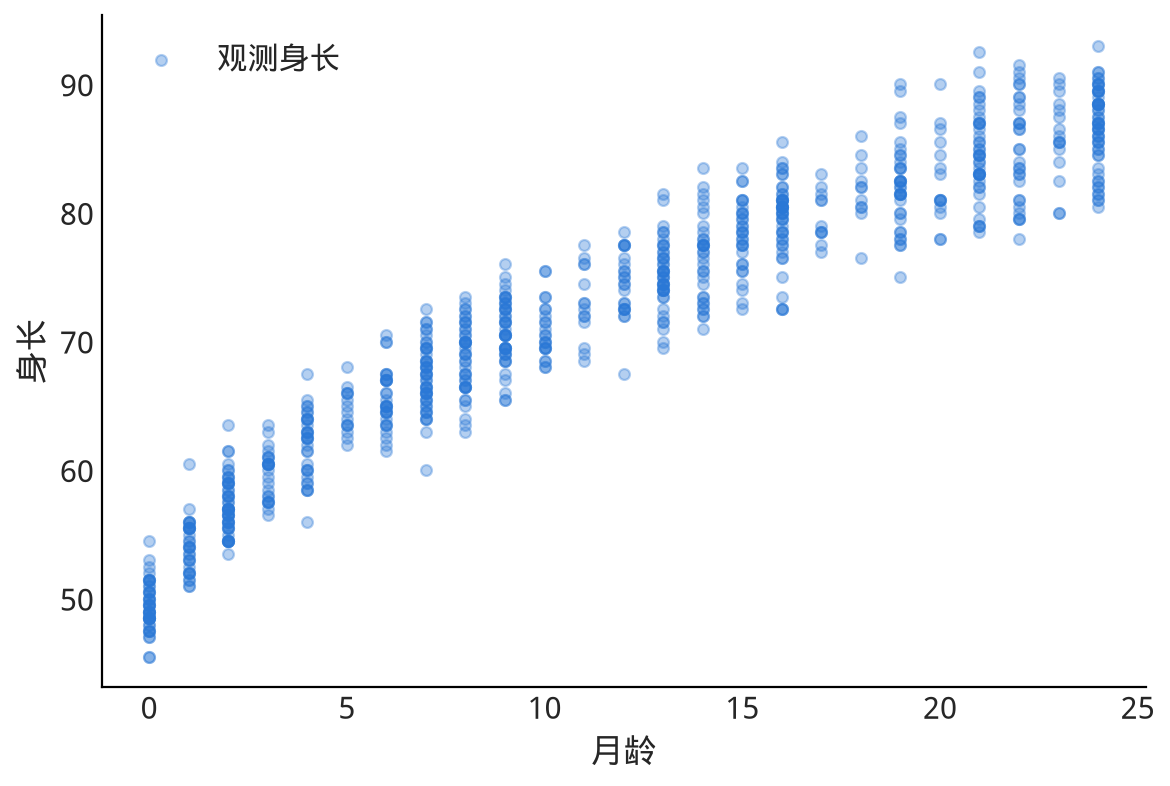

In [3]:
figure, axis = plt.subplots()
axis.scatter(
    babies["Month"], babies["Length"],
    s=24, alpha=0.35, color=SERIES_COLORS[0], label="观测身长",
)
axis.set_ylabel("身长")
axis.set_xlabel("月龄")
axis.legend(frameon=False)
figure.savefig(FIGURE_DIR / "baby_length_scatter.png", bbox_inches="tight")

接下来在代码块 [babies_linear](babies_linear) 中建立模型,用它预测童年各月的身长,并估计婴幼儿
每个月长得多快。这个模型没有进行任何变换,其形式也没有超出[第 3 章](chap2)的内容。

`model_baby_linear` 忠实地给出了线性生长速度。图 {numref}`fig:Baby_Length_Linear` 所示的估计
大约是每个观测月龄增长 1.4 cm。然而,人类显然不会一生都以相同速度生长,并且在生命早期通常
生长得更快;换言之,年龄与身长的关系是非线性的。仔细看图可发现,直线模型倾向于高估接近 0 月龄
和约 10 月龄的身长,又会低估约 25 月龄的身长。我们要求一条直线,模型就给出了一条直线,即便
拟合并不理想。

```{figure} figures/baby_length_linear_fit.png
:name: fig:Baby_Length_Linear
:width: 7.00in
婴幼儿身长的线性预测。橙色线表示均值,深灰带表示后验预测的 50% 最高密度区间(highest density
interval, HDI),浅灰带表示 94% HDI。均值拟合线周围的 HDI 虽覆盖了大多数数据点,但预测在早期
0--3 月和后期 22--25 月往往偏高,在中间 10--15 月则偏低。
```

In [4]:
with pm.Model() as model_baby_linear:
    β = pm.Normal("β", mu=0.0, sigma=10.0, shape=2)
    μ = pm.Deterministic("μ", pm.math.dot(babies[["Intercept", "Month"]].to_numpy(), β))
    ϵ = pm.HalfNormal("ϵ", sigma=10.0)
    length = pm.Normal("length", mu=μ, sigma=ϵ, observed=babies["Length"].to_numpy())
    idata_linear = pm.sample(**sample_kwargs(seed_offset=1, long=True))
    pm.sample_posterior_predictive(
        idata_linear,
        random_seed=SEED + 101,
        progressbar=False,
        extend_inferencedata=True,
    )

Only 24 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [β, ϵ]


Sampling 1 chain for 30 tune and 24 draw iterations (30 + 24 draws total) took 1 seconds.


The number of samples is too small to check convergence reliably.


Sampling: [length]


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.28 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 24 posterior samples and 800 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -3840.47    12.99
p_loo        1.31        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.28]   (good)      351   43.9%
   (0.28, 1]   (bad)       408   51.0%
   (1, Inf)   (very bad)   41    5.1%

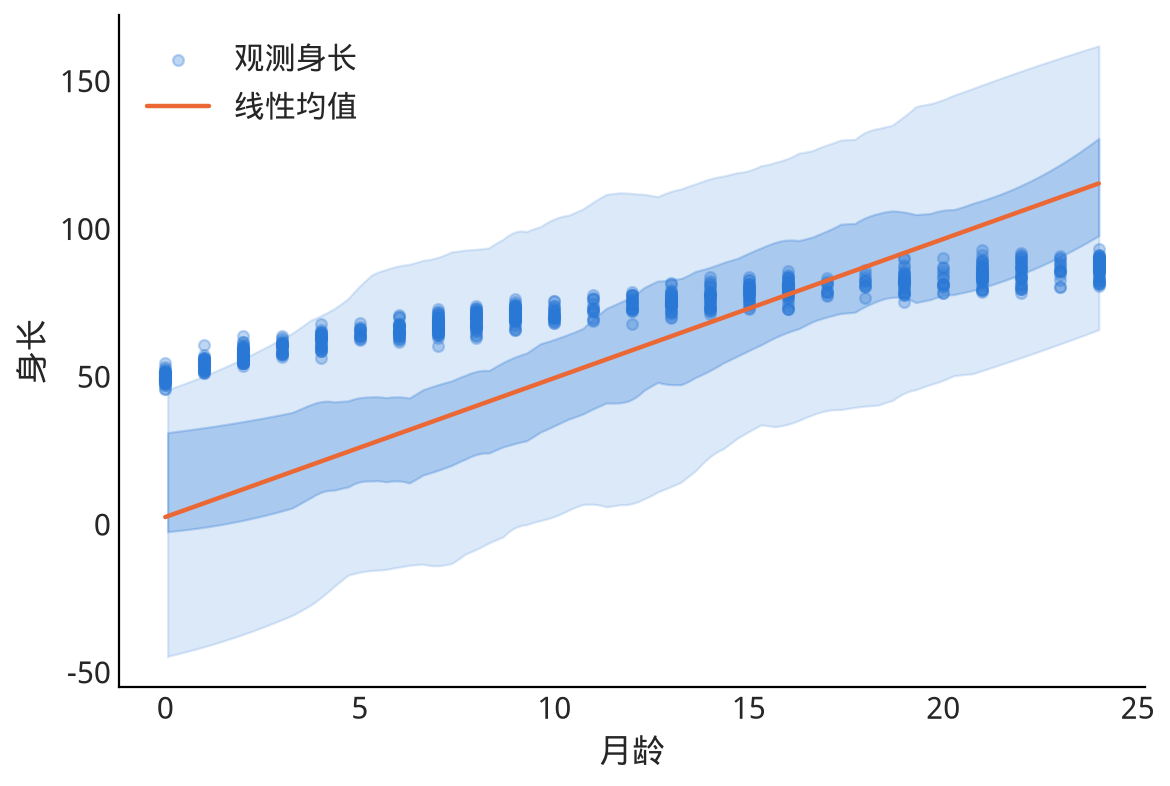

In [5]:
figure, axis = plt.subplots()
month = babies["Month"].to_numpy()
μ_mean = idata_linear.posterior["μ"].mean(("chain", "draw")).values
axis.scatter(month, babies["Length"], s=24, alpha=0.30, color=SERIES_COLORS[0], label="观测身长")
axis.plot(month, μ_mean, color=SERIES_COLORS[1], linewidth=2, label="线性均值")
az.plot_hdi(month, idata_linear.posterior_predictive["length"], hdi_prob=0.94, ax=axis,
            color=SERIES_COLORS[0], fill_kwargs={"alpha": 0.16})
az.plot_hdi(month, idata_linear.posterior_predictive["length"], hdi_prob=0.50, ax=axis,
            color=SERIES_COLORS[0], fill_kwargs={"alpha": 0.28})
axis.set_ylabel("身长")
axis.set_xlabel("月龄")
axis.legend(frameon=False)
figure.savefig(FIGURE_DIR / "baby_length_linear_fit.png", bbox_inches="tight")
loo_linear = az.loo(idata_linear)
loo_linear

我们仍然认为:在任一月龄(也就是观测数据的任一竖直切片)上,婴幼儿身长的分布近似高斯,但月龄
与平均身长的关系是非线性的。具体来说,我们判断这种非线性大体符合对 `Month` 取平方根后的形状,
并在代码块 [babies_transformed](babies_transformed) 中写出 `model_baby_sqrt`。

```{figure} figures/baby_length_sqrt_fit.png
:name: fig:Baby_Length_non_linear
:width: 7.00in
采用变换后协变量的线性预测。左图横轴是未变换的月龄,右图横轴是平方根变换后的月龄;右图可以
清楚看到,原本非线性的生长速度在变换坐标上被线性化。
```

把均值拟合与期望身长的 HDI 带画在一起,就得到图 {numref}`fig:Baby_Length_non_linear`;此时均值
能够顺着观测关系的弯曲形状变化。除可视化检查外,还可以用 `az.compare` 检查非线性模型的期望
逐点对数预测密度(expected log pointwise predictive density, ELPD)。在自己的分析里,你可以使用
任何变换函数。与任何模型选择一样,关键是能够论证为什么选择它,并通过可视化和数值检查确认结果
合理。

In [6]:
with pm.Model() as model_baby_sqrt:
    β = pm.Normal("β", mu=0.0, sigma=10.0, shape=2)
    sqrt_month = np.sqrt(babies["Month"].to_numpy())
    μ = pm.Deterministic("μ", β[0] + β[1] * sqrt_month)
    σ = pm.HalfNormal("σ", sigma=10.0)
    length = pm.Normal("length", mu=μ, sigma=σ, observed=babies["Length"].to_numpy())
    idata_sqrt = pm.sample(**sample_kwargs(seed_offset=2, long=True))
    pm.sample_posterior_predictive(
        idata_sqrt,
        random_seed=SEED + 102,
        progressbar=False,
        extend_inferencedata=True,
    )

Only 24 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [β, σ]


Sampling 1 chain for 30 tune and 24 draw iterations (30 + 24 draws total) took 1 seconds.


The number of samples is too small to check convergence reliably.


Sampling: [length]


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.28 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.28 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
平方根变换模型,0,-3673.718712,70.719045,0.000000,1.0,11.212447,0.000000,True,log
线性模型,1,-3840.471365,1.305435,166.752653,0.0,12.989652,7.788478,True,log


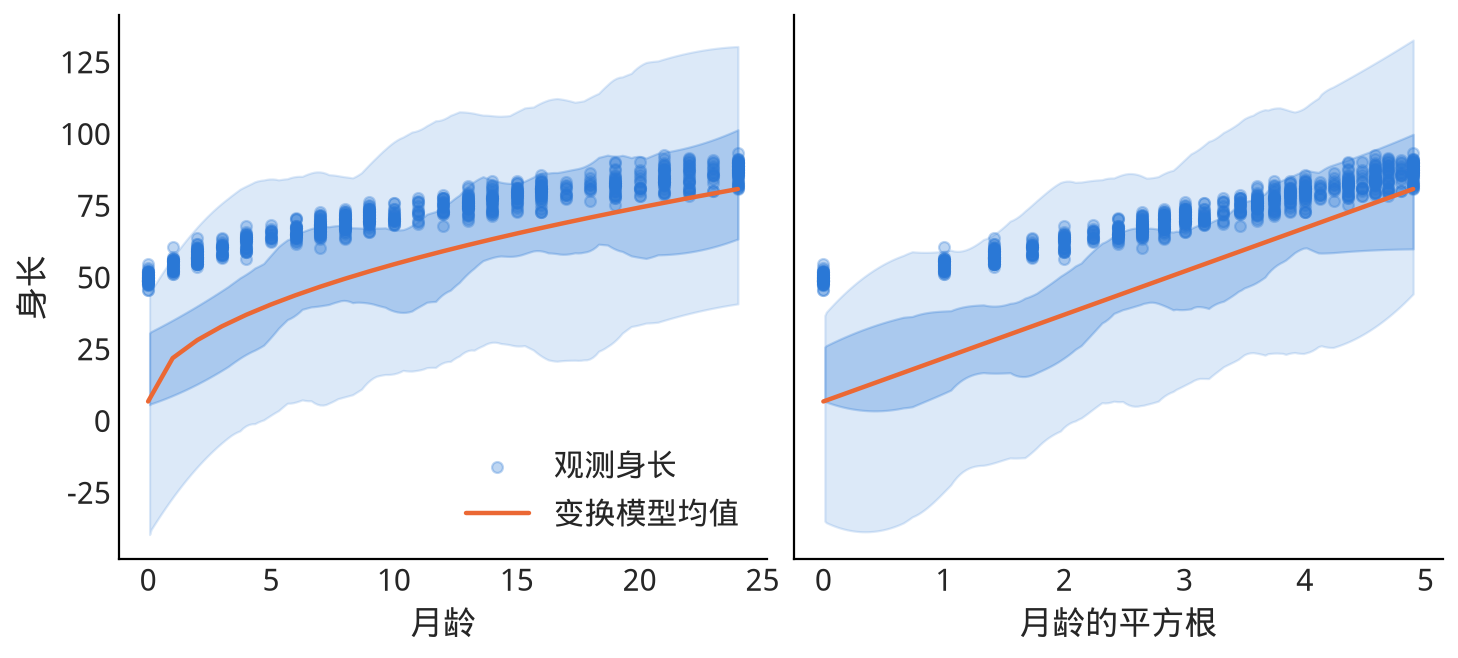

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
month = babies["Month"].to_numpy()
sqrt_month = np.sqrt(month)
μ_mean = idata_sqrt.posterior["μ"].mean(("chain", "draw")).values
for axis, x_values, x_label in zip(axes, (month, sqrt_month), ("月龄", "月龄的平方根"), strict=True):
    axis.scatter(x_values, babies["Length"], s=24, alpha=0.30, color=SERIES_COLORS[0], label="观测身长")
    axis.plot(x_values, μ_mean, color=SERIES_COLORS[1], linewidth=2, label="变换模型均值")
    az.plot_hdi(x_values, idata_sqrt.posterior_predictive["length"], hdi_prob=0.94, ax=axis,
                color=SERIES_COLORS[0], fill_kwargs={"alpha": 0.16})
    az.plot_hdi(x_values, idata_sqrt.posterior_predictive["length"], hdi_prob=0.50, ax=axis,
                color=SERIES_COLORS[0], fill_kwargs={"alpha": 0.28})
    axis.set_xlabel(x_label)
axes[0].set_ylabel("身长")
axes[0].legend(frameon=False)
figure.savefig(FIGURE_DIR / "baby_length_sqrt_fit.png", bbox_inches="tight")
model_compare_babies = az.compare({"线性模型": idata_linear, "平方根变换模型": idata_sqrt}, seed=SEED)
model_compare_babies

(varying-uncertainty)=

## 变化的不确定性

到目前为止,我们用线性模型描述 $Y$ 的均值,并假定残差(residual)[^1]的方差在响应变量的整个取值
范围内保持不变。然而,固定方差只是一个建模选择,并不一定合适。为了表示随协变量变化的不确定性,
可以把式 {eq}`eq:covariate_transformation_regression` 扩展为:

```{math}
:label: eq:varying_variance
\begin{split}
    \mu =& \beta_0 + \beta_1 f_1(X_1) + \dots + \beta_m f_m(X_m) \\
    \sigma =& \delta_0 + \delta_1 g_1(X_1) + \dots + \delta_m g_m(X_m),\quad \sigma>0 \\
Y \sim& \mathcal{N}(\mu, \sigma)
\end{split}
```

第二行对 $\sigma$ 的估计与描述均值的线性项非常相似:线性模型也可以用于均值/位置以外的参数。
不过尺度必须始终为正;一般问题更适合对 $\log\sigma$ 建模或使用 softplus 链接。本例的月龄非负,
并给 $\delta_0,\delta_1$ 使用 HalfNormal 先验,所以显示的直接线性形式在观测与预测域内保持为正。
作为具体例子,我们扩展代码块 [babies_transformed](babies_transformed) 中的 `model_baby_sqrt`。
现在假设年幼儿童的身长彼此更集中,随着年龄增加,身长的离散程度也会增加。

为表示随年龄增加的离散程度,我们把 $\sigma$ 从固定值改成月龄的函数。也就是说,模型假设由
**同方差(homoscedastic)** 改为**异方差(heteroscedastic)**。在代码块
[babies_varying_variance](babies_varying_variance) 中,只需修改模型里 $\sigma$ 的表达式,概率编程
语言就会处理参数估计。结果绘于图 {numref}`fig:Baby_Length_Sqrt_VV_Fit_Include_Error`。

```{figure} figures/baby_length_sqrt_vv_fit_include_error.png
:name: fig:Baby_Length_Sqrt_VV_Fit_Include_Error
:width: 7.00in
两幅月龄与身长参数拟合图。上图的期望均值预测以橙色线表示,与图
{numref}`fig:Baby_Length_non_linear` 基本相同,但后验预测的 HDI 宽度不再恒定。下图把期望误差
$\sigma$ 画成月龄的函数,可以看到误差估计随月龄增加而上升。
```

In [8]:
with pm.Model() as model_baby_vv:
    β = pm.Normal("β", mu=0.0, sigma=10.0, shape=2)
    δ = pm.HalfNormal("δ", sigma=10.0, shape=2)
    month = babies["Month"].to_numpy()
    μ = pm.Deterministic("μ", β[0] + β[1] * np.sqrt(month))
    σ = pm.Deterministic("σ", δ[0] + δ[1] * month)
    length = pm.Normal("length", mu=μ, sigma=σ, observed=babies["Length"].to_numpy())
    idata_baby_vv = pm.sample(**sample_kwargs(seed_offset=3, long=True, target_accept=0.95))
    pm.sample_posterior_predictive(
        idata_baby_vv,
        random_seed=SEED + 103,
        progressbar=False,
        extend_inferencedata=True,
    )
vv_delta_summary = az.summary(idata_baby_vv, var_names=["δ"])
vv_delta_summary

Only 24 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [β, δ]


Sampling 1 chain for 30 tune and 24 draw iterations (30 + 24 draws total) took 5 seconds.


The number of samples is too small to check convergence reliably.


Sampling: [length]


arviz - WARNING - Shape validation failed: input_shape: (1, 24), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
δ[0],5.378,3.123,2.898,9.973,2.174,0.657,2.0,10.0,NaN
δ[1],0.004,0.004,0.001,0.012,0.003,0.001,4.0,12.0,NaN


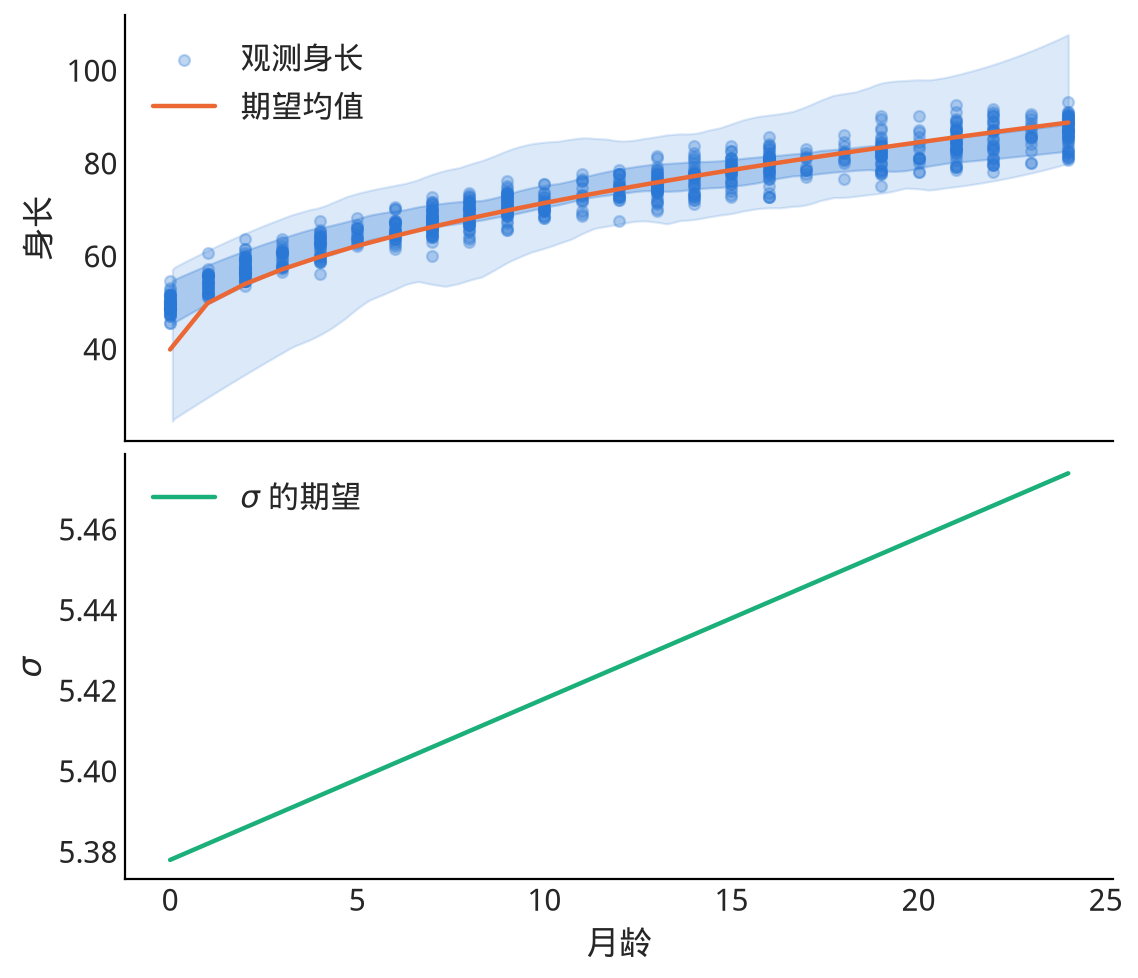

In [9]:
figure, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
month = babies["Month"].to_numpy()
μ_mean = idata_baby_vv.posterior["μ"].mean(("chain", "draw")).values
σ_mean = idata_baby_vv.posterior["σ"].mean(("chain", "draw")).values
axes[0].scatter(month, babies["Length"], s=24, alpha=0.30, color=SERIES_COLORS[0], label="观测身长")
axes[0].plot(month, μ_mean, color=SERIES_COLORS[1], linewidth=2, label="期望均值")
az.plot_hdi(month, idata_baby_vv.posterior_predictive["length"], hdi_prob=0.94, ax=axes[0],
            color=SERIES_COLORS[0], fill_kwargs={"alpha": 0.16})
az.plot_hdi(month, idata_baby_vv.posterior_predictive["length"], hdi_prob=0.50, ax=axes[0],
            color=SERIES_COLORS[0], fill_kwargs={"alpha": 0.28})
axes[0].set_ylabel("身长")
axes[0].legend(frameon=False)
axes[1].plot(month, σ_mean, color=SERIES_COLORS[2], linewidth=2, label=r"$\sigma$ 的期望")
axes[1].set_ylabel(r"$\sigma$")
axes[1].set_xlabel("月龄")
axes[1].legend(frameon=False)
figure.savefig(FIGURE_DIR / "baby_length_sqrt_vv_fit_include_error.png", bbox_inches="tight")

(interaction-effects)=

## 交互效应

此前的模型都假定:一个协变量对响应变量的影响独立于其他协变量。但现实并非总是如此。设想我们
要为某座城镇的冰淇淋销量建模。冰淇淋店越多,可购买的冰淇淋越多,因此销量似乎应该更高;但如果
这座城镇气候寒冷,日均温度为 -5 摄氏度,我们又不会期待很多销量。反过来,如果城镇位于日均温度
30 摄氏度的炎热沙漠,却一家冰淇淋店也没有,销量仍然会很低。只有天气炎热并且购买地点很多时,
我们才预期销量增加。

描述这种联合现象需要引入**交互效应(interaction effect)**:一个协变量对输出变量的作用依赖于
其他协变量的取值。如果像标准线性回归那样假定协变量彼此独立地贡献,就不能完整解释该现象。
交互效应可以写成:

```{math}
:label: eq:interaction_effect
\begin{split}
    \mu =& \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1X_2\\
    Y \sim& \mathcal{N}(\mu, \sigma)
\end{split}
```

其中,$\beta_3$ 是交互项 $X_1X_2$ 的系数。引入交互有其他方式,但计算原始协变量的乘积是非常
常用的选择。与交互效应相对,**主效应(main effect)** 是忽略其他所有协变量时,一个协变量对因变量
的作用。

下面用另一个例子说明。我们在代码块 [tips_no_interaction](tips_no_interaction) 中把就餐者留下的
小费金额建模为账单总额的函数。这很合理,因为小费通常按账单总额的某个百分比计算,具体百分比又会
受到餐厅类型、服务质量、所在国家等因素影响。本例关注吸烟者与非吸烟者的小费金额差异,尤其研究
`smoker` 与 `total_bill` 之间是否有交互效应[^2]。与模型
[penguin_mass_multi](penguin_mass_multi) 一样,可以先把吸烟状态作为独立的分类协变量加入回归;
然后在代码块 [tips_interaction](tips_interaction) 中加入交互项。

```{figure} figures/smoker_tip_interaction.png
:name: fig:Smoker_Tip_Interaction
:width: 7.00in
两个小费模型的线性估计。左图是不含交互的代码块 [tips_no_interaction](tips_no_interaction),两组
估计线互相平行;右图是代码块 [tips_interaction](tips_interaction),其中吸烟状态与账单金额之间存在
交互项,因而两组斜率可以不同。
```

差异在图 {numref}`fig:Smoker_Tip_Interaction` 中很明显:加入交互后,吸烟者与非吸烟者的均值拟合
线不再平行。引入交互实际上让模型按类别拆分数据。你也许会觉得,不如手工拆分数据,分别拟合吸烟者
和非吸烟者两个模型。先别急。交互模型使用全部数据拟合一个模型,能够提高参数估计精度。例如,单个
模型假定 `smoker` 不影响 $\sigma$,所以 $\sigma$ 同时由吸烟者和非吸烟者的数据估计,得到的信息更多。

另一个好处是我们会得到交互效应大小的估计。如果只拆分数据,就不会显式估计交互系数;在一个模型
中表示交互,则可以量化它有多强。最后,在同一数据上建立有交互和无交互的模型,更容易使用留一法
(leave-one-out, LOO)比较。若拆分数据,得到的是在不同数据上评估的模型,而不是在同一数据上评估的
不同模型,这不满足 LOO 模型比较的要求。总之,交互模型的首要差异是允许各组斜率不同,而把所有数据
放在一起建模还会带来许多附加收益。

In [10]:
tips_df = pd.read_csv(DATA_DIR / "tips.csv")
tips = tips_df["tip"].to_numpy()
total_bill_c = (tips_df["total_bill"] - tips_df["total_bill"].mean()).to_numpy()
smoker_category = pd.Categorical(tips_df["smoker"], categories=["No", "Yes"])
smoker = smoker_category.codes

with pm.Model() as model_no_interaction:
    β = pm.Normal("β", mu=0.0, sigma=1.0, shape=3)
    σ = pm.HalfNormal("σ", sigma=1.0)
    μ = β[0] + β[1] * total_bill_c + β[2] * smoker
    obs = pm.Normal("obs", mu=μ, sigma=σ, observed=tips)
    idata_no_interaction = pm.sample(**sample_kwargs(seed_offset=4))

no_interaction_posterior = idata_no_interaction.posterior
no_interaction_posterior

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [β, σ]


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 3 seconds.


The number of samples is too small to check convergence reliably.


<xarray.Dataset> Size: 832B
Dimensions:  (chain: 1, draw: 20, β_dim_0: 3)
Coordinates:
  * chain    (chain) int64 8B 0
  * draw     (draw) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
  * β_dim_0  (β_dim_0) int64 24B 0 1 2
Data variables:
    β        (chain, draw, β_dim_0) float64 480B 3.145 0.1122 ... -0.04468
    σ        (chain, draw) float64 160B 1.027 1.052 1.019 ... 1.001 1.012 0.999
Attributes:
    created_at:                 2026-08-21T15:59:47.375103+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5
    sampling_time:              2.7774200439453125
    tuning_steps:               20

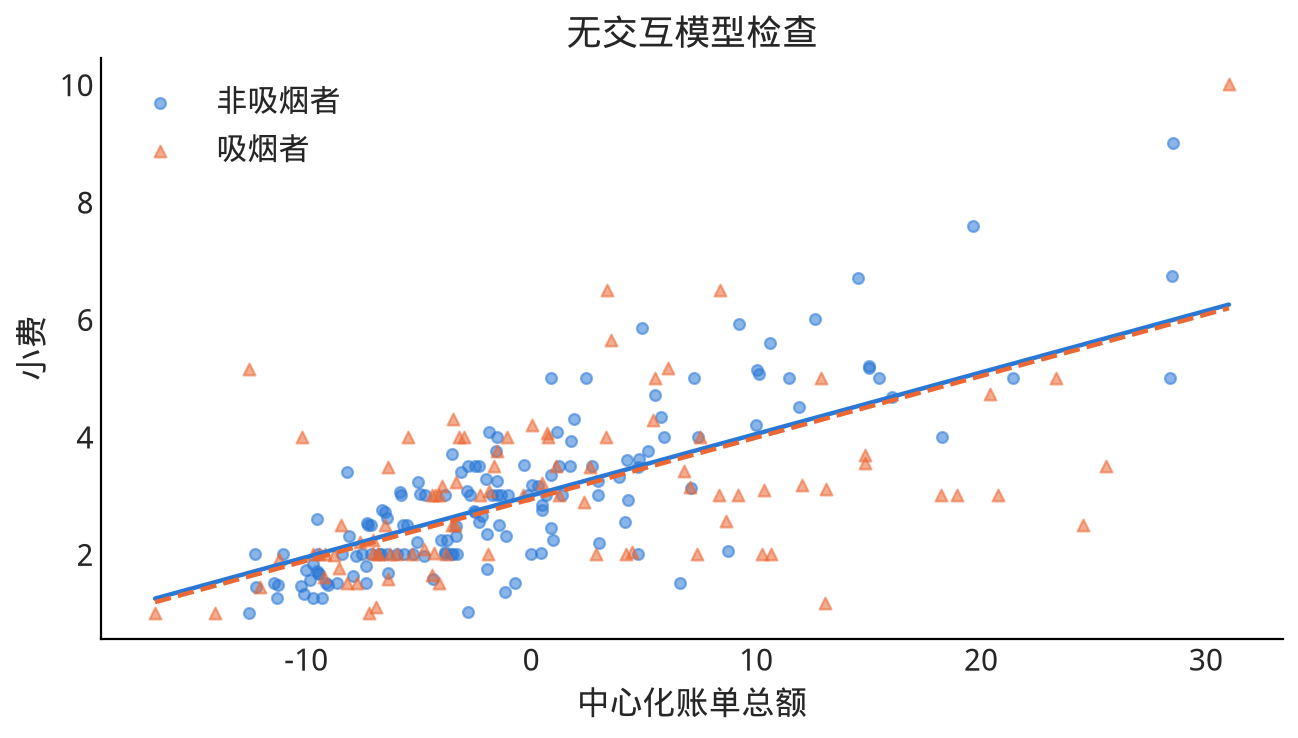

In [11]:
x_grid_no_interaction = np.linspace(total_bill_c.min(), total_bill_c.max(), 120)
posterior_no_interaction = az.extract(
    idata_no_interaction, var_names=["β"]
).transpose("sample", "β_dim_0").values
no_non_smoker_preview = (
    posterior_no_interaction[:, 0, None]
    + posterior_no_interaction[:, 1, None] * x_grid_no_interaction
)
no_smoker_preview = no_non_smoker_preview + posterior_no_interaction[:, 2, None]

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.scatter(total_bill_c[smoker == 0], tips[smoker == 0], marker="o", s=24,
             color=SERIES_COLORS[0], alpha=0.55, label="非吸烟者")
axis.scatter(total_bill_c[smoker == 1], tips[smoker == 1], marker="^", s=28,
             color=SERIES_COLORS[1], alpha=0.55, label="吸烟者")
axis.plot(x_grid_no_interaction, no_non_smoker_preview.mean(axis=0),
          color=SERIES_COLORS[0], linestyle="-", linewidth=2)
axis.plot(x_grid_no_interaction, no_smoker_preview.mean(axis=0),
          color=SERIES_COLORS[1], linestyle="--", linewidth=2)
axis.set_xlabel("中心化账单总额")
axis.set_ylabel("小费")
axis.set_title("无交互模型检查")
axis.legend(frameon=False)

In [12]:
with pm.Model() as model_interaction:
    β = pm.Normal("β", mu=0.0, sigma=1.0, shape=4)
    σ = pm.HalfNormal("σ", sigma=1.0)
    μ = β[0] + β[1] * total_bill_c + β[2] * smoker + β[3] * smoker * total_bill_c
    obs = pm.Normal("obs", mu=μ, sigma=σ, observed=tips)
    idata_interaction = pm.sample(**sample_kwargs(seed_offset=5))

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [β, σ]


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 2 seconds.


The number of samples is too small to check convergence reliably.


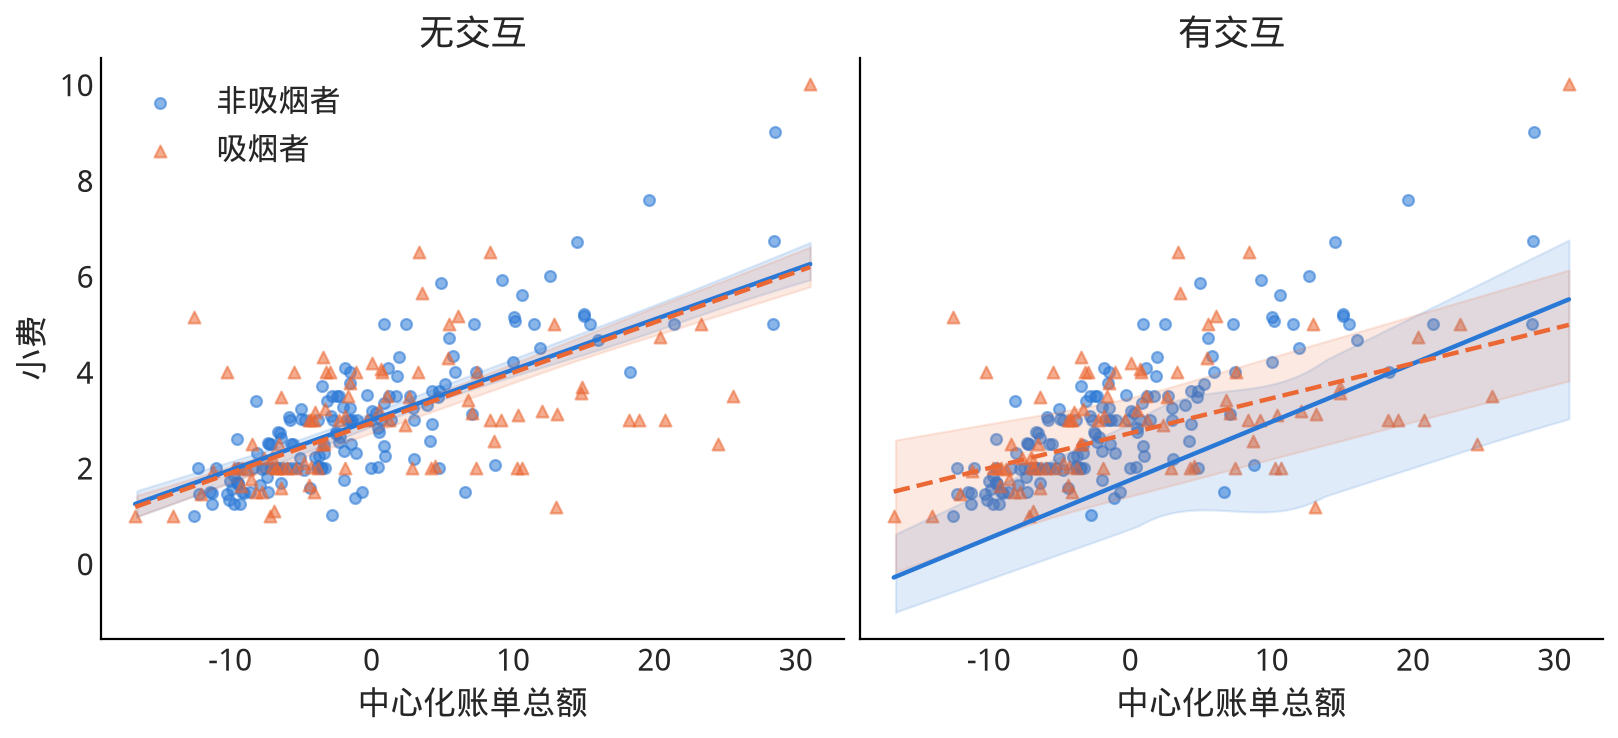

In [13]:
x_grid = np.linspace(total_bill_c.min(), total_bill_c.max(), 120)
posterior_no = az.extract(
    idata_no_interaction, var_names=["β"]
).transpose("sample", "β_dim_0").values
posterior_yes = az.extract(
    idata_interaction, var_names=["β"]
).transpose("sample", "β_dim_0").values

no_non_smoker = posterior_no[:, 0, None] + posterior_no[:, 1, None] * x_grid
no_smoker = no_non_smoker + posterior_no[:, 2, None]
yes_non_smoker = posterior_yes[:, 0, None] + posterior_yes[:, 1, None] * x_grid
yes_smoker = (
    posterior_yes[:, 0, None]
    + posterior_yes[:, 1, None] * x_grid
    + posterior_yes[:, 2, None]
    + posterior_yes[:, 3, None] * x_grid
)

figure, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for axis, predictions, title in zip(
    axes,
    ((no_non_smoker, no_smoker), (yes_non_smoker, yes_smoker)),
    ("无交互", "有交互"),
    strict=True,
):
    axis.scatter(total_bill_c[smoker == 0], tips[smoker == 0], marker="o", s=24,
                 color=SERIES_COLORS[0], alpha=0.55, label="非吸烟者")
    axis.scatter(total_bill_c[smoker == 1], tips[smoker == 1], marker="^", s=28,
                 color=SERIES_COLORS[1], alpha=0.55, label="吸烟者")
    for draws, color, linestyle in zip(predictions, SERIES_COLORS[:2], ("-", "--"), strict=True):
        axis.plot(x_grid, draws.mean(axis=0), color=color, linestyle=linestyle, linewidth=2)
        az.plot_hdi(
            x_grid, draws[None, ...], hdi_prob=0.94, ax=axis,
            color=color, fill_kwargs={"alpha": 0.14})
    axis.set_title(title)
    axis.set_xlabel("中心化账单总额")
axes[0].set_ylabel("小费")
axes[0].legend(frameon=False)
figure.savefig(FIGURE_DIR / "smoker_tip_interaction.png", bbox_inches="tight")

(robust_regression)=

## 稳健回归

顾名思义,离群值(outlier)是落在“合理预期”范围之外的观测。离群值可能很棘手,因为一个或少数几个
数据点就可能显著改变模型的参数估计。处理离群值有多种正式方法 {cite:p}`grubbs_1969`,但实践中
如何处理仍是统计工作者必须做出的选择(即使选择某种正式方法本身也是主观决定)。至少有两条常见
路径:一是按照预先规定的标准删除数据,例如超过 3 个标准差或 1.5 倍四分位距;二是选择能够容纳
离群值、同时仍给出有用结果的模型。

回归中的后一类方法通常称为**稳健回归(robust regression)**,强调模型对远离数据主体的观测不那么
敏感。更严格地说,稳健回归旨在降低底层数据生成过程违反模型假设时造成的影响。在贝叶斯回归中,
一个典型做法是把似然从高斯分布改成 Student $t$ 分布。

高斯分布由通常称为位置 $\mu$ 和尺度 $\sigma$ 的两个参数定义,它们控制高斯分布的均值与标准差。
Student $t$ 分布也有位置和尺度参数[^3],但还多一个通常称为自由度的参数 $\nu$。如图
{numref}`fig:StudentT_Normal_Comparison` 所示,$\nu$ 控制尾部权重。比较 3 个 Student $t$ 分布
与正态分布时,关键差异是概率密度在尾部与主体之间的分配比例。$\nu$ 较小时,尾部质量更大;随着
$\nu$ 增大,更多密度集中到主体,Student $t$ 分布越来越接近高斯分布。实践上,这意味着 $\nu$ 较小
时,远离均值的取值更可能出现。因此,用 Student $t$ 似然替换高斯似然可以提供对离群值的稳健性。

```{figure} figures/studentt_normal_comparison.png
:name: fig:StudentT_Normal_Comparison
:width: 7.00in
蓝色正态分布与 3 个具有不同 $\nu$ 的 Student $t$ 分布。所有分布的位置和尺度参数完全相同,从而
隔离 $\nu$ 对尾部的影响。$\nu$ 越小,尾部得到的概率密度越多。
```

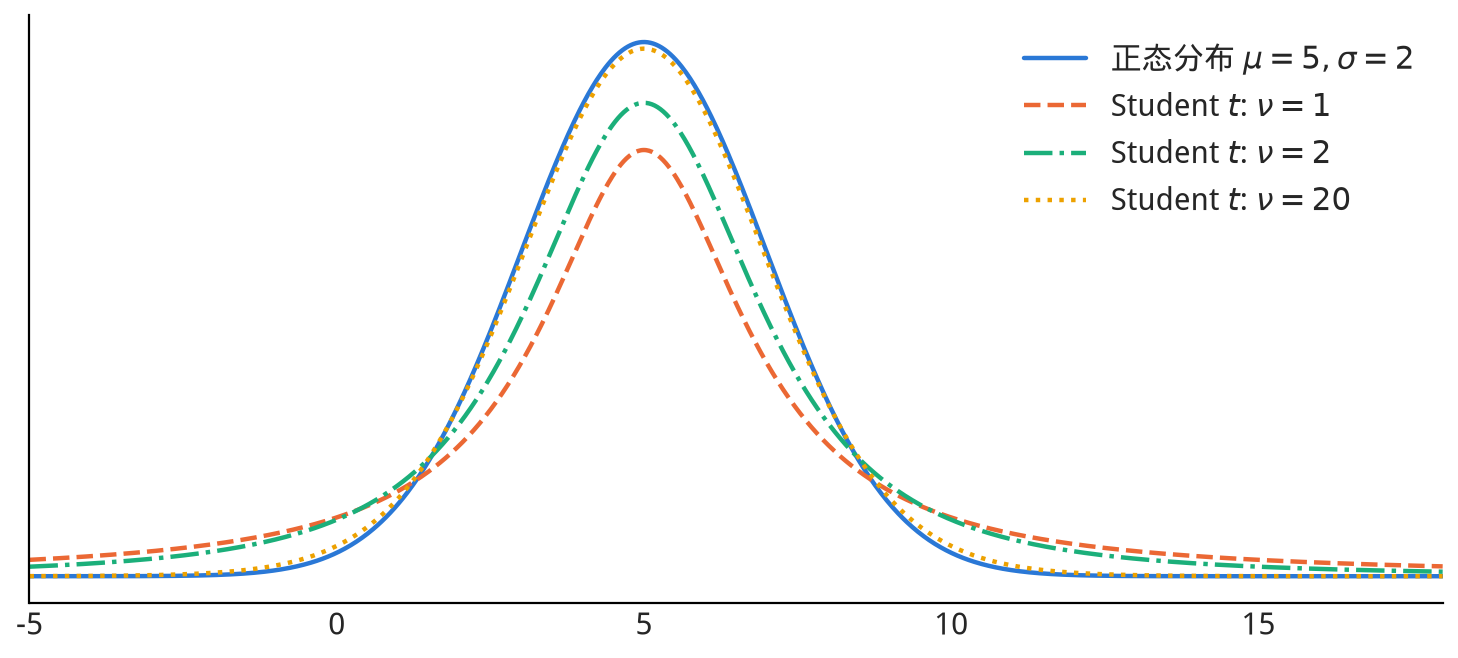

In [14]:
location = 5.0
scale = 2.0
x_values = np.linspace(-5.0, 18.0, 1000)
figure, axis = plt.subplots(figsize=(9, 4))
axis.plot(x_values, stats.norm(location, scale).pdf(x_values), color=SERIES_COLORS[0], linewidth=2,
          label=rf"正态分布 $\mu={location:g},\sigma={scale:g}$")
for nu, color, linestyle in zip((1, 2, 20), SERIES_COLORS[1:4], ("--", "-.", ":"), strict=True):
    axis.plot(x_values, stats.t(loc=location, scale=scale, df=nu).pdf(x_values),
              color=color, linestyle=linestyle, linewidth=2,
              label=rf"Student $t$: $\nu={nu}$")
axis.set_xlim(-5, 18)
axis.set_yticks([])
axis.legend(loc="upper right", frameon=False)
figure.savefig(FIGURE_DIR / "studentt_normal_comparison.png", bbox_inches="tight")

可以用一个例子展示这种差异。假设你在阿根廷经营一家出售馅饼(empanada)[^4]的餐厅。长期以来,
你收集了每天顾客人数和餐厅获得的阿根廷比索总额,如图 {numref}`fig:Empanada_Scatter_Plot` 所示。
大多数数据点沿一条直线分布,只有少数几天,每位顾客购买的馅饼明显多于周围数据。这可能是 5 月
25 日或 7 月 9 日[^5]等大型庆典日,人们会比平时吃更多馅饼。

```{figure} figures/empanada_scatter_plot.png
:name: fig:Empanada_Scatter_Plot
:width: 7.00in
顾客人数与比索收入的模拟数据。图顶端的 5 个点被视为离群值。
```

不论是否存在离群值,我们都想估计顾客人数与收入之间的关系。散点图表明线性回归似乎合适,于是先
使用代码块 [non_robust_regression](non_robust_regression) 中的高斯似然。估计参数后,图
{numref}`fig:Empanada_Scatter_Non_Robust` 在两种纵轴尺度上展示均值回归。下图中,拟合线位于几乎
所有主体数据点上方。表 {numref}`tab:non_robust_regression` 保留原书发布运行的参数快照,其中
$\sigma$ 的均值约为 2951,相对于主体数据的散布非常大。当前确定性数据生成器或抽样版本的权威数值
应读取代码输出 `non_robust_summary`;尤其不能把默认 smoke 的 20 次抽样当作发布估计。正态似然必须
把后验“拉伸”到同时覆盖普通观测和 5 个离群观测,所以估计受到明显影响。

```{figure} figures/empanada_scatter_non_robust.png
:name: fig:Empanada_Scatter_Non_Robust
:width: 7.00in
代码块 [non_robust_regression](non_robust_regression) 的数据、拟合回归线与 94% HDI。上图包含离群
值,下图聚焦回归主体。下图中均值回归线系统性地高于普通数据点,偏差更明显。
```

```{list-table} 原书发布运行中非稳健回归模型的参数估计快照。
:name: tab:non_robust_regression
* -
  - **mean**
  - **sd**
  - **hdi_3%**
  - **hdi_97%**
* - $\beta$
  - 207.1
  - 2.9
  - 201.7
  - 212.5
* - $\sigma$
  - 2951.1
  - 25.0
  - 2904.5
  - 2997.7
```

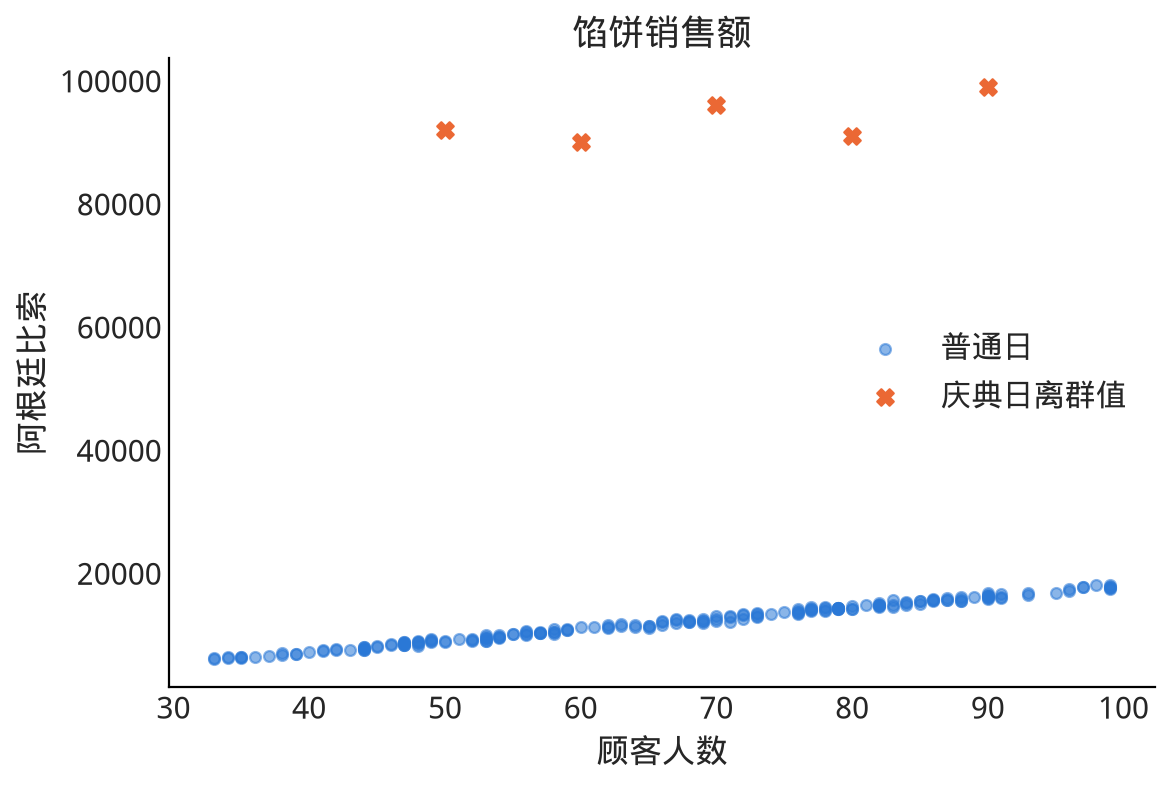

In [15]:
def generate_sales(*, days, mean, std, label, seed):
    """生成每日顾客数和总销售额,并保留原数据列名。"""
    local_rng = np.random.default_rng(seed)
    customers = local_rng.integers(31, 101, size=days, dtype=np.int32)
    sales = np.array([
        local_rng.normal(mean, std, size=int(count)).sum()
        for count in customers
    ], dtype=np.float64)
    frame = pd.DataFrame({"customers": customers, "sales": sales, "Food_Category": label})
    return frame.sort_values("customers").reset_index(drop=True)

empanadas = generate_sales(days=200, mean=180, std=30, label="Empanada", seed=SEED + 20)
outlier_rows = pd.DataFrame({
    "customers": np.array([50, 60, 70, 80, 90], dtype=np.int32),
    "sales": np.array([92000.0, 90000.0, 96000.0, 91000.0, 99000.0]),
    "Food_Category": ["Empanada"] * 5,
})
empanadas = pd.concat(
    [outlier_rows, empanadas.iloc[5:]], ignore_index=True
).sort_values("customers").reset_index(drop=True)

ordinary = empanadas.nsmallest(len(empanadas) - 5, "sales")
outliers = empanadas.nlargest(5, "sales")
figure, axis = plt.subplots()
axis.scatter(ordinary["customers"], ordinary["sales"], s=24, alpha=0.55,
             color=SERIES_COLORS[0], label="普通日")
axis.scatter(outliers["customers"], outliers["sales"], marker="X", s=55,
             color=SERIES_COLORS[1], label="庆典日离群值")
axis.set_ylabel("阿根廷比索")
axis.set_xlabel("顾客人数")
axis.set_title("馅饼销售额")
axis.legend(frameon=False)
figure.savefig(FIGURE_DIR / "empanada_scatter_plot.png", bbox_inches="tight")

In [16]:
with pm.Model() as model_non_robust:
    σ = pm.HalfNormal("σ", sigma=50.0)
    β = pm.Normal("β", mu=150.0, sigma=20.0)
    μ = pm.Deterministic("μ", β * empanadas["customers"].to_numpy())
    sales = pm.Normal("sales", mu=μ, sigma=σ, observed=empanadas["sales"].to_numpy())
    idata_non_robust = pm.sample(**sample_kwargs(seed_offset=6))
    pm.sample_posterior_predictive(
        idata_non_robust,
        random_seed=SEED + 106,
        progressbar=False,
        extend_inferencedata=True,
    )

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [σ, β]


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 3 seconds.


The number of samples is too small to check convergence reliably.


Sampling: [sales]


,mean,sd,hdi_3%,hdi_97%
β,150.5,0.8,150.0,152.3
σ,2501.1,796.9,1279.6,3037.6


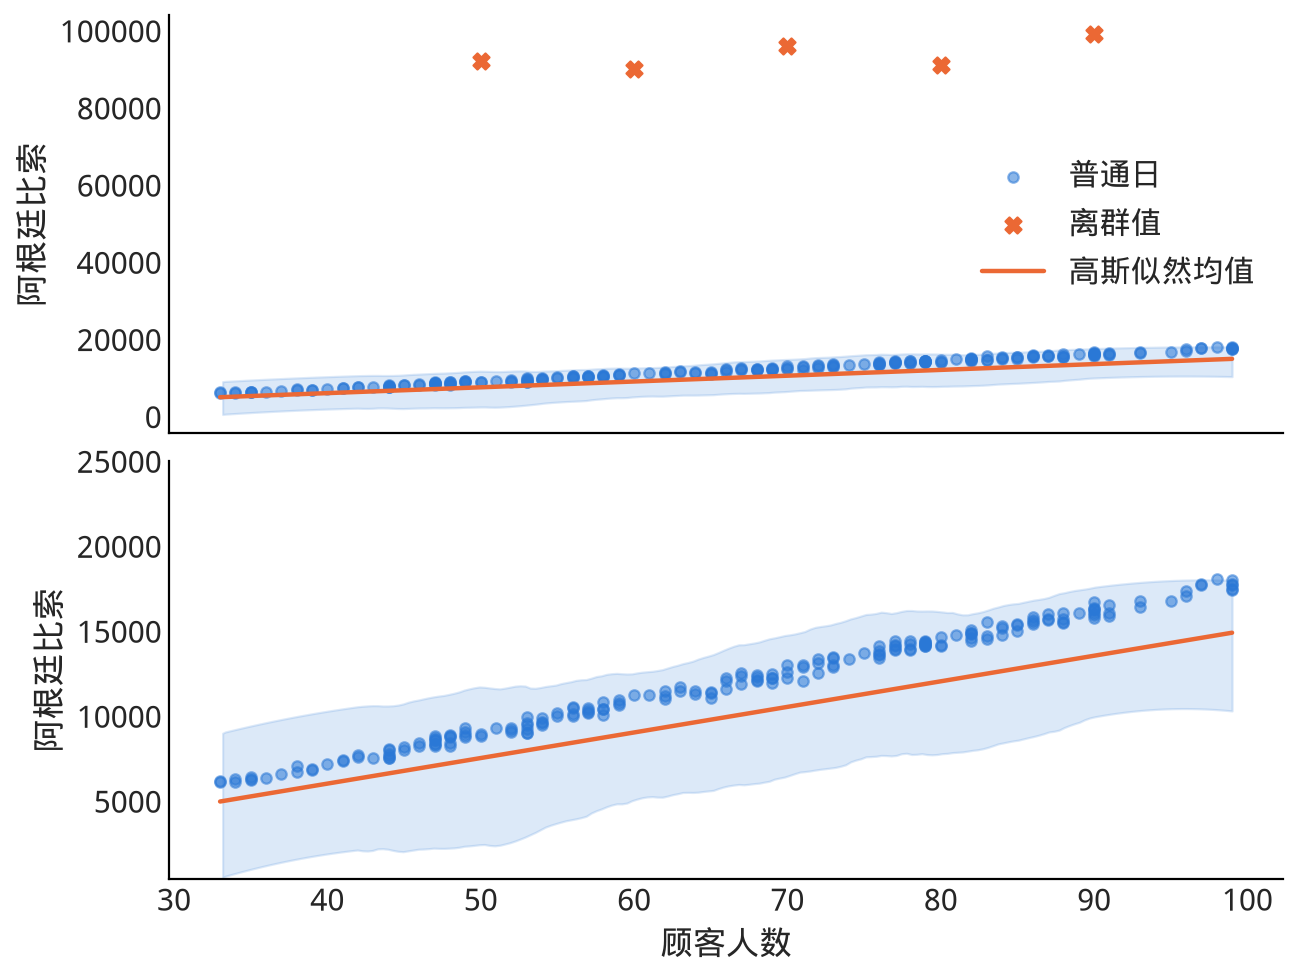

In [17]:
figure, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
μ_mean = idata_non_robust.posterior["μ"].mean(("chain", "draw")).values
for axis in axes:
    axis.scatter(ordinary["customers"], ordinary["sales"], s=22, alpha=0.55,
                 color=SERIES_COLORS[0], label="普通日")
    axis.scatter(outliers["customers"], outliers["sales"], marker="X", s=52,
                 color=SERIES_COLORS[1], label="离群值")
    axis.plot(empanadas["customers"], μ_mean, color=SERIES_COLORS[1], linewidth=2,
              label="高斯似然均值")
    az.plot_hdi(empanadas["customers"].to_numpy(), idata_non_robust.posterior_predictive["sales"],
                hdi_prob=0.94, ax=axis, color=SERIES_COLORS[0], fill_kwargs={"alpha": 0.16})
axes[0].legend(frameon=False)
axes[1].set_ylim(400, 25000)
axes[1].set_xlabel("顾客人数")
for axis in axes:
    axis.set_ylabel("阿根廷比索")
figure.savefig(FIGURE_DIR / "empanada_scatter_non_robust.png", bbox_inches="tight")

non_robust_summary = az.summary(
    idata_non_robust, kind="stats", var_names=["β", "σ"]
).round(1)
non_robust_summary

下面在同一数据上重复回归,但像代码块 [code_robust_regression](code_robust_regression) 那样把似然改成
Student $t$ 分布;离群值仍保留在数据中。图 {numref}`fig:Empanada_Scatter_Robust` 中的位置参数
拟合线穿过普通观测点之间,比非稳健结果更符合预期。由于先验允许 $\nu\leq1$,这条线不能一概称为
条件均值:当 $\nu\leq1$ 时 Student $t$ 分布的均值不存在。表 {numref}`tab:robust_regression` 多出了
参数 $\nu$。表中数值同样是原书发布运行的历史快照;当前发布配置应以代码输出 `robust_summary`
为准。原书快照中,$\sigma$ 的估计从非稳健回归中的约 2951 比索降到稳健回归中的约 152 比索;与图中
主体数据相比,新估计在逻辑上合理得多。Student $t$ 分布有足够灵活性,即使存在离群值也能合理描述
主体数据。

```{list-table} 原书发布运行中稳健回归模型的参数估计快照。
:name: tab:robust_regression
* -
  - **mean**
  - **sd**
  - **hdi_3%**
  - **hdi_97%**
* - $\beta$
  - 179.6
  - 0.3
  - 179.1
  - 180.1
* - $\sigma$
  - 152.3
  - 13.9
  - 127.1
  - 179.5
* - $\nu$
  - 1.3
  - 0.2
  - 1.0
  - 1.6
```

```{figure} figures/empanada_scatter_robust.png
:name: fig:Empanada_Scatter_Robust
:width: 7.00in
代码块 [code_robust_regression](code_robust_regression) 中 `model_robust` 的数据、拟合回归线和 94% HDI。
离群值没有显示在聚焦图中,但仍存在于拟合数据。与图 {numref}`fig:Empanada_Scatter_Non_Robust`
相比,拟合线落在普通数据点的范围内。
```

本例中的“离群值”其实是我们想描述的问题的一部分:它们不是测量错误或录入错误,而是在某些条件下
确实可能发生的观测。如果目标是描述“普通”日的平均馅饼销量,把它们当作离群值没有问题;但若用该
平均值规划下一个 5 月 25 日或 7 月 9 日,就可能酿成灾难。因此,这里的稳健线性回归是在不显式描述
高销量日的情况下获得普通日关系的一种技巧。若高销量日也很重要,混合模型或多层模型可能更合适。

::: {admonition} 针对数据特征调整模型

为获得稳健性而改变似然,只是让模型更符合观测数据的一种修改。例如,探测放射性粒子发射时,零计数
可能来自故障传感器(或其他测量问题),也可能确实没有事件可记录 {cite:p}`betancourt_2020_worfklow`。
这个未知来源会“膨胀”零的数量。对此很有帮助的一类模型恰当地称为**零膨胀模型(zero-inflated
model)**,它同时估计组合的数据生成过程。例如,计数建模常从泊松似然开始,再扩展成零膨胀泊松似然,
以便更好地区分泊松过程产生的计数和“额外零生成过程”产生的计数。

零膨胀模型处理的是混合数据:观测来自两个或更多组,但我们不知道每个观测属于哪一组。事实上,还可
用混合似然写出另一种稳健回归,为每个数据点分配一个潜在标签(离群或非离群)。在这些以及更多情形
中,贝叶斯模型的定制能力让建模者可以让模型适应问题,而不必把问题硬塞进预定义模型。
:::

In [18]:
with pm.Model() as model_robust:
    σ = pm.HalfNormal("σ", sigma=50.0)
    β = pm.Normal("β", mu=150.0, sigma=20.0)
    ν = pm.HalfNormal("ν", sigma=20.0)
    μ = pm.Deterministic("μ", β * empanadas["customers"].to_numpy())
    sales = pm.StudentT("sales", mu=μ, sigma=σ, nu=ν, observed=empanadas["sales"].to_numpy())
    idata_robust = pm.sample(**sample_kwargs(seed_offset=7))
    pm.sample_posterior_predictive(
        idata_robust,
        random_seed=SEED + 107,
        progressbar=False,
        extend_inferencedata=True,
    )
robust_summary = az.summary(idata_robust, var_names=["β", "σ", "ν"], kind="stats").round(1)
robust_summary

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [σ, β, ν]


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 3 seconds.


The number of samples is too small to check convergence reliably.


Sampling: [sales]


,mean,sd,hdi_3%,hdi_97%
β,157.0,1.5,153.8,158.7
σ,564.1,33.0,511.4,627.3
ν,0.9,0.2,0.7,1.1


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.23 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.23 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ai/Projects/BookCo

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
稳健,0,-1949.739209,4.914138,0.000000,0.106933,18.558309,0.000000,True,log
非稳健,1,-12539.058502,8821.100201,10589.319293,0.893067,4728.838060,4711.939473,True,log


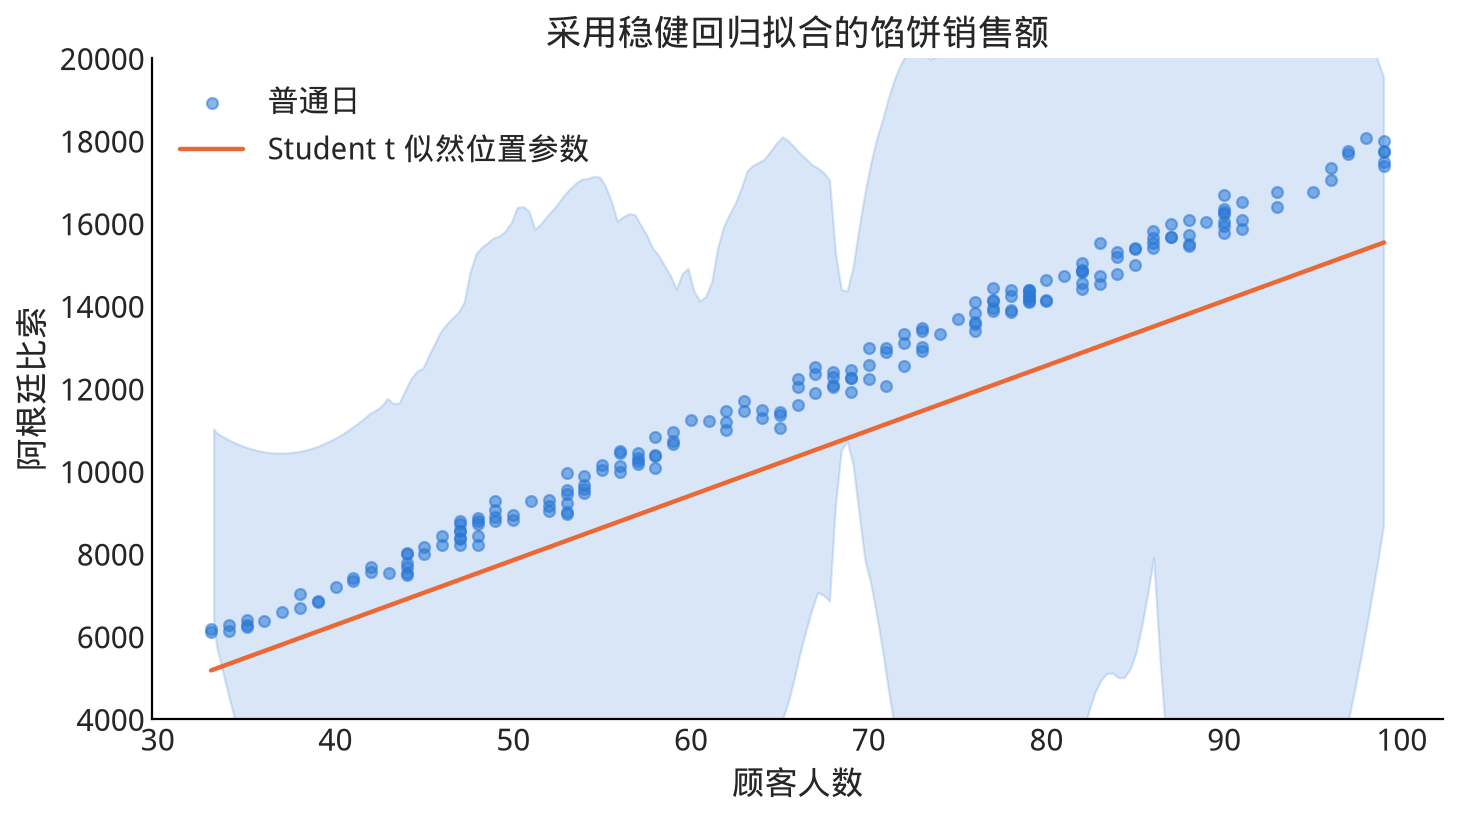

In [19]:
figure, axis = plt.subplots(figsize=(9, 5))
μ_mean = idata_robust.posterior["μ"].mean(("chain", "draw")).values
axis.scatter(ordinary["customers"], ordinary["sales"], s=24, alpha=0.55,
             color=SERIES_COLORS[0], label="普通日")
axis.plot(empanadas["customers"], μ_mean, color=SERIES_COLORS[1], linewidth=2,
          label="Student t 似然位置参数")
az.plot_hdi(empanadas["customers"].to_numpy(), idata_robust.posterior_predictive["sales"],
            hdi_prob=0.94, ax=axis, color=SERIES_COLORS[0], fill_kwargs={"alpha": 0.18})
axis.set_ylim(4000, 20000)
axis.set_ylabel("阿根廷比索")
axis.set_xlabel("顾客人数")
axis.set_title("采用稳健回归拟合的馅饼销售额")
axis.legend(frameon=False)
figure.savefig(FIGURE_DIR / "empanada_scatter_robust.png", bbox_inches="tight")
robust_compare = az.compare({"非稳健": idata_non_robust, "稳健": idata_robust}, seed=SEED)
robust_compare

(multilevel_models)=

## 合并、多层模型与混合效应

数据集中的预测变量往往还带有嵌套结构,因此可以按层级对数据分组;也可以把这些组理解为不同的数据
生成过程。下面用一个例子说明。假设你在一家出售沙拉的餐饮公司工作。公司在一些地理市场经营已久,
又因顾客需求在一个新市场开了门店。为了财务规划,你需要预测新市场中这家门店每天能赚多少美元。
你有两类数据:沙拉销售仅有 3 天,而同一市场的披萨和三明治销售各有大约一年。模拟数据见图
{numref}`fig:Restaurant_Order_Scatter`。

```{figure} figures/restaurant_order_scatter.png
:name: fig:Restaurant_Order_Scatter
:width: 7.00in
一个模拟的现实场景:组织只有 3 个沙拉日销售额数据点,但拥有大量披萨和三明治销售数据。
```

领域知识与数据都表明,这 3 类食品的销量有相似之处:它们面向同类顾客,同属“即买即走”的快捷
食品,但又不完全相同。接下来会讨论如何描述这种“相似但不同”。先从最简单的情况开始:假定各组
彼此无关。

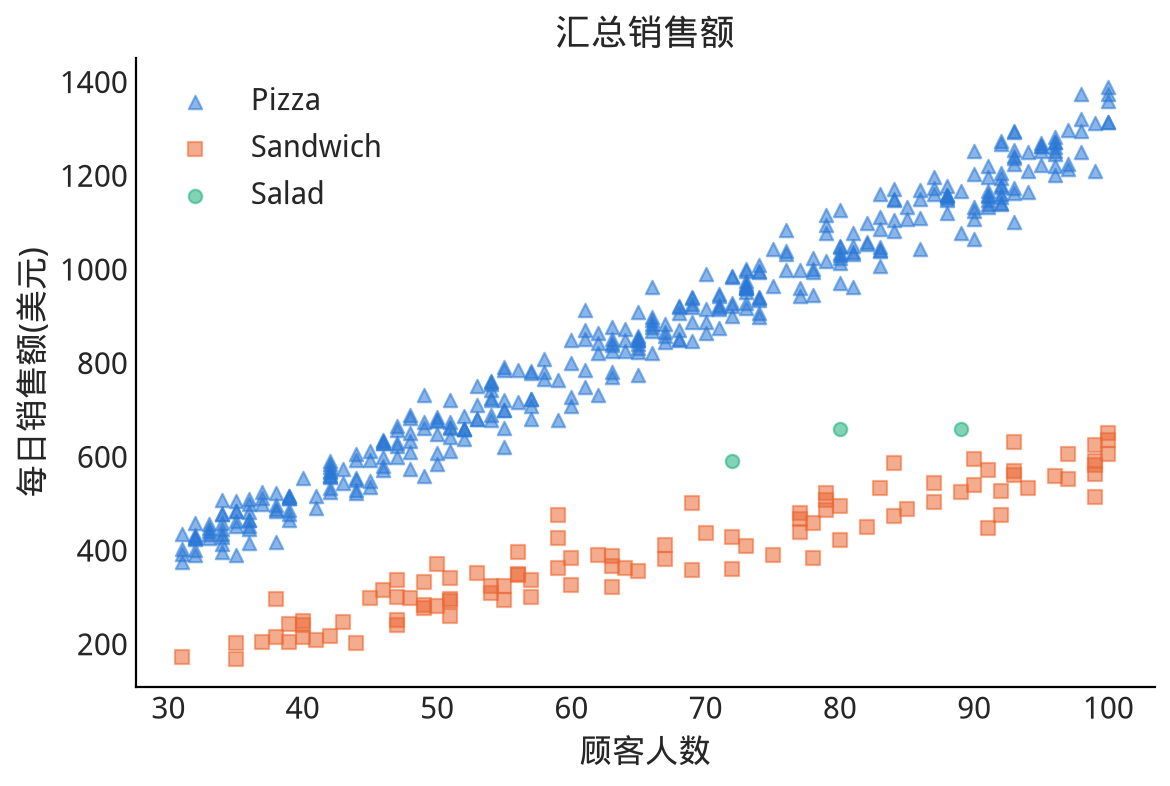

In [20]:
pizza_df = generate_sales(days=365, mean=13, std=5, label="Pizza", seed=SEED + 30)
sandwich_df = generate_sales(days=100, mean=6, std=5, label="Sandwich", seed=SEED + 31)
salad_df = generate_sales(days=3, mean=8, std=3, label="Salad", seed=SEED + 32)

meal_levels = ["Pizza", "Sandwich", "Salad"]
sales_df = pd.concat([pizza_df, sandwich_df, salad_df], ignore_index=True)
sales_df["Food_Category"] = pd.Categorical(
    sales_df["Food_Category"], categories=meal_levels, ordered=True
)

figure, axis = plt.subplots()
for meal, marker, color in zip(meal_levels, ("^", "s", "o"), SERIES_COLORS[:3], strict=True):
    subset = sales_df[sales_df["Food_Category"] == meal]
    axis.scatter(subset["customers"], subset["sales"], marker=marker, s=36,
                 alpha=0.55, color=color, label=meal)
axis.set_xlabel("顾客人数")
axis.set_ylabel("每日销售额(美元)")
axis.set_title("汇总销售额")
axis.legend(frameon=False)
figure.savefig(FIGURE_DIR / "restaurant_order_scatter.png", bbox_inches="tight")

(unpooled-parameters)=

### 不合并参数

可以建立一个回归模型,把每一组(本例是食品类别)完全独立地对待。这等价于为每个类别分别运行回归,
所以称为**不合并回归(unpooled regression)**。与真正分别运行 3 个模型唯一的区别是:这里写成一个
模型,并同时估计全部系数。参数与组的关系示意见图 {numref}`fig:unpooled_model`;式
{eq}`eq:unpooled_regression` 中,$j$ 是识别各个独立组的索引。

```{figure} figures/unpooled_model.png
:name: fig:unpooled_model
:width: 5.00in
不合并模型:每组观测 $y_1,y_2,\ldots,y_j$ 都有自己的一组参数,并且独立于其他组。
```

```{math}
:label: eq:unpooled_regression
\begin{split}
\beta_{mj} \sim& \overbrace{\mathcal{N}(\mu_{\beta m}, \sigma_{\beta m})}^{\text{组特异}}\\
\sigma_{j} \sim& \overbrace{\mathcal{HN}(\sigma_{\sigma})}^{\text{组特异}}\\
\mu_{j} =& \beta_{1j} X_1 + \dots + \beta_{mj} X_m \\
Y \sim& \mathcal{N}(\mu_{j}, \sigma_{j})
\end{split}
```

这些参数被标为**组特异参数(group-specific parameter)**,表示每组各有一个。代码块
[model_sales_unpooled](model_sales_unpooled) 给出 PyMC 模型和必要的数据整理,图
{numref}`fig:Salad_Sales_Basic_Regression_Model_Unpooled` 给出模型结构。这里不含截距:如果餐厅没有
顾客,总销售额也应为 0,所以额外截距既不感兴趣也没有必要。

```{figure} figures/salad_sales_basic_regression_model_unpooled.png
:name: fig:Salad_Sales_Basic_Regression_Model_Unpooled
:width: 3.00in
`model_sales_unpooled` 的结构图。参数 $\beta$ 和 $\sigma$ 外侧的框右下角标有 3,表示模型分别估计了
3 个 $\beta$ 与 3 个 $\sigma$。
```

从 `model_sales_unpooled` 抽样后,可以像图
{numref}`fig:Salad_Sales_Basic_Regression_ForestPlot_beta` 和
{numref}`fig:Salad_Sales_Basic_Regression_ForestPlot_sigma` 那样绘制参数森林图。沙拉组的 $\sigma$
区间比三明治和披萨更宽。这正是不合并模型在部分组数据多、另一些组数据少时应有的结果。

```{figure} figures/salad_sales_basic_regression_forestplot_beta.png
:name: fig:Salad_Sales_Basic_Regression_ForestPlot_beta
:width: 7.00in
`model_sales_unpooled` 中 $\beta$ 的森林图。正如预期,沙拉组数据最少,所以它的 $\beta$ 系数估计最宽。
```

```{figure} figures/salad_sales_basic_regression_forestplot_sigma.png
:name: fig:Salad_Sales_Basic_Regression_ForestPlot_sigma
:width: 7.00in
`model_sales_unpooled` 中 $\sigma$ 的森林图。与图
{numref}`fig:Salad_Sales_Basic_Regression_ForestPlot_beta` 一样,沙拉组数据点较少,所以销售额变异
$\sigma$ 的不确定性最大。
```

不合并模型与在数据子集上建立 3 个独立模型没有本质区别,就像 {ref}`comparing_distributions` 节那样,
各组参数分别估计。因此,可把不合并结构看成同时表达多个独立线性回归的语法便利。更重要的是,它
提供了一条基线,让我们判断后续模型的额外复杂度是否合理。

> **中文版现代化说明**:原笔记本调用 Graphviz 系统程序直接渲染模型结构 PNG。本地环境缺少 `dot`,
> 所以下面的规范代码始终生成公开 `pm.model_to_graphviz` 对象并把其 DOT 源写入 `figures/`;这一步
> 不会静默跳过。安装 Graphviz 后可从同一 DOT 文件渲染 PNG,模型本身与参数板结构不变。

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [σ, β]


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 1 seconds.


The number of samples is too small to check convergence reliably.


arviz - WARNING - Shape validation failed: input_shape: (1, 20), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
β[Pizza],12.936,0.235,12.432,13.122,0.111,0.090,7.0,20.0,NaN
β[Sandwich],7.829,1.421,5.907,9.571,1.046,0.180,2.0,20.0,NaN
β[Salad],10.195,0.392,9.287,10.480,0.213,0.137,3.0,20.0,NaN
σ[Pizza],45.768,11.744,37.900,69.260,5.716,4.537,8.0,20.0,NaN
σ[Sandwich],122.948,59.939,33.401,191.970,43.698,8.249,2.0,20.0,NaN
σ[Salad],74.920,14.866,54.714,100.032,5.471,2.210,7.0,20.0,NaN


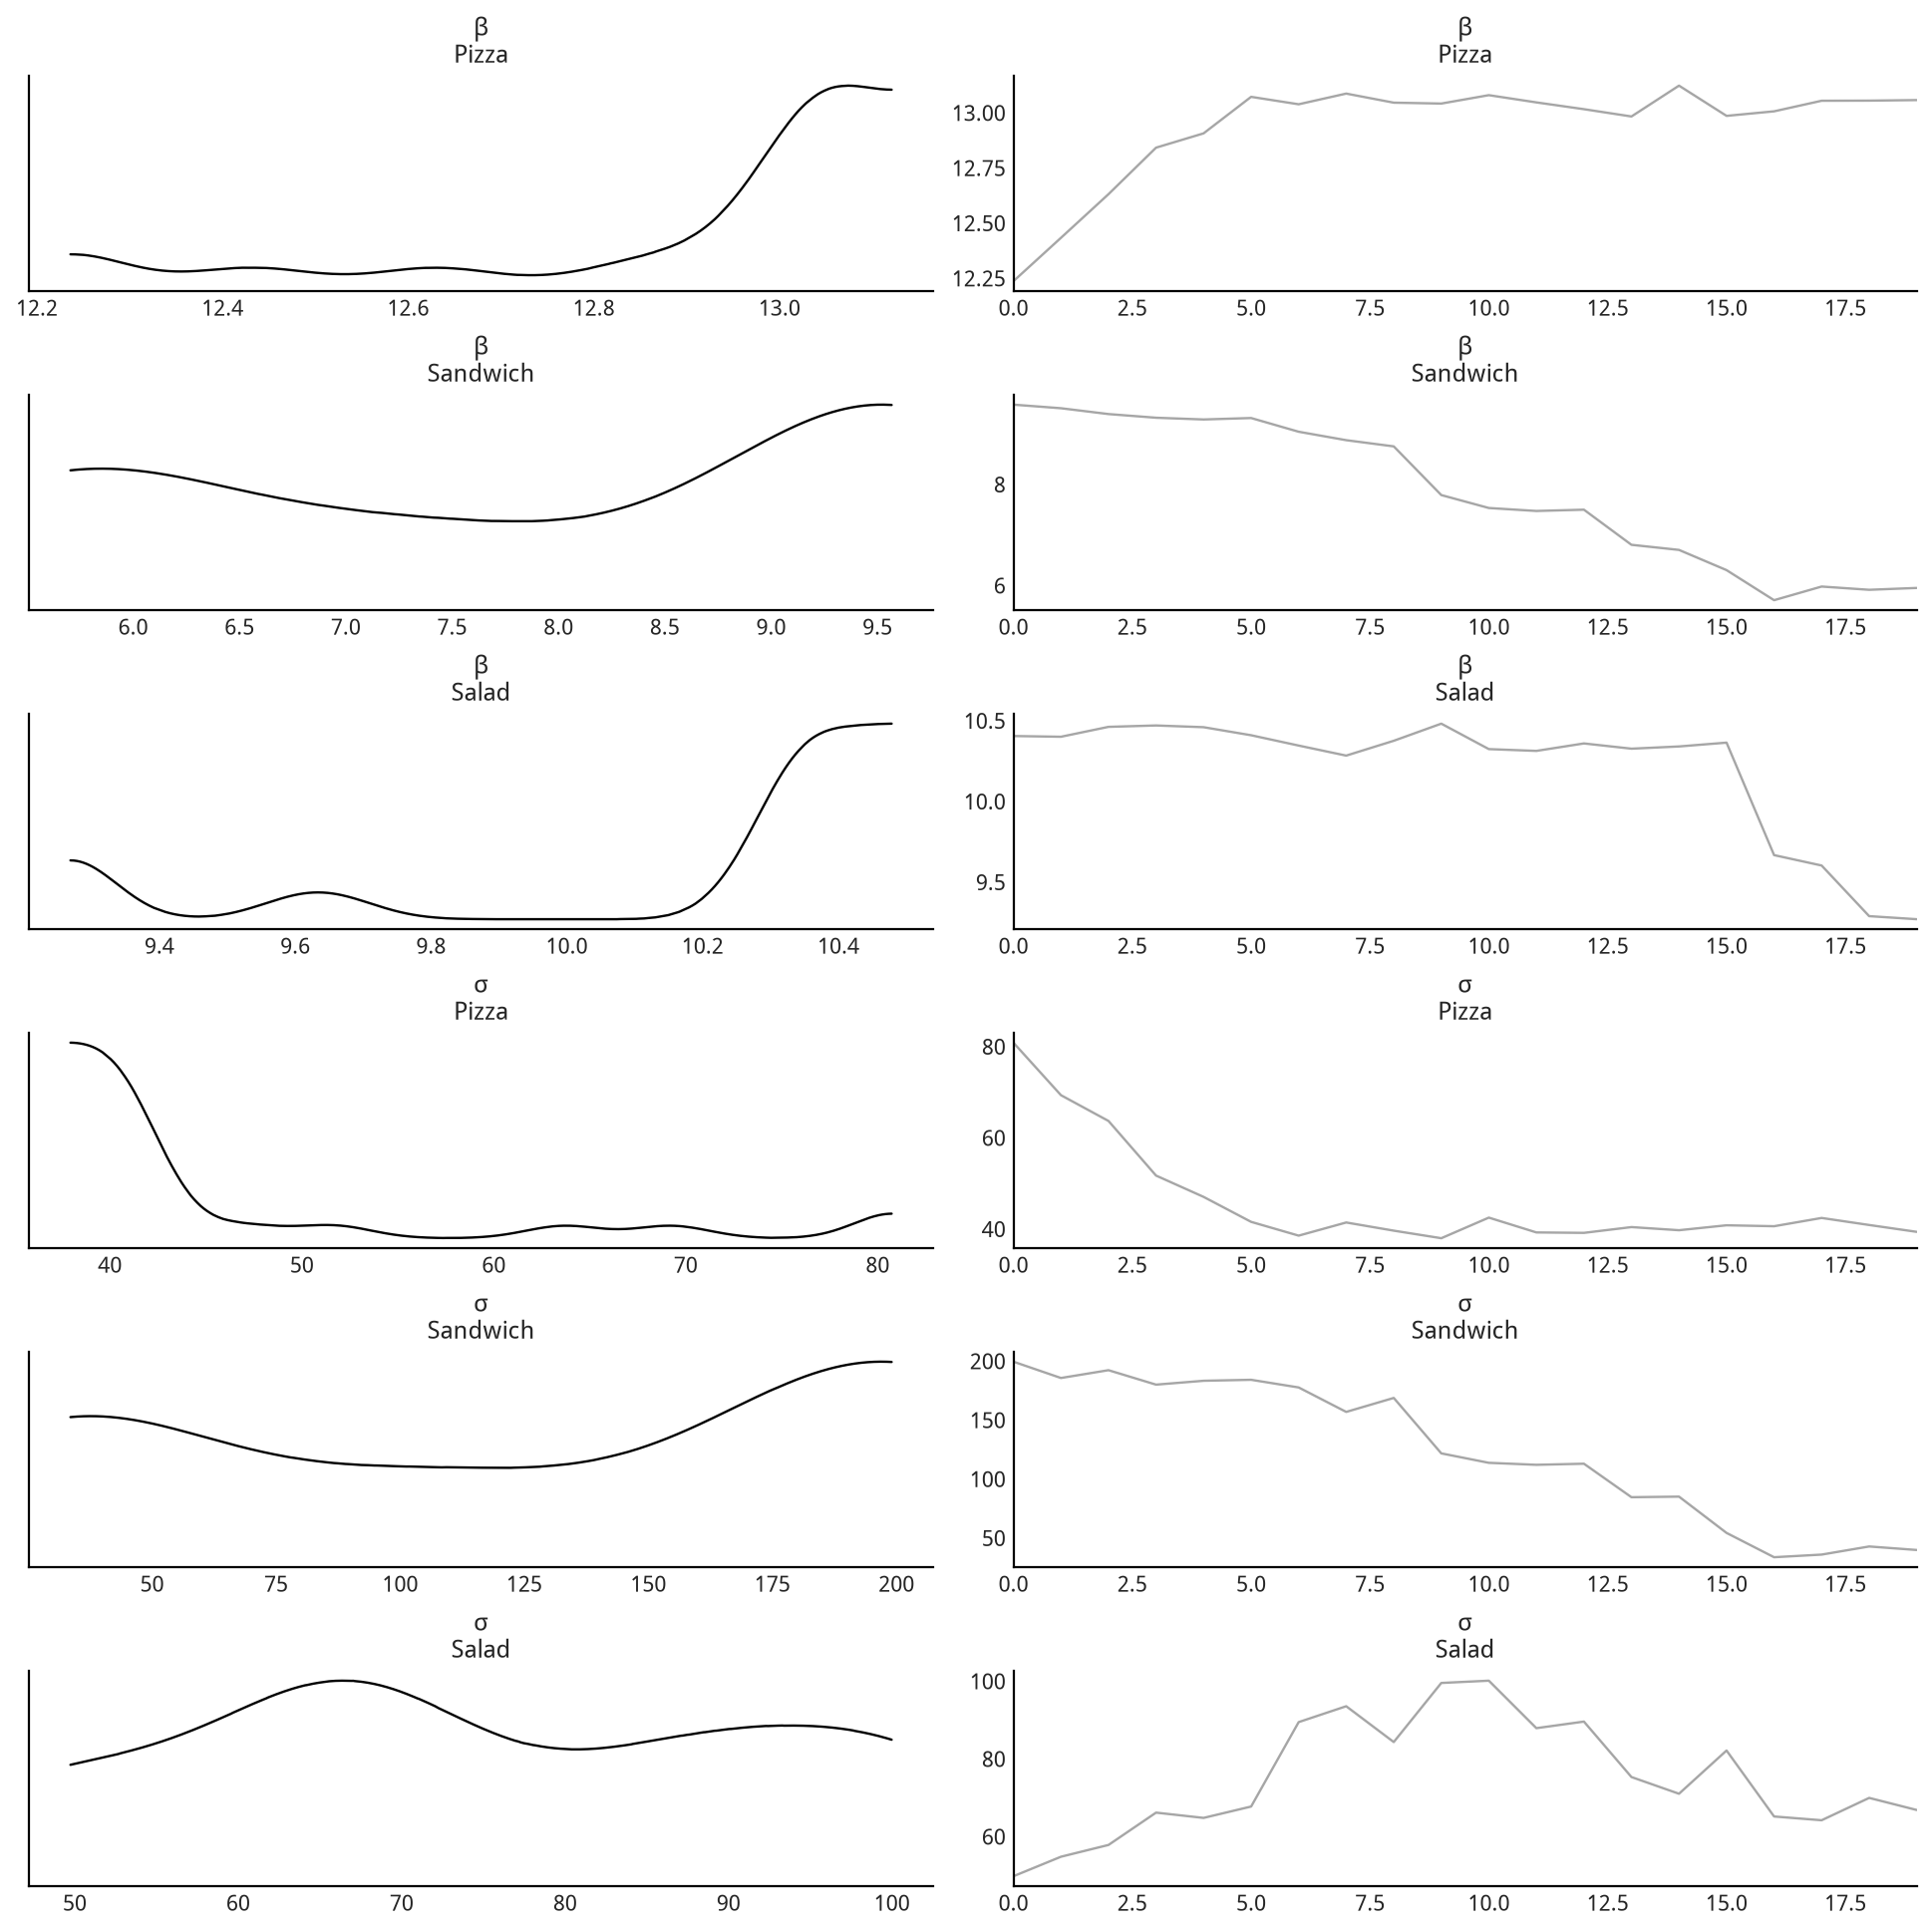

In [21]:
customers = sales_df["customers"].to_numpy(dtype=np.float64)
sales_observed = sales_df["sales"].to_numpy(dtype=np.float64)
food_category = sales_df["Food_Category"]
food_codes = food_category.cat.codes.to_numpy()
observation_index = np.arange(len(sales_df))
coords_sales = {"meal": meal_levels, "observation": observation_index}

with pm.Model(coords=coords_sales) as model_sales_unpooled:
    σ = pm.HalfNormal("σ", sigma=20.0, dims="meal")
    β = pm.Normal("β", mu=10.0, sigma=10.0, dims="meal")
    μ = pm.Deterministic("μ", β[food_codes] * customers, dims="observation")
    sales = pm.Normal("sales", mu=μ, sigma=σ[food_codes], observed=sales_observed, dims="observation")
    idata_sales_unpooled = pm.sample(**sample_kwargs(seed_offset=8))

unpooled_graph = pm.model_to_graphviz(model_sales_unpooled)
save_model_graph(unpooled_graph, "salad_sales_basic_regression_model_unpooled")
salad_code = meal_levels.index("Salad")
salad_observations = np.flatnonzero(food_codes == salad_code)[:3]
idata_salads_sales_unpooled = (
    idata_sales_unpooled.posterior.sel(meal="Salad").isel(observation=salad_observations)
)
unpooled_summary = az.summary(idata_sales_unpooled, var_names=["β", "σ"])
az.plot_trace(idata_sales_unpooled, var_names=["β", "σ"], compact=False)
unpooled_summary

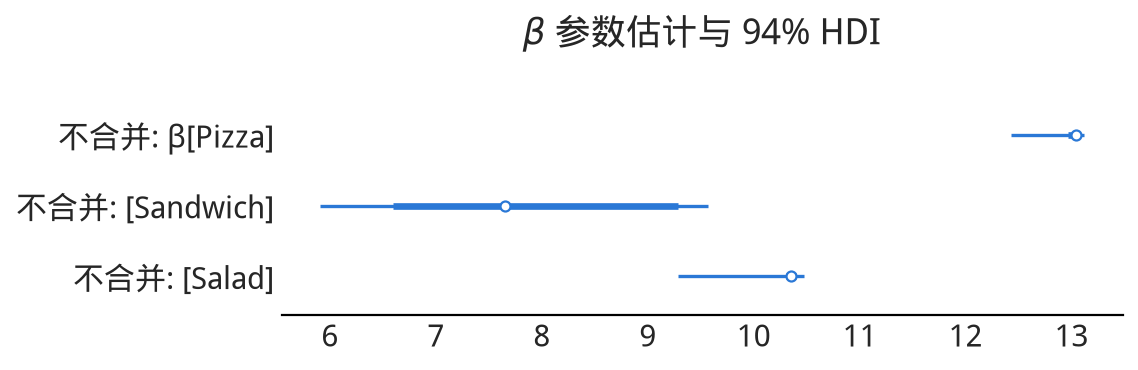

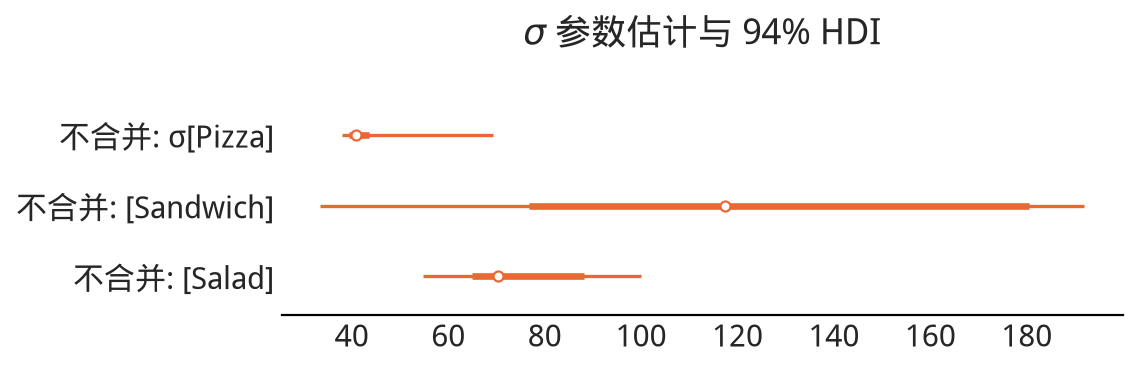

In [22]:
axes_beta = az.plot_forest(
    [idata_sales_unpooled], model_names=["不合并"], var_names=["β"],
    combined=True, figsize=(7, 2.2), colors=SERIES_COLORS[0],
)
axes_beta[0].set_title(r"$\beta$ 参数估计与 94% HDI")
plt.gcf().savefig(FIGURE_DIR / "salad_sales_basic_regression_forestplot_beta.png", bbox_inches="tight")

axes_sigma = az.plot_forest(
    [idata_sales_unpooled], model_names=["不合并"], var_names=["σ"],
    combined=True, figsize=(7, 2.2), colors=SERIES_COLORS[1],
)
axes_sigma[0].set_title(r"$\sigma$ 参数估计与 94% HDI")
plt.gcf().savefig(FIGURE_DIR / "salad_sales_basic_regression_forestplot_sigma.png", bbox_inches="tight")

(pooled-parameters)=

### 合并参数

既然有不合并参数,自然也有**合并参数(pooled parameter)**。顾名思义,这类参数忽略组之间的区分。
图 {numref}`fig:pooled_model` 给出概念结构:每个组共享同一组参数,所以这些参数也称为**共同参数
(common parameter)**。

```{figure} figures/pooled_model.png
:name: fig:pooled_model
:width: 5.00in
合并模型:每组观测 $y_1,y_2,\ldots,y_j$ 共享参数。
```

对于餐厅例子,模型写成式 {eq}`eq:pooled_regression` 和代码块
[model_sales_pooled](model_sales_pooled),结构图见
{numref}`fig:Salad_Sales_Basic_Regression_Model_Pooled`。

```{math}
:label: eq:pooled_regression
\begin{split}
\beta \sim& \overbrace{\mathcal{N}(\mu_{\beta}, \sigma_{\beta})}^{\text{共同}}\\
\sigma \sim& \overbrace{\mathcal{HN}(\sigma_{\sigma})}^{\text{共同}}\\
\mu =& \beta_{1} X_{1} + \dots + \beta_{m} X_{m} \\
Y \sim& \mathcal{N}(\mu, \sigma)
\end{split}
```

```{figure} figures/salad_sales_basic_regression_model_pooled.png
:name: fig:Salad_Sales_Basic_Regression_Model_Pooled
:width: 3.00in
`model_sales_pooled` 的结构图。与图
{numref}`fig:Salad_Sales_Basic_Regression_Model_Unpooled` 不同,这里 $\beta$ 和 $\sigma$ 都只有一个实例。
```

```{figure} figures/salad_sales_basic_regression_forestplot_sigma_comparison.png
:name: fig:Salad_Sales_Basic_Regression_ForestPlot_Sigma_Comparison
:width: 7.00in
`model_sales_pooled` 与 `model_sales_unpooled` 的 $\sigma$ 估计对比。合并模型只有一个 $\sigma$,且比
不合并估计大得多,因为单条回归线必须吸收全部合并数据的变异。
```

合并方法的好处是每个参数都由更多数据估计;代价是无法分别理解各组,只能描述全部食品类别的整体。
图 {numref}`fig:Salad_Sales_Basic_Regression_Scatter_Pooled` 中,$\beta$ 与 $\sigma$ 都不能代表任何一个
具体食品组,因为模型把尺度差异很大的数据合在一起。尽管单条线使用的数据比任一单组都多,只有两个
参数的模型仍不足以概括各组差异,所以不能很好拟合任何一组。这意味着组间差异太大,不应忽略;
对我们的预测目标而言,完全合并并不特别有用。

```{figure} figures/salad_sales_basic_regression_scatter_pooled.png
:name: fig:Salad_Sales_Basic_Regression_Scatter_Pooled
:width: 7.00in
把所有数据合在一起的 `model_sales_pooled`。每个参数都由全部数据估计,但两个参数无法充分概括各组
细节,因而对每个具体组的行为都估计不佳。
```

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [σ, β]


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 1 seconds.


The number of samples is too small to check convergence reliably.


Sampling: [sales]


arviz - WARNING - Shape validation failed: input_shape: (1, 20), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
β,11.478,0.145,11.287,11.724,0.042,0.041,11.0,26.0,NaN
σ,191.695,4.254,185.153,197.274,0.964,0.506,20.0,26.0,NaN


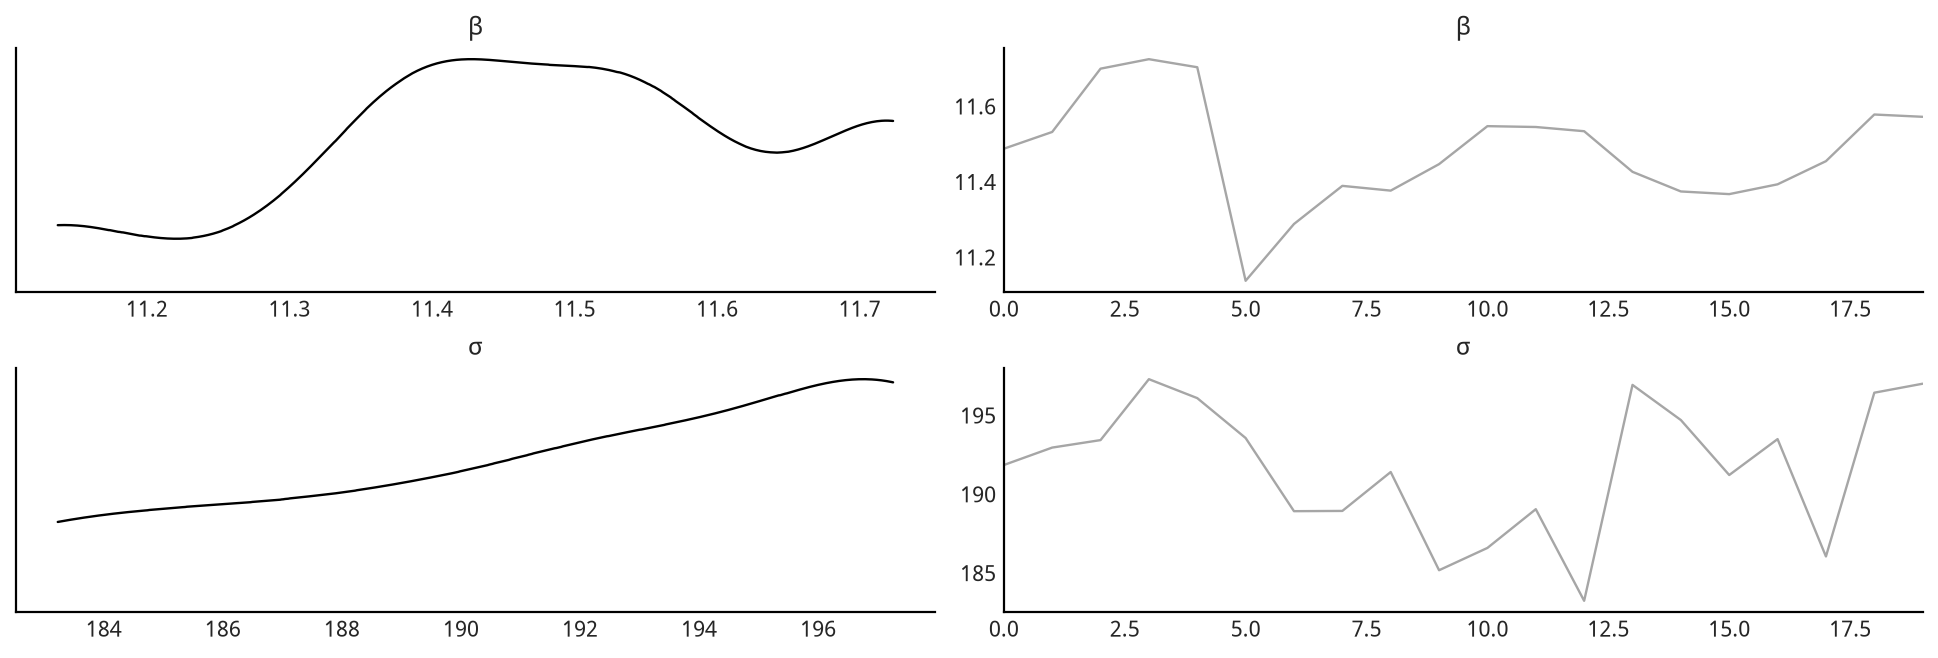

In [23]:
with pm.Model(coords=coords_sales) as model_sales_pooled:
    σ = pm.HalfNormal("σ", sigma=20.0)
    β = pm.Normal("β", mu=10.0, sigma=10.0)
    μ = pm.Deterministic("μ", β * customers, dims="observation")
    sales = pm.Normal("sales", mu=μ, sigma=σ, observed=sales_observed, dims="observation")
    idata_sales_pooled = pm.sample(**sample_kwargs(seed_offset=9))
    pm.sample_posterior_predictive(
        idata_sales_pooled,
        random_seed=SEED + 109,
        progressbar=False,
        extend_inferencedata=True,
    )

pooled_graph = pm.model_to_graphviz(model_sales_pooled)
save_model_graph(pooled_graph, "salad_sales_basic_regression_model_pooled")
az.plot_trace(idata_sales_pooled, var_names=["β", "σ"], compact=False)
pooled_summary = az.summary(idata_sales_pooled, var_names=["β", "σ"])
pooled_summary

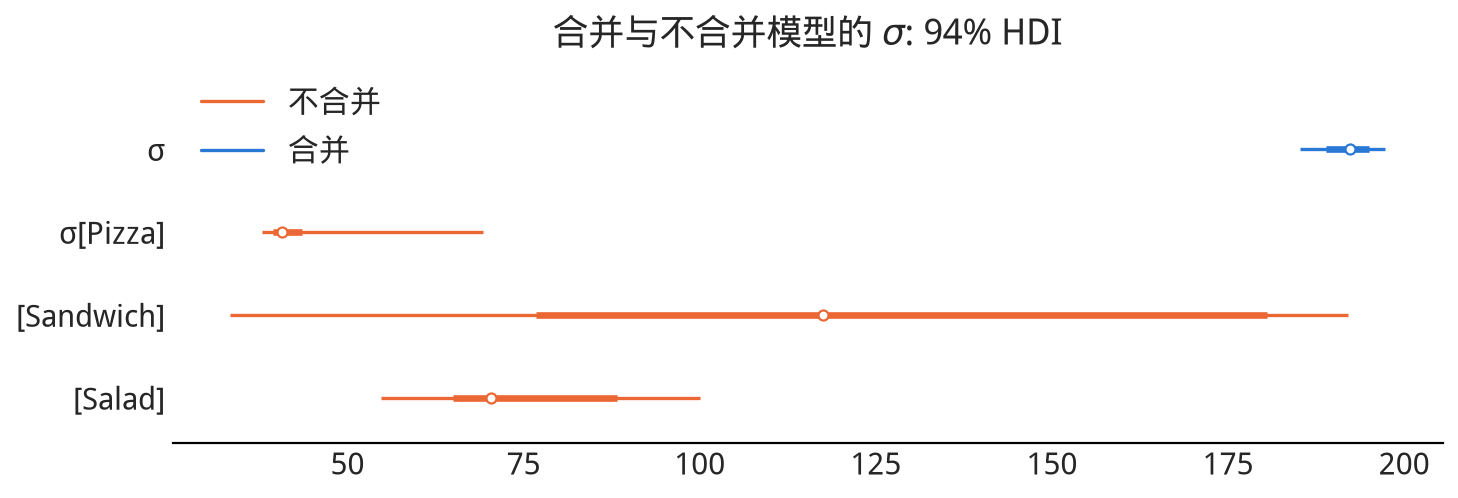

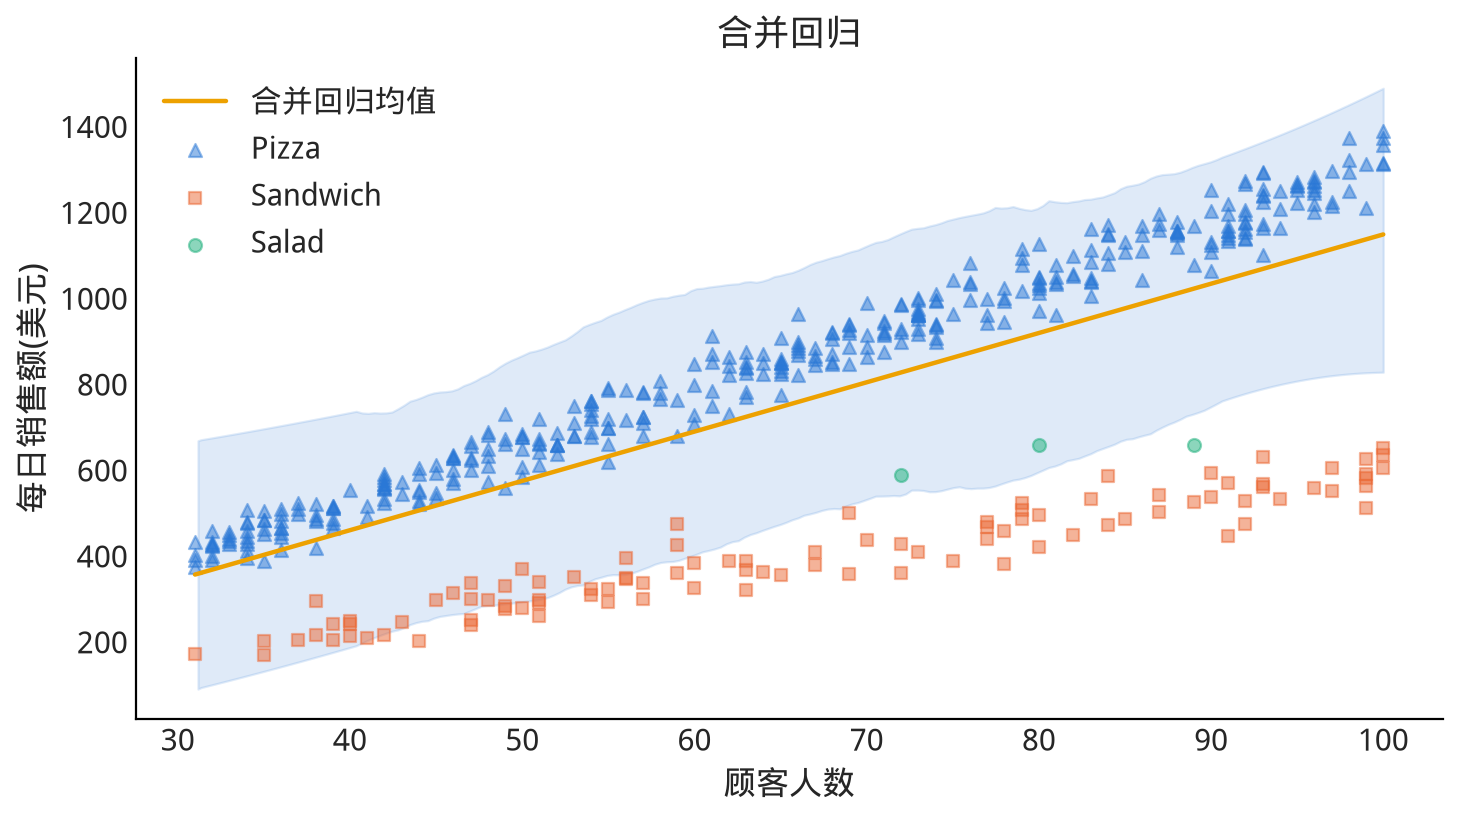

In [24]:
axes = az.plot_forest(
    [idata_sales_pooled, idata_sales_unpooled],
    model_names=["合并", "不合并"],
    var_names=["σ"], combined=True, figsize=(9, 3),
    colors=[SERIES_COLORS[0], SERIES_COLORS[1]],
)
axes[0].set_title(r"合并与不合并模型的 $\sigma$: 94% HDI")
plt.gcf().savefig(FIGURE_DIR / "salad_sales_basic_regression_forestplot_sigma_comparison.png", bbox_inches="tight")

figure, axis = plt.subplots(figsize=(9, 5))
order = np.argsort(customers)
μ_mean = idata_sales_pooled.posterior["μ"].mean(("chain", "draw")).values
axis.plot(customers[order], μ_mean[order], color=SERIES_COLORS[3], linewidth=2, label="合并回归均值")
az.plot_hdi(customers[order], idata_sales_pooled.posterior_predictive["sales"].isel(observation=order),
            hdi_prob=0.94, ax=axis, color=SERIES_COLORS[0], fill_kwargs={"alpha": 0.15})
for meal, marker, color in zip(meal_levels, ("^", "s", "o"), SERIES_COLORS[:3], strict=True):
    subset = sales_df[sales_df["Food_Category"] == meal]
    axis.scatter(subset["customers"], subset["sales"], marker=marker, s=34,
                 alpha=0.50, color=color, label=meal)
axis.set_xlabel("顾客人数")
axis.set_ylabel("每日销售额(美元)")
axis.set_title("合并回归")
axis.legend(frameon=False)
figure.savefig(FIGURE_DIR / "salad_sales_basic_regression_scatter_pooled.png", bbox_inches="tight")

(mixing-group-and-common-parameters)=

### 混合组特异参数与共同参数

不合并方法保留组间差异,为每组估计一组参数;合并方法用全部数据估计一组参数,信息更多但更泛化。
幸运的是,我们不必二选一。可以在式 {eq}`eq:multilevel_regression` 的同一模型中混合两种思想:
这里令 $\beta$ 保持组特异(不合并),而 $\sigma$ 为共同参数(合并)。若模型含截距,截距同样可以选择
合并成一个估计,或按组分别估计。

```{math}
:label: eq:multilevel_regression
\begin{split}
\beta_{mj} \sim& \overbrace{\mathcal{N}(\mu_{\beta m}, \sigma_{\beta m})}^{\text{组特异}}\\
\sigma \sim& \overbrace{\mathcal{HN}(\sigma_{\sigma})}^{\text{共同}}\\
\mu_{j} =& \beta_{1j} X_1 + \dots + \beta_{mj} X_m \\
Y \sim& \mathcal{N}(\mu_{j}, \sigma)
\end{split}
```

::: {admonition} 随机效应、固定效应,以及为什么最好忘掉这些词

各层级特有的参数和跨层级共同的参数,分别被称为随机效应(random effect)或变化效应(varying effect),
以及固定效应(fixed effect)或常量效应(constant effect)。更令人困惑的是,不同人可能赋予这些词不同
含义,尤其是“固定”和“随机” {cite:p}`gelman2005`。如果必须命名,我们建议使用“共同”和“组特异”
{cite:p}`gabry_goodrich_2020, capretto2020`。不过这些旧术语使用广泛,所以请始终核对模型的具体细节,
避免混淆和误解。
:::

回到销售模型,我们愿意合并数据估计 $\sigma$,因为披萨、三明治和沙拉的销售变异可能相同;但已知
各组斜率不同,所以 $\beta$ 保持不合并。代码块 [model_sales_mixed_effect](model_sales_mixed_effect)
给出 PyMC 模型,图 {numref}`fig:Salad_Sales_Basic_Regression_Model_Multilevel` 给出结构。图
{numref}`fig:Salad_Sales_Basic_Regression_Scatter_Sigma_Pooled_Slope_Unpooled` 把拟合叠加在数据上,
图 {numref}`fig:Salad_Sales_ForestPlot_Sigma_Unpooled_Multilevel_Comparison` 比较多层与不合并模型的
$\sigma$。结果令人鼓舞:3 个类别的拟合都合理,尤其是沙拉组,模型似乎能对新市场沙拉销售给出可信
推断。

```{figure} figures/salad_sales_basic_regression_model_multilevel.png
:name: fig:Salad_Sales_Basic_Regression_Model_Multilevel
:width: 3.00in
`model_pooled_sigma_sales` 中,$\beta$ 是不合并的(外框右下角标 3),$\sigma$ 是合并的(没有数字,表示
全部组只有一个参数估计)。
```

```{figure} figures/salad_sales_basic_regression_scatter_sigma_pooled_slope_unpooled.png
:name: fig:Salad_Sales_Basic_Regression_Scatter_Sigma_Pooled_Slope_Unpooled
:width: 7.00in
`model_pooled_sigma_sales` 的线性模型与 50% HDI。斜率按组独立估计,所以该模型更适合估计沙拉销量;
全部数据共同估计一个 $\sigma$ 后验分布。
```

```{figure} figures/salad_sales_forestplot_sigma_unpooled_multilevel_comparison.png
:name: fig:Salad_Sales_ForestPlot_Sigma_Unpooled_Multilevel_Comparison
:width: 7.00in
比较 `model_pooled_sigma_sales` 与不合并模型中的 $\sigma$。多层模型的共同 $\sigma$ 估计位于不合并
模型各组 $\sigma$ 的范围内。
```

In [25]:
with pm.Model(coords=coords_sales) as model_pooled_sigma_sales:
    σ = pm.HalfNormal("σ", sigma=20.0)
    β = pm.Normal("β", mu=10.0, sigma=20.0, dims="meal")
    μ = pm.Deterministic("μ", β[food_codes] * customers, dims="observation")
    sales = pm.Normal("sales", mu=μ, sigma=σ, observed=sales_observed, dims="observation")
    idata_pooled_sigma_sales = pm.sample(**sample_kwargs(seed_offset=10))
    pm.sample_posterior_predictive(
        idata_pooled_sigma_sales,
        random_seed=SEED + 110,
        progressbar=False,
        extend_inferencedata=True,
    )

mixed_graph = pm.model_to_graphviz(model_pooled_sigma_sales)
save_model_graph(mixed_graph, "salad_sales_basic_regression_model_multilevel")
mixed_summary = az.summary(idata_pooled_sigma_sales, var_names=["β", "σ"])
mixed_summary

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [σ, β]


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 1 seconds.


The number of samples is too small to check convergence reliably.


Sampling: [sales]


arviz - WARNING - Shape validation failed: input_shape: (1, 20), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
β[Pizza],13.078,0.048,13.016,13.153,0.013,0.006,15.0,20.0,NaN
β[Sandwich],6.372,0.557,5.818,7.277,0.365,0.123,3.0,20.0,NaN
β[Salad],9.710,0.319,9.310,10.057,0.233,0.026,2.0,20.0,NaN
σ,48.488,9.838,38.701,65.696,6.120,2.443,3.0,20.0,NaN


Text(0.5, 1.0, '两种模型的 $\\beta$: 94% HDI')

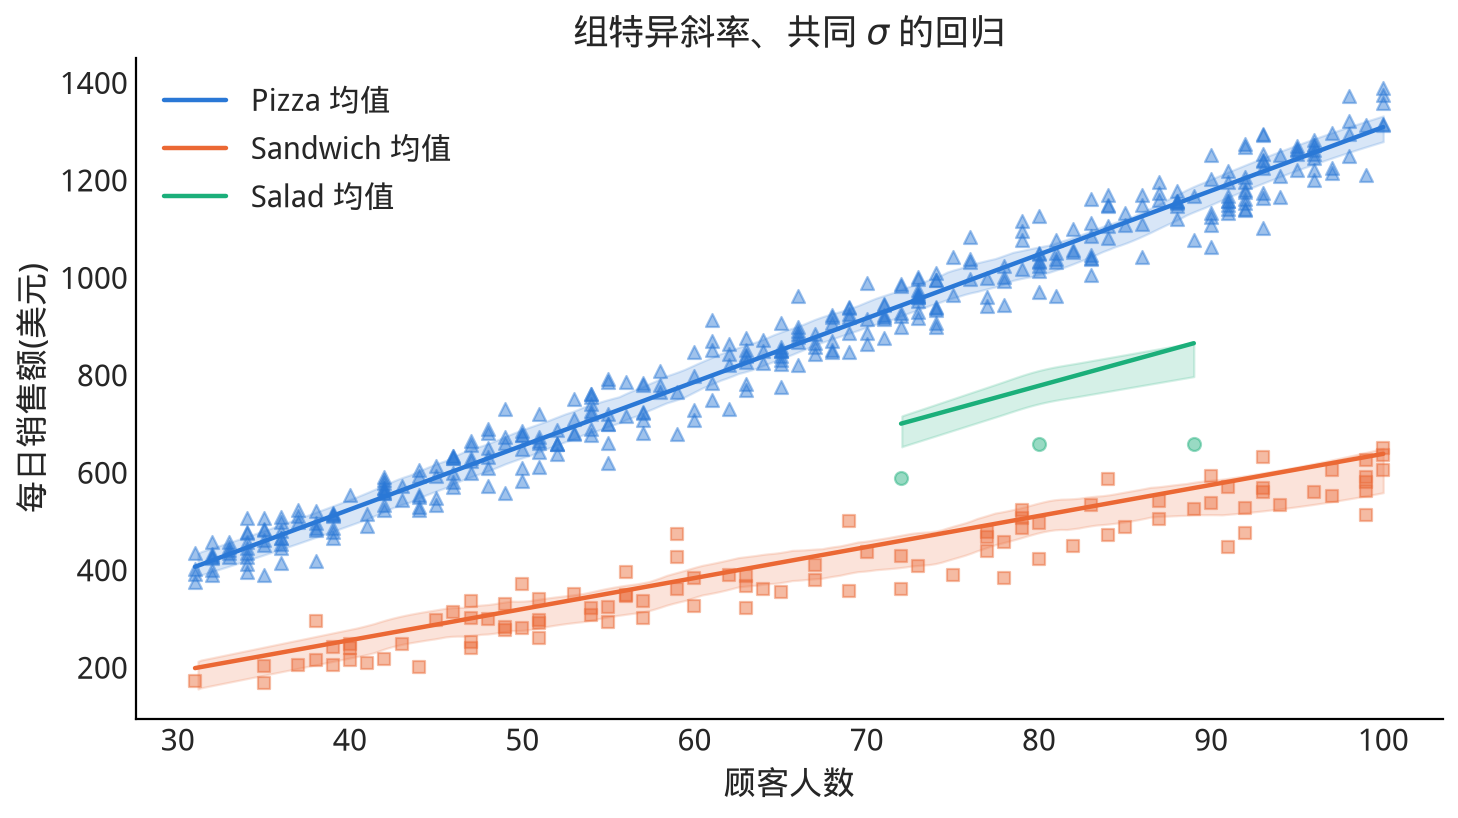

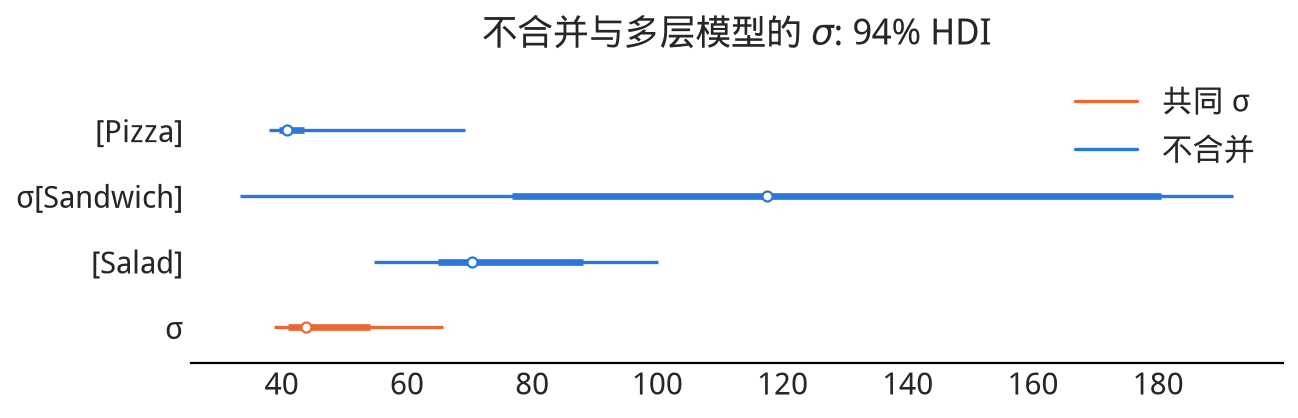

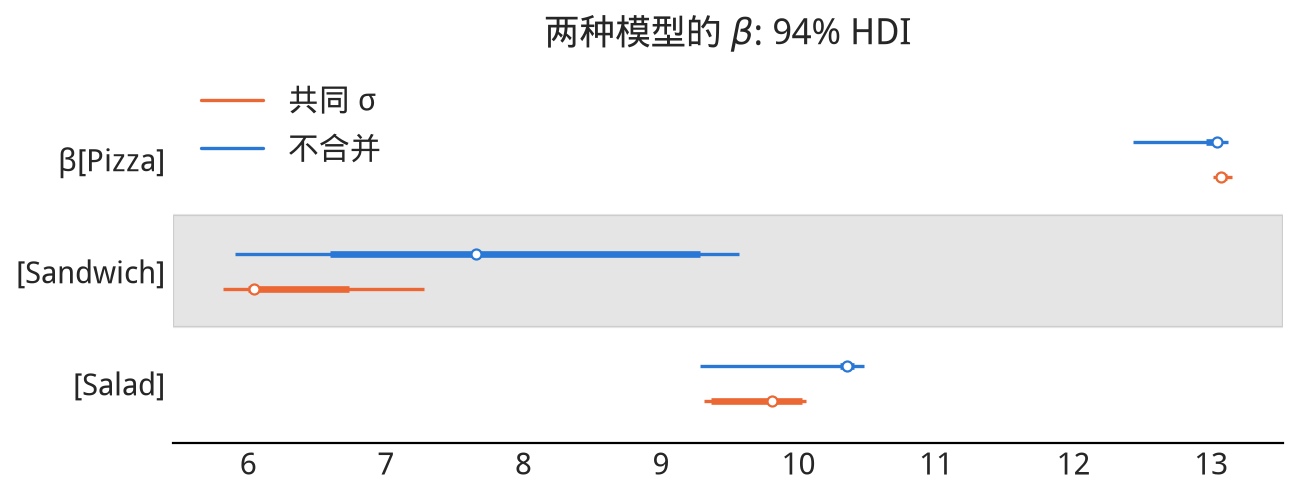

In [26]:
figure, axis = plt.subplots(figsize=(9, 5))
for meal, marker, color in zip(meal_levels, ("^", "s", "o"), SERIES_COLORS[:3], strict=True):
    mask = (food_codes == meal_levels.index(meal))
    x_meal = customers[mask]
    order = np.argsort(x_meal)
    μ_meal = idata_pooled_sigma_sales.posterior["μ"].isel(observation=np.flatnonzero(mask))
    ppc_meal = idata_pooled_sigma_sales.posterior_predictive["sales"].isel(observation=np.flatnonzero(mask))
    axis.plot(x_meal[order], μ_meal.mean(("chain", "draw")).values[order],
              color=color, linewidth=2, label=f"{meal} 均值")
    az.plot_hdi(x_meal[order], ppc_meal.isel(observation=order), hdi_prob=0.50,
                ax=axis, color=color, fill_kwargs={"alpha": 0.18})
    axis.scatter(x_meal, sales_observed[mask], marker=marker, s=34, alpha=0.45, color=color)
axis.set_xlabel("顾客人数")
axis.set_ylabel("每日销售额(美元)")
axis.set_title(r"组特异斜率、共同 $\sigma$ 的回归")
axis.legend(frameon=False)
figure.savefig(FIGURE_DIR / "salad_sales_basic_regression_scatter_sigma_pooled_slope_unpooled.png", bbox_inches="tight")

axes_sigma = az.plot_forest(
    [idata_sales_unpooled, idata_pooled_sigma_sales],
    model_names=["不合并", "共同 σ"], var_names=["σ"], combined=True,
    figsize=(8, 2.5), colors=[SERIES_COLORS[0], SERIES_COLORS[1]],
)
axes_sigma[0].set_title(r"不合并与多层模型的 $\sigma$: 94% HDI")
plt.gcf().savefig(FIGURE_DIR / "salad_sales_forestplot_sigma_unpooled_multilevel_comparison.png", bbox_inches="tight")

axes_beta = az.plot_forest(
    [idata_sales_unpooled, idata_pooled_sigma_sales],
    model_names=["不合并", "共同 σ"], var_names=["β"], combined=True,
    figsize=(8, 3.0), colors=[SERIES_COLORS[0], SERIES_COLORS[1]],
)
axes_beta[0].set_title(r"两种模型的 $\beta$: 94% HDI")

(hierarchical-models)=

## 层级模型

到目前为止,处理分组数据有两个极端选择:合并时完全不区分组,不合并时各组完全独立。但在餐厅例子
中,我们认为 3 种食品的 $\sigma$ 相似却不完全相同。贝叶斯建模可以用**层级模型(hierarchical
model)** 表达这种想法。在层级模型中,参数会被**部分合并(partial pooling)**:各组不共享一个固定
参数,而是共享一个**超先验分布(hyperprior distribution)**,它描述组参数自身先验的分布。图
{numref}`fig:partial_pooled_model` 展示这一概念:每组有自己的参数,但这些参数来自共同超先验。

```{figure} figures/partial_pooled_model.png
:name: fig:partial_pooled_model
:width: 5.00in
部分合并模型结构:每组观测 $y_1,y_2,\ldots,y_k$ 有自己的参数,但这些参数并非相互独立,而是来自
一个共同分布。
```

统计记号见式 {eq}`eq:hierarchical_regression`,计算模型见代码块
[model_hierarchical_sales](model_hierarchical_sales),图结构见
{numref}`fig:Salad_Sales_Hierarchial_Regression_Model`。

```{math}
:label: eq:hierarchical_regression
\begin{split}
\beta_{mj} \sim& \mathcal{N}(\mu_{\beta m}, \sigma_{\beta m}) \\
\sigma_{h} \sim& \overbrace{\mathcal{HN}(\sigma)}^{\text{超先验}} \\
\sigma_{j} \sim& \overbrace{\mathcal{HN}(\sigma_{h})}^{\substack{\text{组特异} \\ \text{部分合并}}} \\
\mu_{j} =& \beta_{1j} X_1 + \dots + \beta_{mj} X_m \\
Y \sim& \mathcal{N}(\mu_{j},\sigma_{j})
\end{split}
```

与图 {numref}`fig:Salad_Sales_Basic_Regression_Model_Multilevel` 相比,这里新增了 $\sigma_h$,它是定义
各组参数可能取值的新超先验。你也许会问:“能否也给 $\beta$ 加超先验?”答案当然可以。但本例假设
只有方差彼此相关,所以方差部分合并,斜率仍完全独立。因为这是模拟的教科书例子,我们可以直接声明
这个假设;现实分析则应借助更多领域知识和模型比较来论证。

```{figure} figures/salad_sales_hierarchial_regression_model.png
:name: fig:Salad_Sales_Hierarchial_Regression_Model
:width: 3.00in
`model_hierarchical_sales` 中,$\sigma_{hyperprior}$ 是 3 个 $\sigma$ 分布共同的单个层级分布。
```

```{figure} figures/salad_sales_forestplot_sigma_hierarchical.png
:name: fig:Salad_Sales_ForestPlot_Sigma_Hierarchical
:width: 7.00in
`model_hierarchical_sales` 中 $\sigma$ 的森林图。超先验的估计通常落在 3 个组参数的范围内。
```

拟合后可以查看图 {numref}`fig:Salad_Sales_ForestPlot_Sigma_Hierarchical` 中的 $\sigma$。新增的
$\sigma_{hyperprior}$ 是一个分布,用于估计 3 类食品参数的总体分布。表 {numref}`tab:unpooled_sales`
和 {numref}`tab:Hierarchical_sales` 保留原书发布运行的不合并与层级模型快照;当前确定性生成器的发布
结果应以 `unpooled_sigma_table` 和 `hierarchical_sigma_table` 为准。原书快照中,不合并模型里沙拉
$\sigma$ 的均值是 21.3;层级估计变成 25.5,被披萨和三明治组的均值向上“拉”了一些。披萨与三明治
组也略向总体均值收缩,但由于数据更多,估计大体不变。每个 $\sigma$ 仍彼此明显不同,这与观测数据和
部分合并模型的预期一致。

```{list-table} 原书发布运行中不合并销售模型各类别的 $\sigma$ 估计快照。
:name: tab:unpooled_sales
* -
  - **mean**
  - **sd**
  - **hdi_3%**
  - **hdi_97%**
* - $\sigma_{Pizza}$
  - 40.1
  - 1.5
  - 37.4
  - 42.8
* - $\sigma_{Salad}$
  - 21.3
  - 8.3
  - 8.8
  - 36.8
* - $\sigma_{Sandwich}$
  - 35.9
  - 2.5
  - 31.6
  - 40.8
```

```{list-table} 原书发布运行中层级销售模型各类别的 $\sigma$ 及超先验估计快照。
:name: tab:Hierarchical_sales
* -
  - **mean**
  - **sd**
  - **hdi_3%**
  - **hdi_97%**
* - $\sigma_{Pizza}$
  - 40.3
  - 1.5
  - 37.5
  - 43.0
* - $\sigma_{Salad}$
  - 25.5
  - 12.4
  - 8.4
  - 48.7
* - $\sigma_{Sandwich}$
  - 36.2
  - 2.6
  - 31.4
  - 41.0
* - $\sigma_{hyperprior}$
  - 31.2
  - 8.7
  - 15.8
  - 46.9
```

::: {admonition} 听说你喜欢超先验,所以我又在超先验上放了超先验

在代码块 [model_hierarchical_sales](model_hierarchical_sales) 中,我们把超先验放在组层参数
$\sigma_j$ 上。类似地,也可以为 $\beta_{mj}$ 增加超先验。由于 $\beta_{mj}$ 的先验是高斯分布,
甚至可以为它的两个超参数各选一个超先验。自然会有人继续问:能否再给超先验的参数放超超先验,
甚至超超超先验?数学上当然可以写出并抽样这类模型,但应先退一步理解超先验的作用。

直观地说,超先验让模型从数据较多的子组或子簇“借用”信息,帮助估计观测较少的组。数据多的组会
影响超参数后验,而超参数后验又会调节数据少的组参数。从这个角度看,给并非组特异的参数添加超先验
通常没有意义。
:::

层级估计不限于两个层级。例如,餐厅销售模型可以扩展为三层:最上层表示公司,中间层表示地理市场
(纽约、芝加哥、洛杉矶),最下层表示具体门店。这样既有刻画全公司的超先验,也有刻画地区的超先验,
还有描述每家门店的先验。一个模型就能方便地比较多个层级的均值与变异,从而扩展应用范围。

In [27]:
with pm.Model(coords=coords_sales) as model_hierarchical_sales:
    σ_hyperprior = pm.HalfNormal("σ_hyperprior", sigma=20.0)
    σ = pm.HalfNormal("σ", sigma=σ_hyperprior, dims="meal")
    β = pm.Normal("β", mu=10.0, sigma=20.0, dims="meal")
    μ = pm.Deterministic("μ", β[food_codes] * customers, dims="observation")
    sales = pm.Normal("sales", mu=μ, sigma=σ[food_codes], observed=sales_observed, dims="observation")
    idata_hierarchical_sales = pm.sample(**sample_kwargs(seed_offset=11, target_accept=0.92))

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [σ_hyperprior, σ, β]


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 1 seconds.


The number of samples is too small to check convergence reliably.


<Axes: >

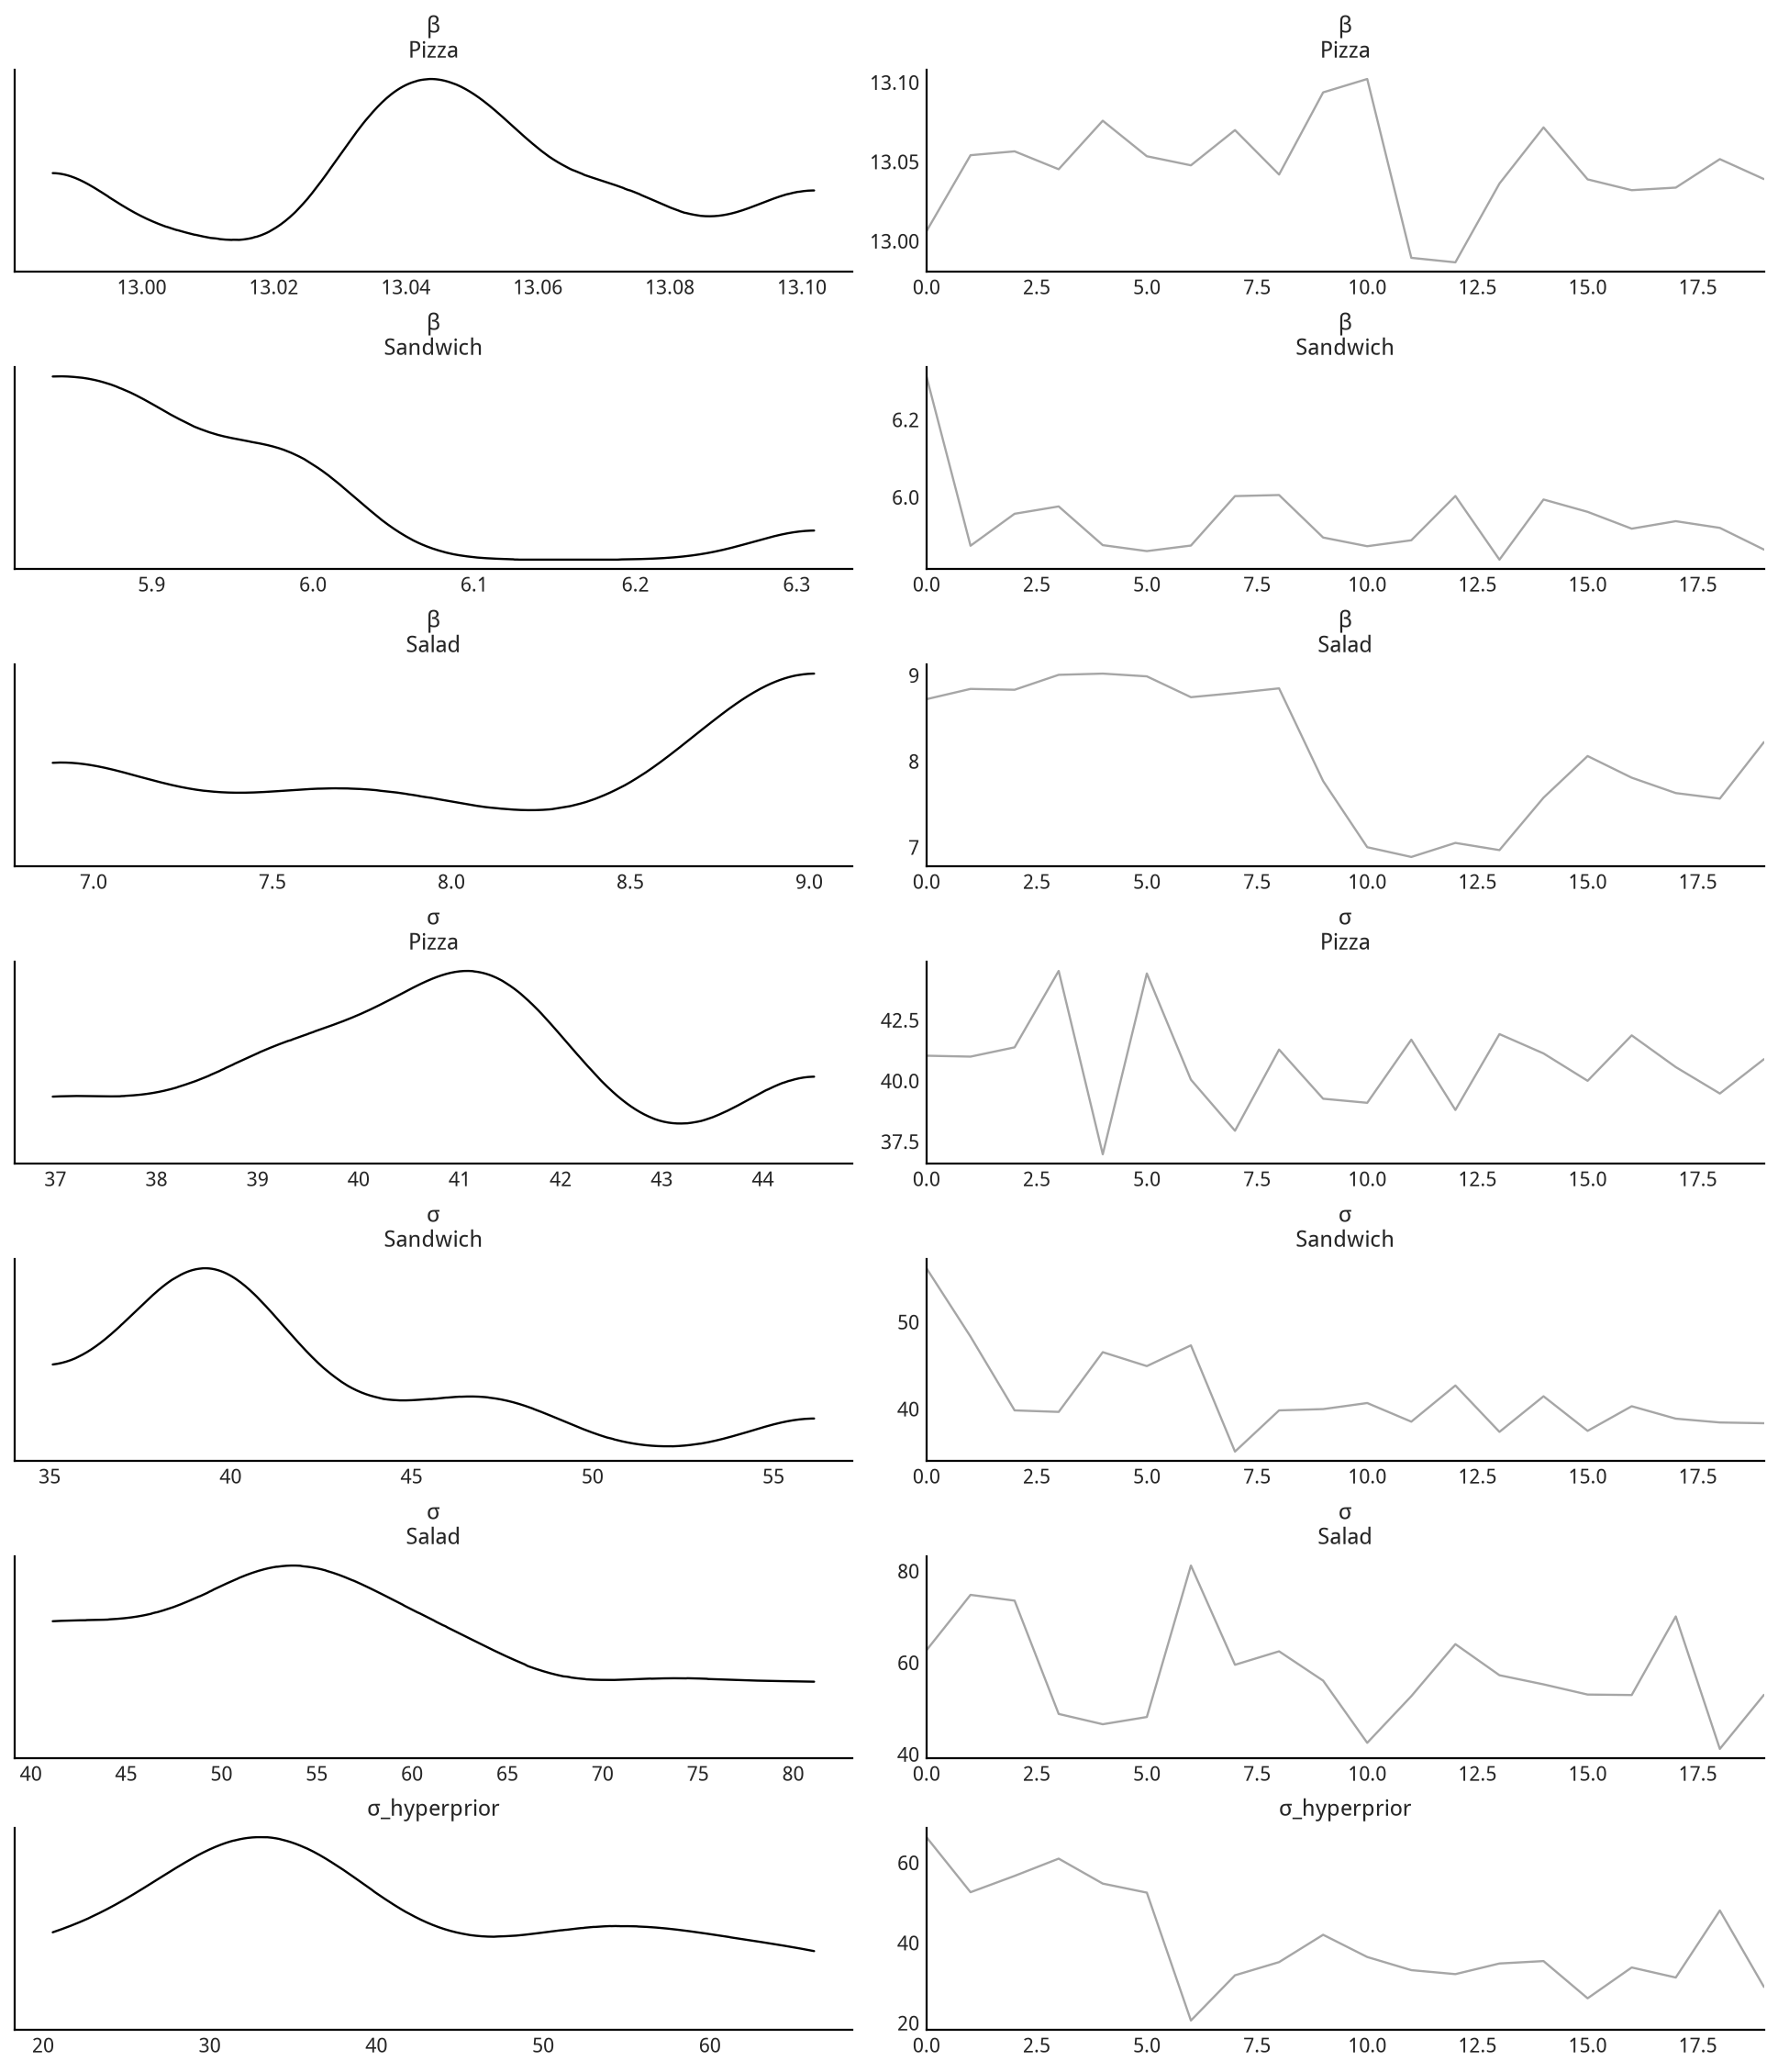

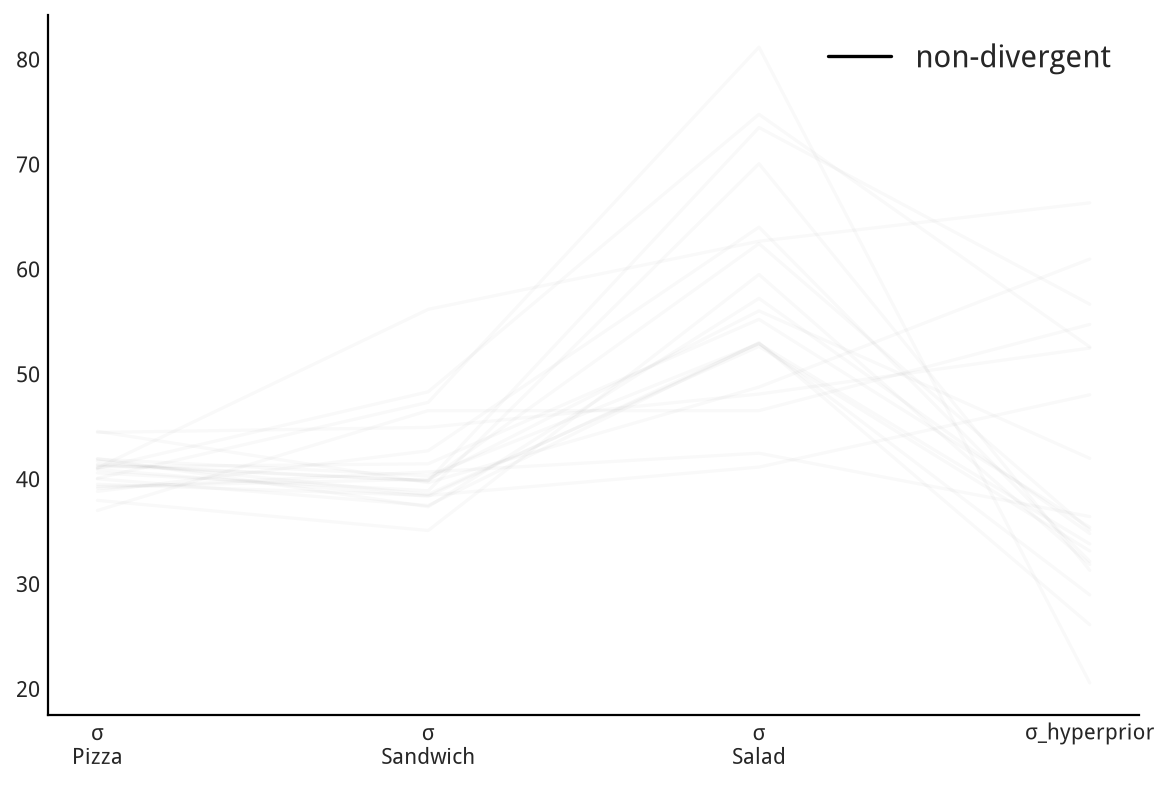

In [28]:
az.plot_trace(idata_hierarchical_sales, compact=False, var_names=["β", "σ", "σ_hyperprior"])
az.plot_parallel(idata_hierarchical_sales, var_names=["σ", "σ_hyperprior"])

In [29]:
hierarchical_graph = pm.model_to_graphviz(model_hierarchical_sales)
save_model_graph(hierarchical_graph, "salad_sales_hierarchial_regression_model")
hierarchical_summary = az.summary(
    idata_hierarchical_sales, var_names=["β", "σ", "σ_hyperprior"]
)
hierarchical_summary

arviz - WARNING - Shape validation failed: input_shape: (1, 20), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
β[Pizza],13.046,0.030,12.986,13.094,0.006,0.006,19.0,20.0,NaN
β[Sandwich],5.941,0.103,5.838,6.005,0.020,0.033,26.0,20.0,NaN
β[Salad],8.113,0.776,6.964,9.016,0.548,0.098,2.0,26.0,NaN
σ[Pizza],40.655,1.859,37.935,44.514,0.364,0.473,26.0,26.0,NaN
σ[Sandwich],41.558,4.901,35.063,48.282,1.921,1.385,10.0,20.0,NaN
σ[Salad],57.722,10.860,41.106,74.737,2.638,1.310,16.0,26.0,NaN
σ_hyperprior,40.638,12.708,26.078,66.297,6.538,3.078,5.0,20.0,NaN


['Pizza', 'Sandwich', 'Salad']

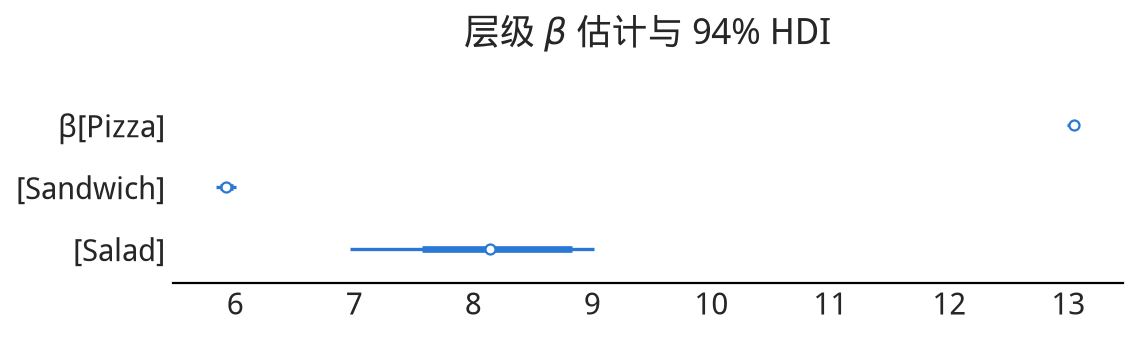

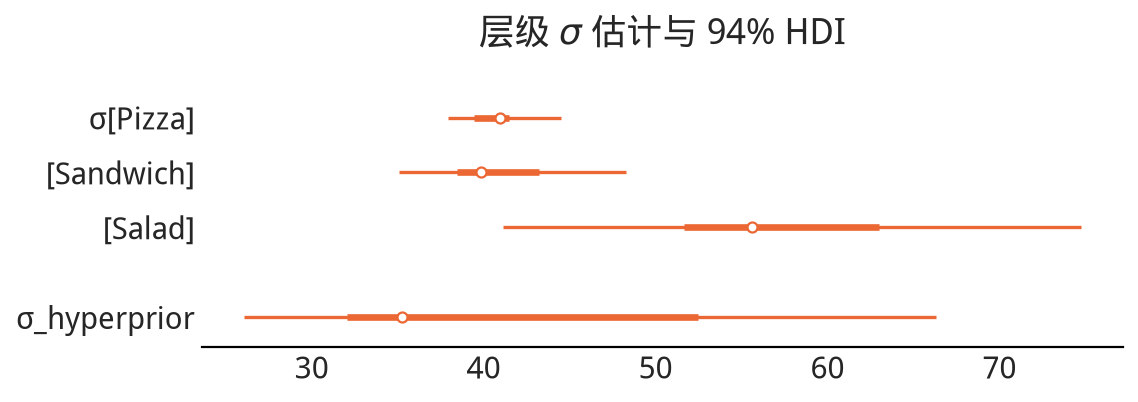

In [30]:
axes_beta = az.plot_forest(
    idata_hierarchical_sales, var_names=["β"], combined=True,
    figsize=(7, 2.0), colors=SERIES_COLORS[0],
)
axes_beta[0].set_title(r"层级 $\beta$ 估计与 94% HDI")

axes_sigma = az.plot_forest(
    idata_hierarchical_sales, var_names=["σ", "σ_hyperprior"], combined=True,
    figsize=(7, 2.4), colors=SERIES_COLORS[1],
)
axes_sigma[0].set_title(r"层级 $\sigma$ 估计与 94% HDI")
plt.gcf().savefig(FIGURE_DIR / "salad_sales_forestplot_sigma_hierarchical.png", bbox_inches="tight")
meal_levels

(              mean    sd  hdi_3%  hdi_97%
 σ[Pizza]      45.8  11.7    37.9     69.3
 σ[Sandwich]  122.9  59.9    33.4    192.0
 σ[Salad]      74.9  14.9    54.7    100.0,
               mean    sd  hdi_3%  hdi_97%
 σ[Pizza]      40.7   1.9    37.9     44.5
 σ[Sandwich]   41.6   4.9    35.1     48.3
 σ[Salad]      57.7  10.9    41.1     74.7
 σ_hyperprior  40.6  12.7    26.1     66.3)

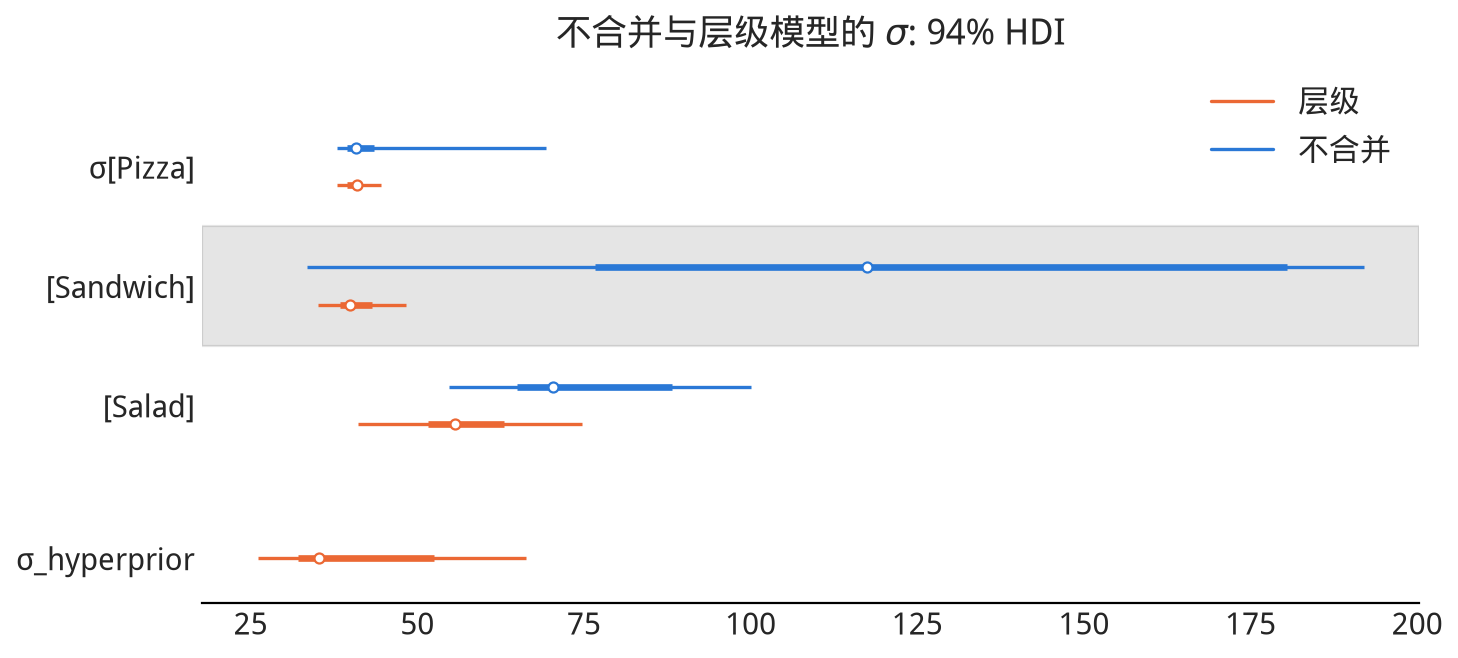

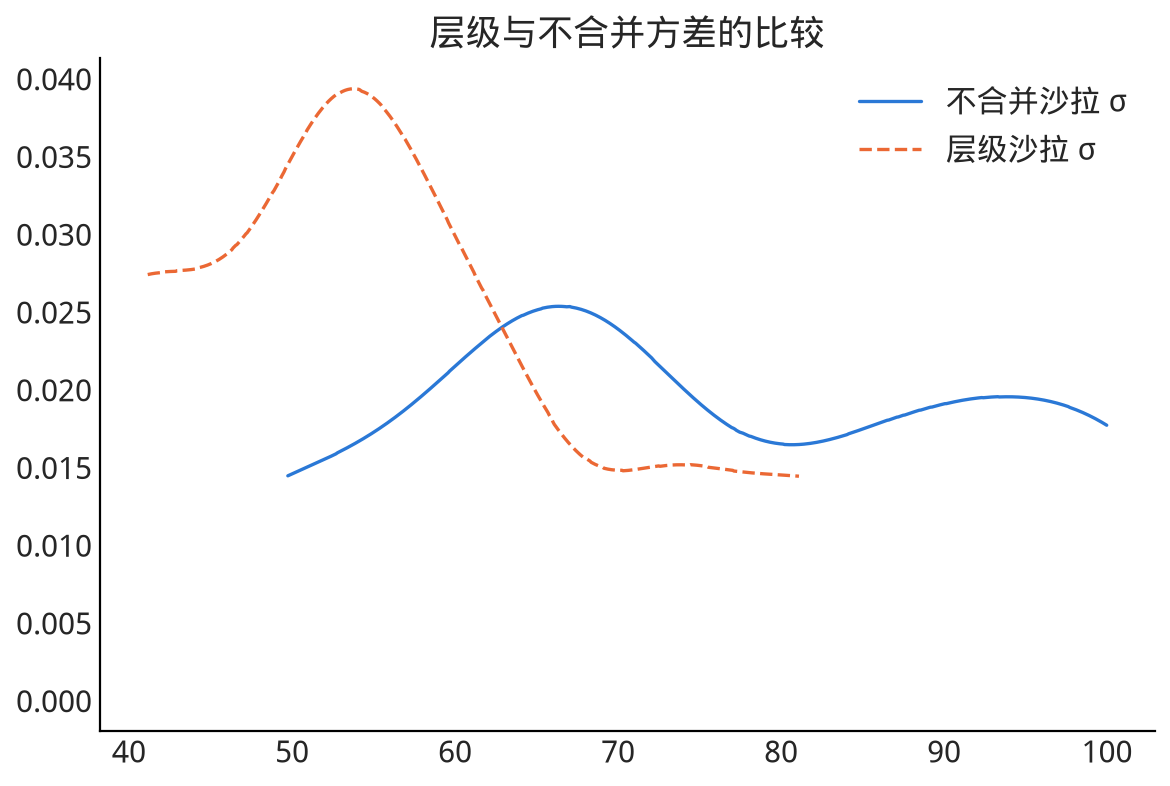

In [31]:
unpooled_sigma_table = az.summary(idata_sales_unpooled, var_names=["σ"], kind="stats").round(1)
hierarchical_sigma_table = az.summary(
    idata_hierarchical_sales, var_names=["σ", "σ_hyperprior"], kind="stats"
).round(1)

axes_compare = az.plot_forest(
    [idata_sales_unpooled, idata_hierarchical_sales],
    model_names=["不合并", "层级"],
    var_names=["σ", "σ_hyperprior"], combined=True,
    figsize=(9, 4), colors=[SERIES_COLORS[0], SERIES_COLORS[1]],
)
axes_compare[0].set_title(r"不合并与层级模型的 $\sigma$: 94% HDI")
plt.gcf().savefig(FIGURE_DIR / "salad_sales_sigma_unpooled_hierarchical_comparison.png", bbox_inches="tight")

figure, axis = plt.subplots()
az.plot_kde(
    idata_sales_unpooled.posterior["σ"].sel(meal="Salad").values,
    label="不合并沙拉 σ", plot_kwargs={"color": SERIES_COLORS[0], "linestyle": "-"}, ax=axis,
)
az.plot_kde(
    idata_hierarchical_sales.posterior["σ"].sel(meal="Salad").values,
    label="层级沙拉 σ", plot_kwargs={"color": SERIES_COLORS[1], "linestyle": "--"}, ax=axis,
)
axis.set_title("层级与不合并方差的比较")
axis.legend(frameon=False)
(unpooled_sigma_table, hierarchical_sigma_table)

(model_geometry)=

### 后验几何很重要

前面主要关注模型结构和数学形式,并假设采样器能够“准确”估计后验。对相对简单的模型,最新一代
通用推断引擎通常确实“开箱即用”,但并非总是如此。某些后验几何(posterior geometry)会让采样器
很难工作。常见例子是图 {numref}`fig:Neals_Funnel` 中的 Neal 漏斗 {cite:p}`neal_2003`。顾名思义,
它的一端很宽,随后收窄成细颈。回想 {ref}`sampling_methods_intro` 节,采样器从一组参数值迈向下一组,
关键设置之一是探索后验表面时每一步有多大。在 Neal 漏斗这类复杂几何中,某一区域合适的步长,在
另一区域可能彻底失效。

```{figure} figures/neals_funnel.png
:name: fig:Neals_Funnel
:width: 7.00in
一种被称为 Neal 漏斗的相关样本形状。在漏斗上部 $Y\approx6$ 到 $8$ 时,采样器可以迈出例如 1 个
单位的较大步长,仍很可能留在高密度区域;在漏斗底部 $Y\approx-6$ 到 $-8$ 时,向几乎任何方向迈出
1 个单位都可能落入低密度区域。后验几何的这种剧烈变化会导致基于采样的后验估计不佳。对 HMC
采样器,发散(divergence)可以帮助诊断这类问题。
```

层级模型的几何主要由超先验与其他参数的相关性决定,因此容易形成难以抽样的漏斗结构。这不只是
理论问题,它会很快出现在毫无戒心的贝叶斯建模者面前。幸运的是,有一种相对简单的模型调整,称为
**非中心化参数化(non-centered parameterization)**,常能缓解这一问题。

继续沙拉例子。假设我们开了 6 家沙拉店,仍想按顾客人数预测销售额。Python 生成的合成数据见图
{numref}`fig:Multiple_Salad_Sales_Scatter`;一些门店的数据点远少于其他门店。由于各店销售完全相同
的产品,适合用层级模型共享组间信息。式 {eq}`eq:centered_hierarchical_regression` 和代码块
[model_hierarchical_salad_sales](model_hierarchical_salad_sales) 写出中心化模型。后续使用 TFP 的
`tfd.JointDistributionCoroutine`,因为它能更清楚地显示参数化变化。标准层级结构用超先验对斜率
$\beta_m$ 做部分合并。

```{math}
:label: eq:centered_hierarchical_regression
\begin{split}
\beta_{\mu h} \sim& \mathcal{N} \\
\beta_{\sigma h} \sim& \mathcal{HN} \\
\beta_m \sim& \overbrace{\mathcal{N}(\beta_{\mu h},\beta_{\sigma h})}^{\text{中心化}} \\
\sigma_{h} \sim& \mathcal{HN} \\
\sigma_{m} \sim& \mathcal{HN}(\sigma_{h}) \\
Y \sim& \mathcal{N}(\beta_{m} X_m,\sigma_{m})
\end{split}
```

```{figure} figures/multiple_salad_sales_scatter.png
:name: fig:Multiple_Salad_Sales_Scatter
:width: 7.00in
6 家门店的沙拉销售观测。注意某些门店的数据点远少于其他门店。
```

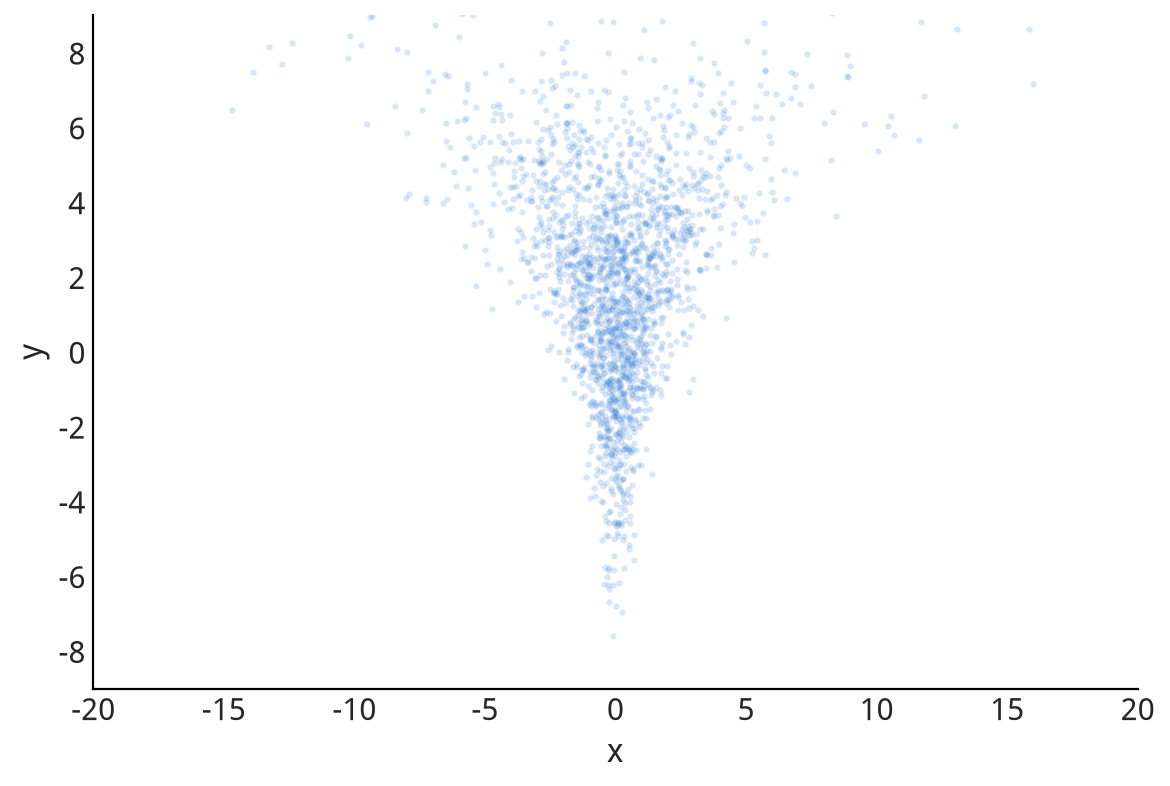

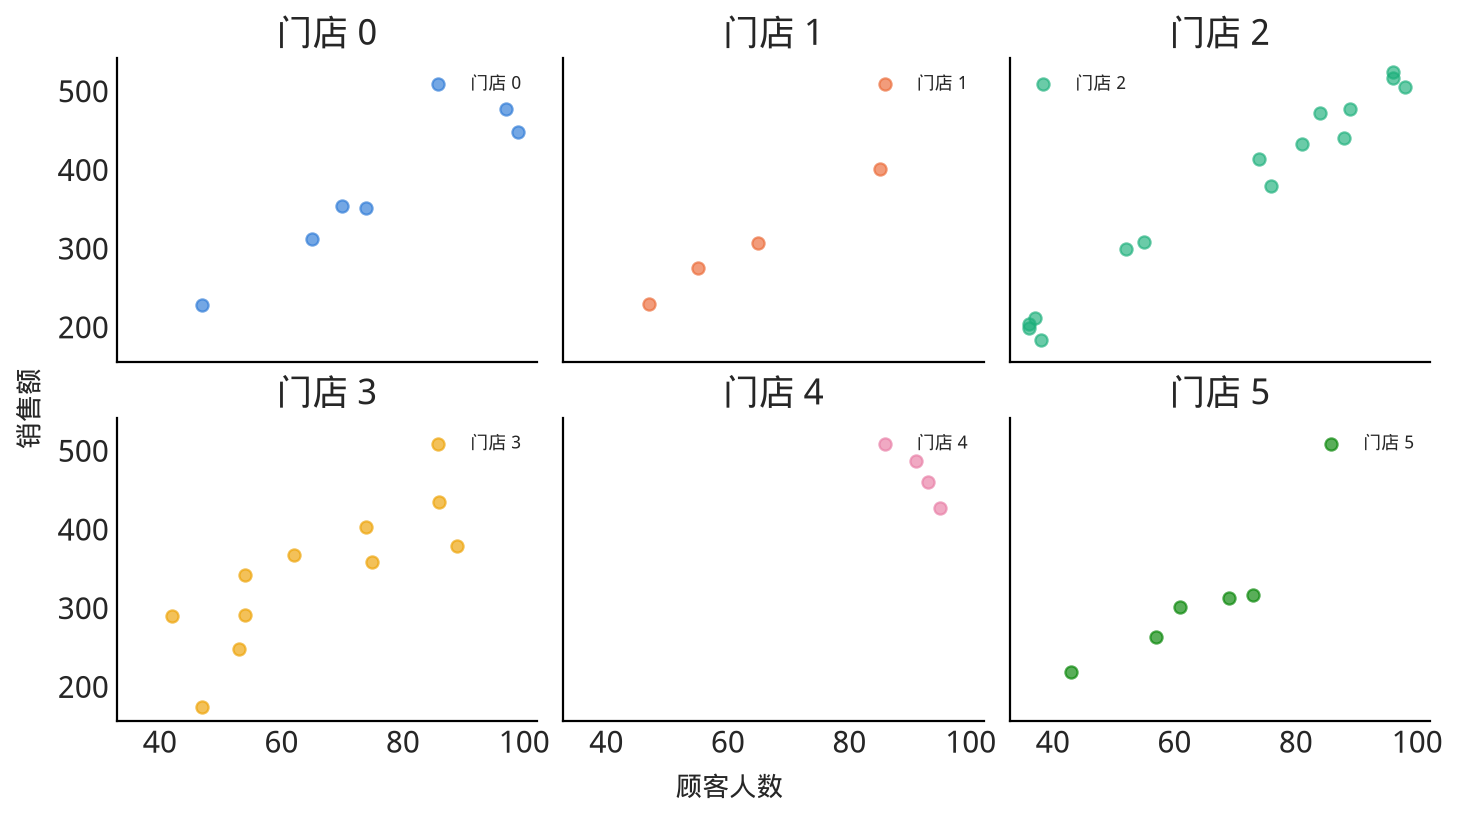

In [32]:
geometry_rng = np.random.default_rng(SEED + 40)
funnel_draws = 10_000 if PROFILE_NAME == "release" else 2_000
funnel_y = geometry_rng.normal(loc=2.0, scale=3.0, size=funnel_draws)
funnel_x = geometry_rng.normal(loc=0.0, scale=np.exp(funnel_y / 4.0), size=funnel_draws)
figure, axis = plt.subplots()
axis.scatter(funnel_x, funnel_y, marker=".", s=16, alpha=0.12, color=SERIES_COLORS[0])
axis.set_xlim(-20, 20)
axis.set_ylim(-9, 9)
axis.set_xlabel("x")
axis.set_ylabel("y")
figure.savefig(FIGURE_DIR / "neals_funnel.png", bbox_inches="tight")


def salad_generator(
    *,
    hyperprior_beta_mean=5.0,
    hyperprior_beta_sigma=0.2,
    days_per_location=(6, 4, 15, 10, 3, 5),
    sigma_per_location=(50.0, 10.0, 20.0, 80.0, 30.0, 20.0),
    seed=SEED + 41,
):
    """生成门店层级不同、但共享斜率总体分布的沙拉销售数据。"""
    if len(days_per_location) != len(sigma_per_location):
        raise ValueError("days_per_location 与 sigma_per_location 长度必须相同")
    local_rng = np.random.default_rng(seed)
    rows = []
    for location, (days, noise_scale) in enumerate(zip(days_per_location, sigma_per_location, strict=True)):
        customers_local = local_rng.integers(30, 100, size=days)
        beta_local = local_rng.normal(hyperprior_beta_mean, hyperprior_beta_sigma)
        sales_local = beta_local * customers_local + local_rng.normal(0.0, noise_scale, size=days)
        rows.append(pd.DataFrame({"customers": customers_local, "sales": sales_local, "location": location}))
    return pd.concat(rows, ignore_index=True).sort_values(["location", "customers"]).reset_index(drop=True)

hierarchical_salad_df = salad_generator()
location_levels = np.sort(hierarchical_salad_df["location"].unique())
figure, axes = plt.subplots(2, 3, figsize=(9, 5), sharex=True, sharey=True)
for location, axis, color in zip(location_levels, axes.ravel(), SERIES_COLORS[:6], strict=True):
    subset = hierarchical_salad_df[hierarchical_salad_df["location"] == location]
    axis.scatter(subset["customers"], subset["sales"], marker="o", s=30, alpha=0.65,
                 color=color, label=f"门店 {location}")
    axis.set_title(f"门店 {location}")
    axis.legend(frameon=False, fontsize=8)
figure.supxlabel("顾客人数")
figure.supylabel("销售额")
figure.savefig(FIGURE_DIR / "multiple_salad_sales_scatter.png", bbox_inches="tight")

> **中文版现代化说明**:TFP 0.25 仍把窗口自适应 NUTS 暴露为公开的
> `tfp.experimental.mcmc.windowed_adaptive_nuts`;本章只使用这一公开入口,绝不导入
> `tensorflow_probability.python.internal`。旧笔记本的 `jit_compile=True` 会把 XLA 变成硬依赖,
> 且可能削弱普通随机种子的可复现性,所以这里禁用强制 JIT并显式传入种子。模型生成器还修正了旧
> notebook 忽略 `input_df`、硬编码 6 组和匿名 `var0` 条件化的问题。

In [33]:
import tensorflow as tf
import tensorflow_probability as tfp

tfd = tfp.distributions
Root = tfd.JointDistributionCoroutine.Root


def run_tfp_nuts(joint_dist, *, draws, adaptation_steps, chains, seed, **pins):
    """只通过公开 TFP API 运行窗口自适应 NUTS。"""
    return tfp.experimental.mcmc.windowed_adaptive_nuts(
        draws,
        joint_dist,
        n_chains=chains,
        num_adaptation_steps=adaptation_steps,
        seed=seed,
        **pins,
    )


def gen_hierarchical_salad_sales(input_df, beta_prior_fn, dtype=tf.float32):
    customers_tf = tf.convert_to_tensor(input_df["customers"].to_numpy(), dtype=dtype)
    location_category = pd.Categorical(input_df["location"])
    location_codes = location_category.codes.astype(np.int32, copy=False)
    if np.any(location_codes < 0):
        raise ValueError("location 列不能包含缺失值")
    observed_sales = tf.convert_to_tensor(input_df["sales"].to_numpy(), dtype=dtype)
    n_locations = len(location_category.categories)

    @tfd.JointDistributionCoroutine
    def model_hierarchical_salad_sales():
        beta_mu = yield Root(tfd.Normal(tf.cast(0.0, dtype), tf.cast(10.0, dtype), name="beta_mu"))
        beta_sigma = yield Root(tfd.HalfNormal(tf.cast(0.1, dtype), name="beta_sigma"))
        beta = yield from beta_prior_fn(beta_mu, beta_sigma, n_locations, dtype)
        sigma_prior = yield Root(tfd.HalfNormal(tf.cast(30.0, dtype), name="sigma_prior"))
        sigma = yield tfd.Sample(tfd.HalfNormal(sigma_prior), n_locations, name="sigma")
        location_mean = tf.gather(beta, location_codes, axis=-1) * customers_tf
        location_scale = tf.gather(sigma, location_codes, axis=-1)
        yield tfd.Independent(
            tfd.Normal(location_mean, location_scale),
            reinterpreted_batch_ndims=1,
            name="sales",
        )

    return model_hierarchical_salad_sales, observed_sales, n_locations

I0000 00:00:1787328030.232617 1035386 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787328030.325953 1035386 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787328033.464697 1035386 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


与[第 3 章](chap2)的 TFP 模型一样,`gen_hierarchical_salad_sales` 包在函数中,便于对任意输入做条件
化。除了数据,它还接收可调用对象 `beta_prior_fn`,用于定义斜率 $\beta_m$ 的先验。协程模型内部用
`yield from` 调用这个生成器。文字描述可能较抽象,代码块
[model_hierarchical_salad_sales_centered](model_hierarchical_salad_sales_centered) 展示得更直接:
中心化参数化让 $\beta_m$ 服从由 `hyper_mu` 和 `hyper_sigma` 参数化的正态分布。
`centered_beta_prior_fn` 会生成一个 `tfp.distributions.Distribution`,其写法与
`tfd.JointDistributionCoroutine` 模型类似。

有了模型后,代码块
[model_hierarchical_salad_sales_centered_inference](model_hierarchical_salad_sales_centered_inference)
运行推断并检查结果。

> **中文版补充**:以下发散数是原书一次历史运行记录,不是本章当前确定性配置重新生成的结果:

```none
每条链在调参后分别有 [37 31 17 37] 次发散。
```

这里复用 {ref}`tfp_posterior_inference` 的推断思路。第一个问题信号是发散,其含义见
{ref}`divergences`。图 {numref}`fig:Neals_Funnel_Salad_Centered` 展示样本空间:随着超先验
$\beta_{\sigma h}$ 接近 0,$\beta_m$ 后验的宽度趋于收缩,而接近 0 的区域几乎没有样本。换句话说,
当 $\beta_{\sigma h}$ 靠近 0 时,$\beta_m$ 的可采样区域坍缩,采样器无法有效刻画该后验空间。

```{figure} figures/neals_funnel_salad_centered.png
:name: fig:Neals_Funnel_Salad_Centered
:width: 7.00in
代码块 [model_hierarchical_salad_sales_centered](model_hierarchical_salad_sales_centered) 中中心化模型的
超先验与门店 4 斜率 $\beta[4]$ 的散点图。超先验接近 0 时,斜率后验空间坍缩,蓝色标记处出现发散。
```

In [34]:
def centered_beta_prior_fn(hyper_mu, hyper_sigma, n_locations, dtype):
    del dtype
    beta = yield tfd.Sample(tfd.Normal(hyper_mu, hyper_sigma), n_locations, name="beta")
    return beta

centered_model, observed_tfp, n_locations = gen_hierarchical_salad_sales(
    hierarchical_salad_df, centered_beta_prior_fn
)
mcmc_samples_centered, sampler_stats_centered = run_tfp_nuts(
    centered_model,
    draws=PROFILE["tfp_draws"],
    adaptation_steps=PROFILE["tfp_adapt"],
    chains=PROFILE["tfp_chains"],
    seed=SEED + 50,
    sales=observed_tfp,
)
centered_divergences_per_chain = np.asarray(sampler_stats_centered["diverging"]).sum(axis=0)
print(f"每条链在调参后分别有 {centered_divergences_per_chain} 次发散。")

E0000 00:00:1787328034.770872 1035386 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


每条链在调参后分别有 [20] 次发散。


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],0.314,0.0,0.314,0.314,0.0,NaN,20.0,20.0,NaN
beta[1],0.318,0.0,0.318,0.318,0.0,NaN,20.0,20.0,NaN
beta[2],-0.476,0.0,-0.476,-0.476,0.0,NaN,20.0,20.0,NaN
beta[3],-0.345,0.0,-0.345,-0.345,0.0,NaN,20.0,20.0,NaN
beta[4],-1.875,0.0,-1.875,-1.875,0.0,0.0,20.0,20.0,NaN
beta[5],1.609,0.0,1.609,1.609,0.0,0.0,20.0,20.0,NaN
beta_mu,0.896,0.0,0.896,0.896,0.0,NaN,20.0,20.0,NaN
beta_sigma,0.229,0.0,0.229,0.229,0.0,NaN,20.0,20.0,NaN
sigma[0],0.552,0.0,0.552,0.552,0.0,0.0,20.0,20.0,NaN
sigma[1],0.763,0.0,0.763,0.763,0.0,NaN,20.0,20.0,NaN


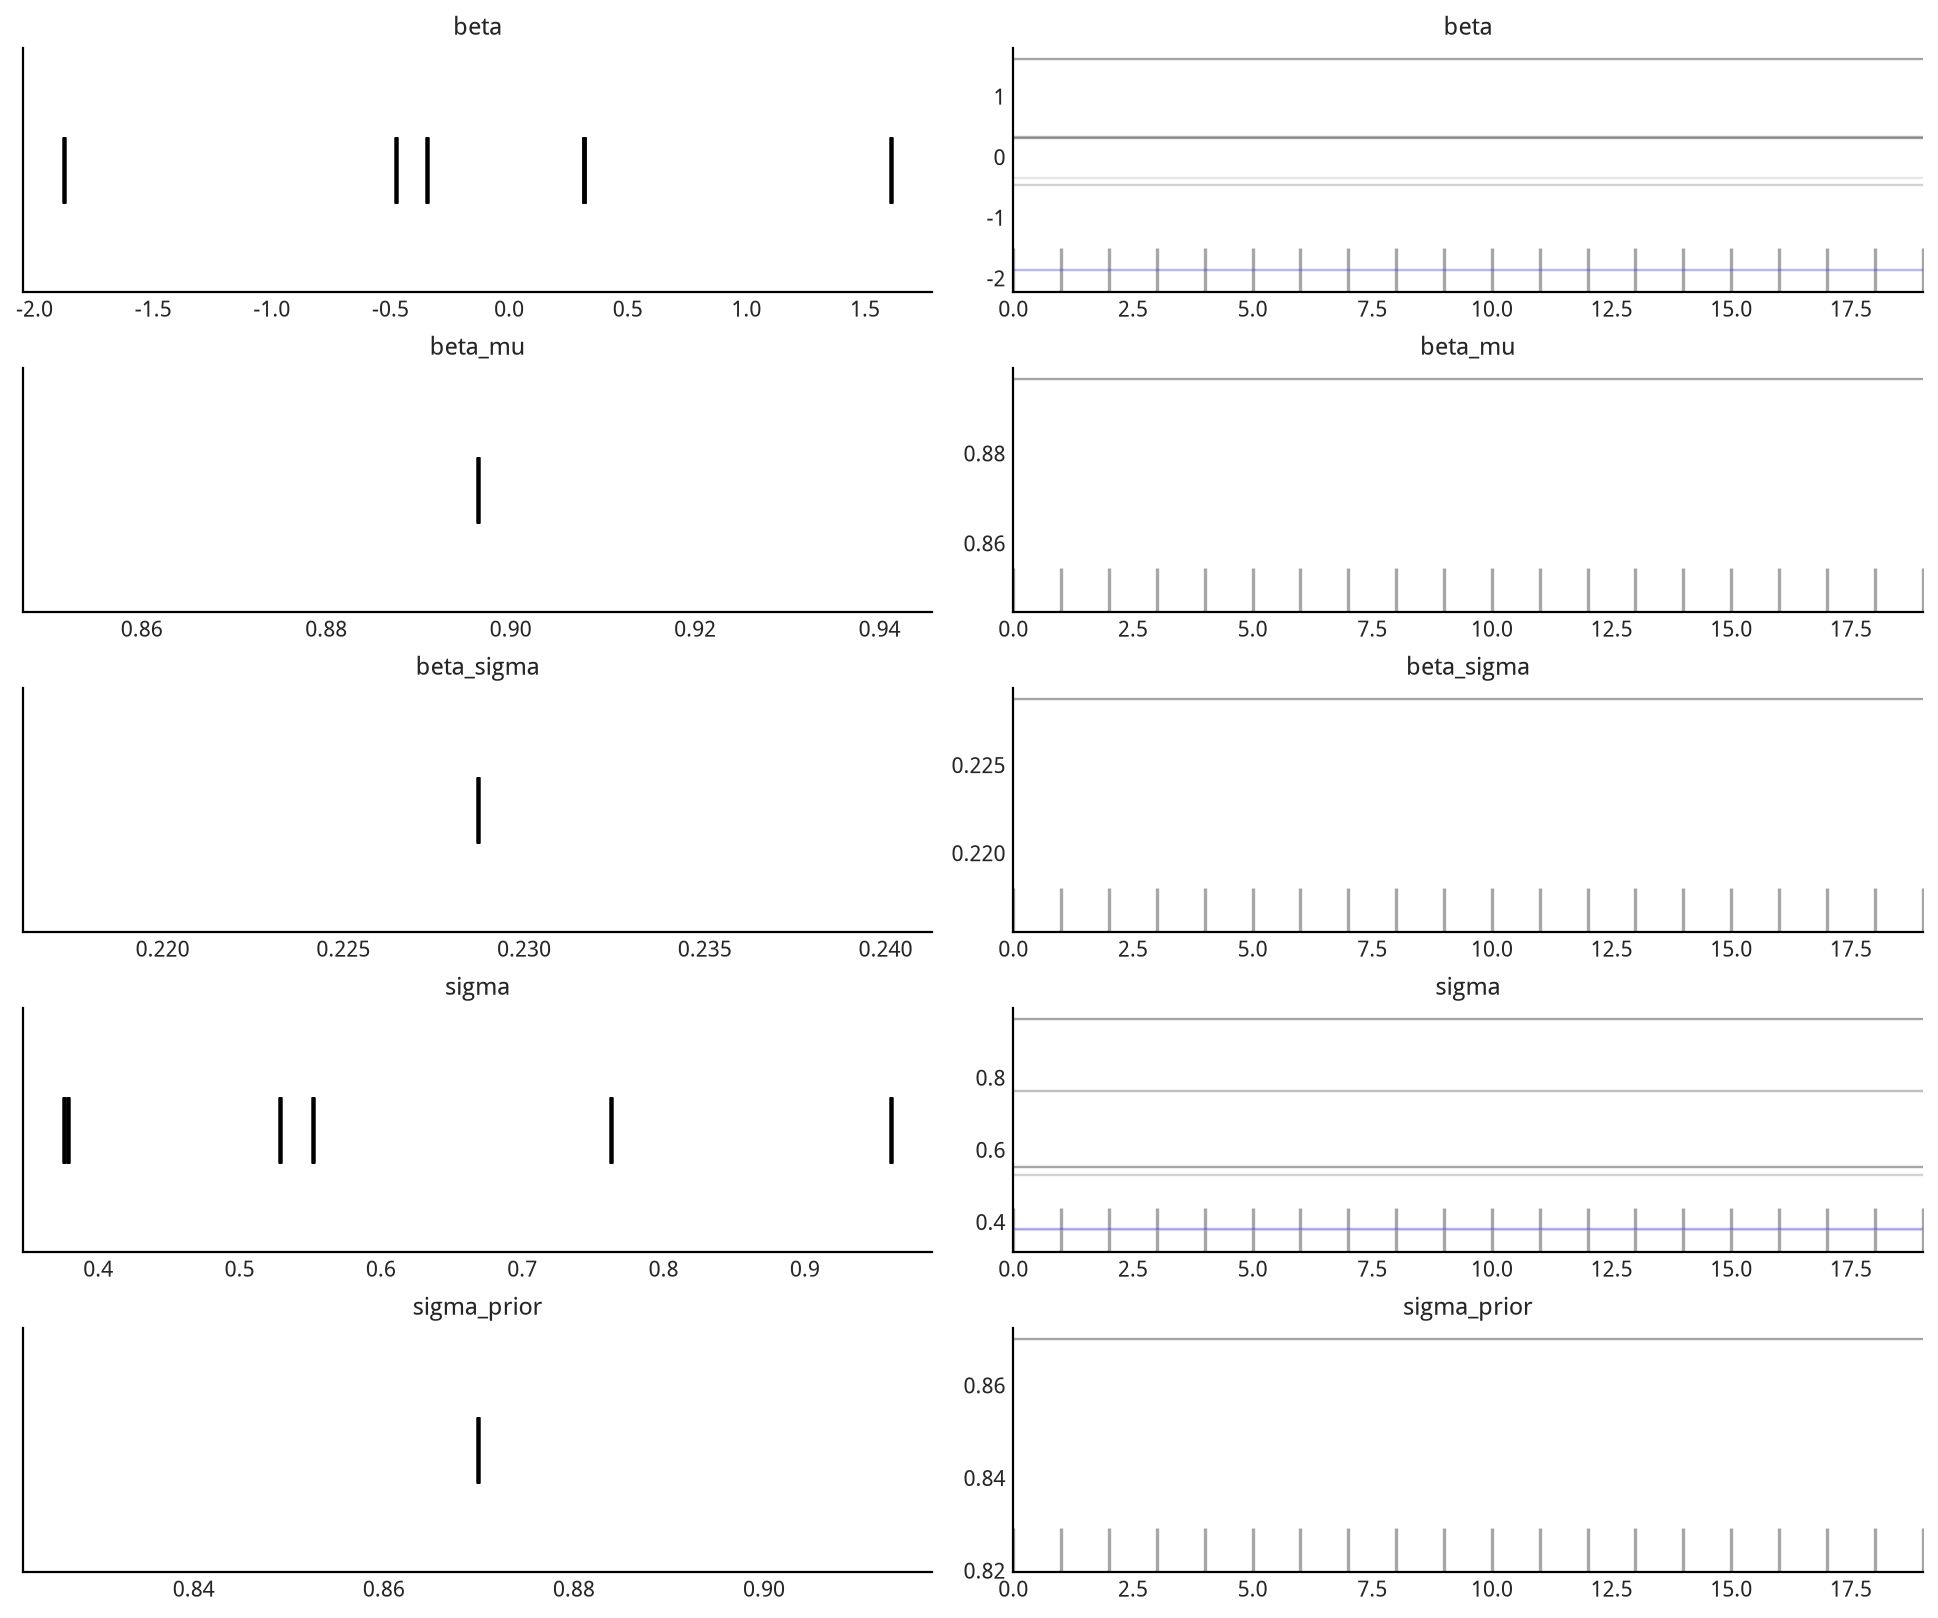

In [35]:
def tfp_samples_to_idata(samples, sampler_stats, *, n_locations, noncentered=False):
    posterior = {name: np.swapaxes(np.asarray(value), 0, 1) for name, value in samples._asdict().items()}
    wanted_stats = ("target_log_prob", "diverging", "accept_ratio", "n_steps")
    sample_stats = {
        name: np.swapaxes(np.asarray(sampler_stats[name]), 0, 1)
        for name in wanted_stats
        if name in sampler_stats
    }
    dims = {"sigma": ["location"]}
    if noncentered:
        dims["beta_offset"] = ["location"]
    else:
        dims["beta"] = ["location"]
    return az.from_dict(
        posterior=posterior,
        sample_stats=sample_stats,
        coords={"location": np.arange(n_locations)},
        dims=dims,
    )

idata_centered_model = tfp_samples_to_idata(
    mcmc_samples_centered, sampler_stats_centered, n_locations=n_locations
)
az.plot_trace(idata_centered_model, compact=True)
centered_summary = az.summary(idata_centered_model)
centered_summary

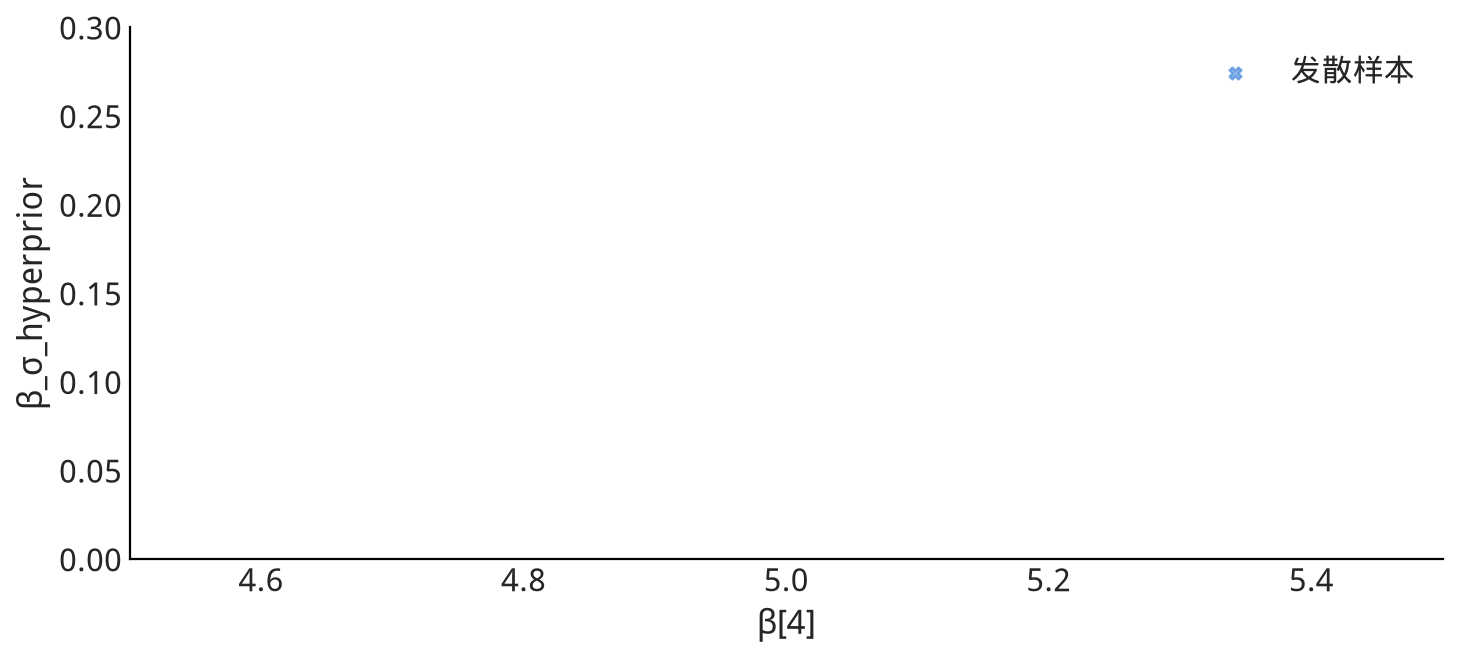

In [36]:
centered_slope = np.asarray(mcmc_samples_centered.beta)[..., 4].reshape(-1)
centered_beta_sigma = np.asarray(mcmc_samples_centered.beta_sigma).reshape(-1)
centered_divergent = np.asarray(sampler_stats_centered["diverging"]).reshape(-1).astype(bool)
axis = az.plot_pair({"β[4]": centered_slope, "β_σ_hyperprior": centered_beta_sigma}, figsize=(9, 4))
axis.scatter(
    centered_slope[centered_divergent], centered_beta_sigma[centered_divergent],
    marker="X", s=30, color=SERIES_COLORS[0], alpha=0.55, label="发散样本",
)
axis.set_ylim(0, 0.3)
axis.set_xlim(4.5, 5.5)
axis.legend(frameon=False)
plt.gcf().savefig(FIGURE_DIR / "neals_funnel_salad_centered.png", bbox_inches="tight")

为缓解问题,可以把中心化参数化改成代码块
[model_hierarchical_salad_sales_non_centered](model_hierarchical_salad_sales_non_centered) 与式
{eq}`eq:noncentered_hierarchical_regression` 所示的非中心化形式。关键差异是:不再直接估计各组斜率
$\beta_m$,而是估计所有组共享的共同项和每组偏离共同项的偏移量。这样会改变后验几何,让采样器更
容易探索 $\beta_{\sigma h}$ 的全部可能值。图 {numref}`fig:Neals_Funnel_Salad_NonCentered` 中,
表示 $\beta_{\sigma h}$ 的 y 轴接近 0 的区域已有许多样本。

```{math}
:label: eq:noncentered_hierarchical_regression
\begin{split}
\beta_{\mu h} \sim& \mathcal{N} \\
\beta_{\sigma h} \sim& \mathcal{HN} \\
\beta_{\text{m\_offset}} \sim& \mathcal{N}(0,1) \\
\beta_m =& \overbrace{\beta_{\mu h} + \beta_{\text{m\_offset}}\beta_{\sigma h}}^{\text{非中心化}} \\
\sigma_{h} \sim& \mathcal{HN} \\
\sigma_{m} \sim& \mathcal{HN}(\sigma_{h}) \\
Y \sim& \mathcal{N}(\beta_{m} X_m,\sigma_{m})
\end{split}
```

> **中文版补充**:以下发散数是原书一次历史运行记录,不是本章当前确定性配置重新生成的结果:

```none
每条链在调参后分别有 [1 0 2 0] 次发散。
```

```{figure} figures/neals_funnel_salad_noncentered.png
:name: fig:Neals_Funnel_Salad_NonCentered
:width: 7.00in
代码块 [model_hierarchical_salad_sales_non_centered](model_hierarchical_salad_sales_non_centered) 中非中心化
模型的超先验与门店 4 斜率 $\beta[4]$。采样器现在能访问接近 0 的参数区域,发散更少,也不再集中于
单一区域。
```

更好的采样会实质性改变图 {numref}`fig:Salad_Sales_Hierarchical_Comparison` 中的估计分布。再次
提醒:采样器只是估计后验分布;它们在很多情况下表现很好,但没有保证。遇到警告时必须重视诊断并
深入调查。

中心化还是非中心化没有放之四海而皆准的答案 {cite:p}`Papaspiliopoulos2007`。结果取决于每组似然
的信息量(通常某组数据越多,似然越有信息)、组层先验的信息量以及参数化之间的复杂交互。一般经验
是:观测较少时更偏好非中心化。实践中应尝试中心化和非中心化的不同组合及不同先验;某些模型甚至
需要两者并存。如果怀疑参数化导致采样问题,建议阅读 Michael Betancourt 关于层级建模的案例研究
{cite:p}`betancourt_2020_hierarchical`。

```{figure} figures/salad_sales_hierarchical_comparison.png
:name: fig:Salad_Sales_Hierarchical_Comparison
:width: 7.00in
中心化和非中心化参数化中 $\beta_{\sigma h}$ 的核密度估计(KDE)。分布变化来自采样器对可能参数空间
探索充分程度的改变。
```

In [37]:
def non_centered_beta_prior_fn(hyper_mu, hyper_sigma, n_locations, dtype):
    beta_offset = yield Root(
        tfd.Sample(tfd.Normal(tf.cast(0.0, dtype), tf.cast(1.0, dtype)), n_locations, name="beta_offset")
    )
    return beta_offset * hyper_sigma[..., None] + hyper_mu[..., None]

non_centered_model, observed_tfp, n_locations = gen_hierarchical_salad_sales(
    hierarchical_salad_df, non_centered_beta_prior_fn
)
mcmc_samples_noncentered, sampler_stats_noncentered = run_tfp_nuts(
    non_centered_model,
    draws=PROFILE["tfp_draws"],
    adaptation_steps=PROFILE["tfp_adapt"],
    chains=PROFILE["tfp_chains"],
    seed=SEED + 51,
    sales=observed_tfp,
)
noncentered_divergences_per_chain = np.asarray(sampler_stats_noncentered["diverging"]).sum(axis=0)
print(f"每条链在调参后分别有 {noncentered_divergences_per_chain} 次发散。")

每条链在调参后分别有 [20] 次发散。


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a

arviz - WARNING - Shape validation failed: input_shape: (1, 20), minimum_shape: (chains=2, draws=4)


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_mu,-1.645,0.0,-1.645,-1.645,0.0,0.0,20.0,20.0,NaN
beta_offset[0],-0.380,0.0,-0.380,-0.380,0.0,NaN,20.0,20.0,NaN
beta_offset[1],0.507,0.0,0.507,0.507,0.0,NaN,20.0,20.0,NaN
beta_offset[2],-0.396,0.0,-0.396,-0.396,0.0,NaN,20.0,20.0,NaN
beta_offset[3],1.822,0.0,1.822,1.822,0.0,NaN,20.0,20.0,NaN
beta_offset[4],-0.714,0.0,-0.714,-0.714,0.0,NaN,20.0,20.0,NaN
beta_offset[5],-0.010,0.0,-0.010,-0.010,0.0,NaN,20.0,20.0,NaN
beta_sigma,1.693,0.0,1.693,1.693,0.0,NaN,20.0,20.0,NaN
sigma[0],0.813,0.0,0.813,0.813,0.0,NaN,20.0,20.0,NaN
sigma[1],1.063,0.0,1.063,1.063,0.0,0.0,20.0,20.0,NaN


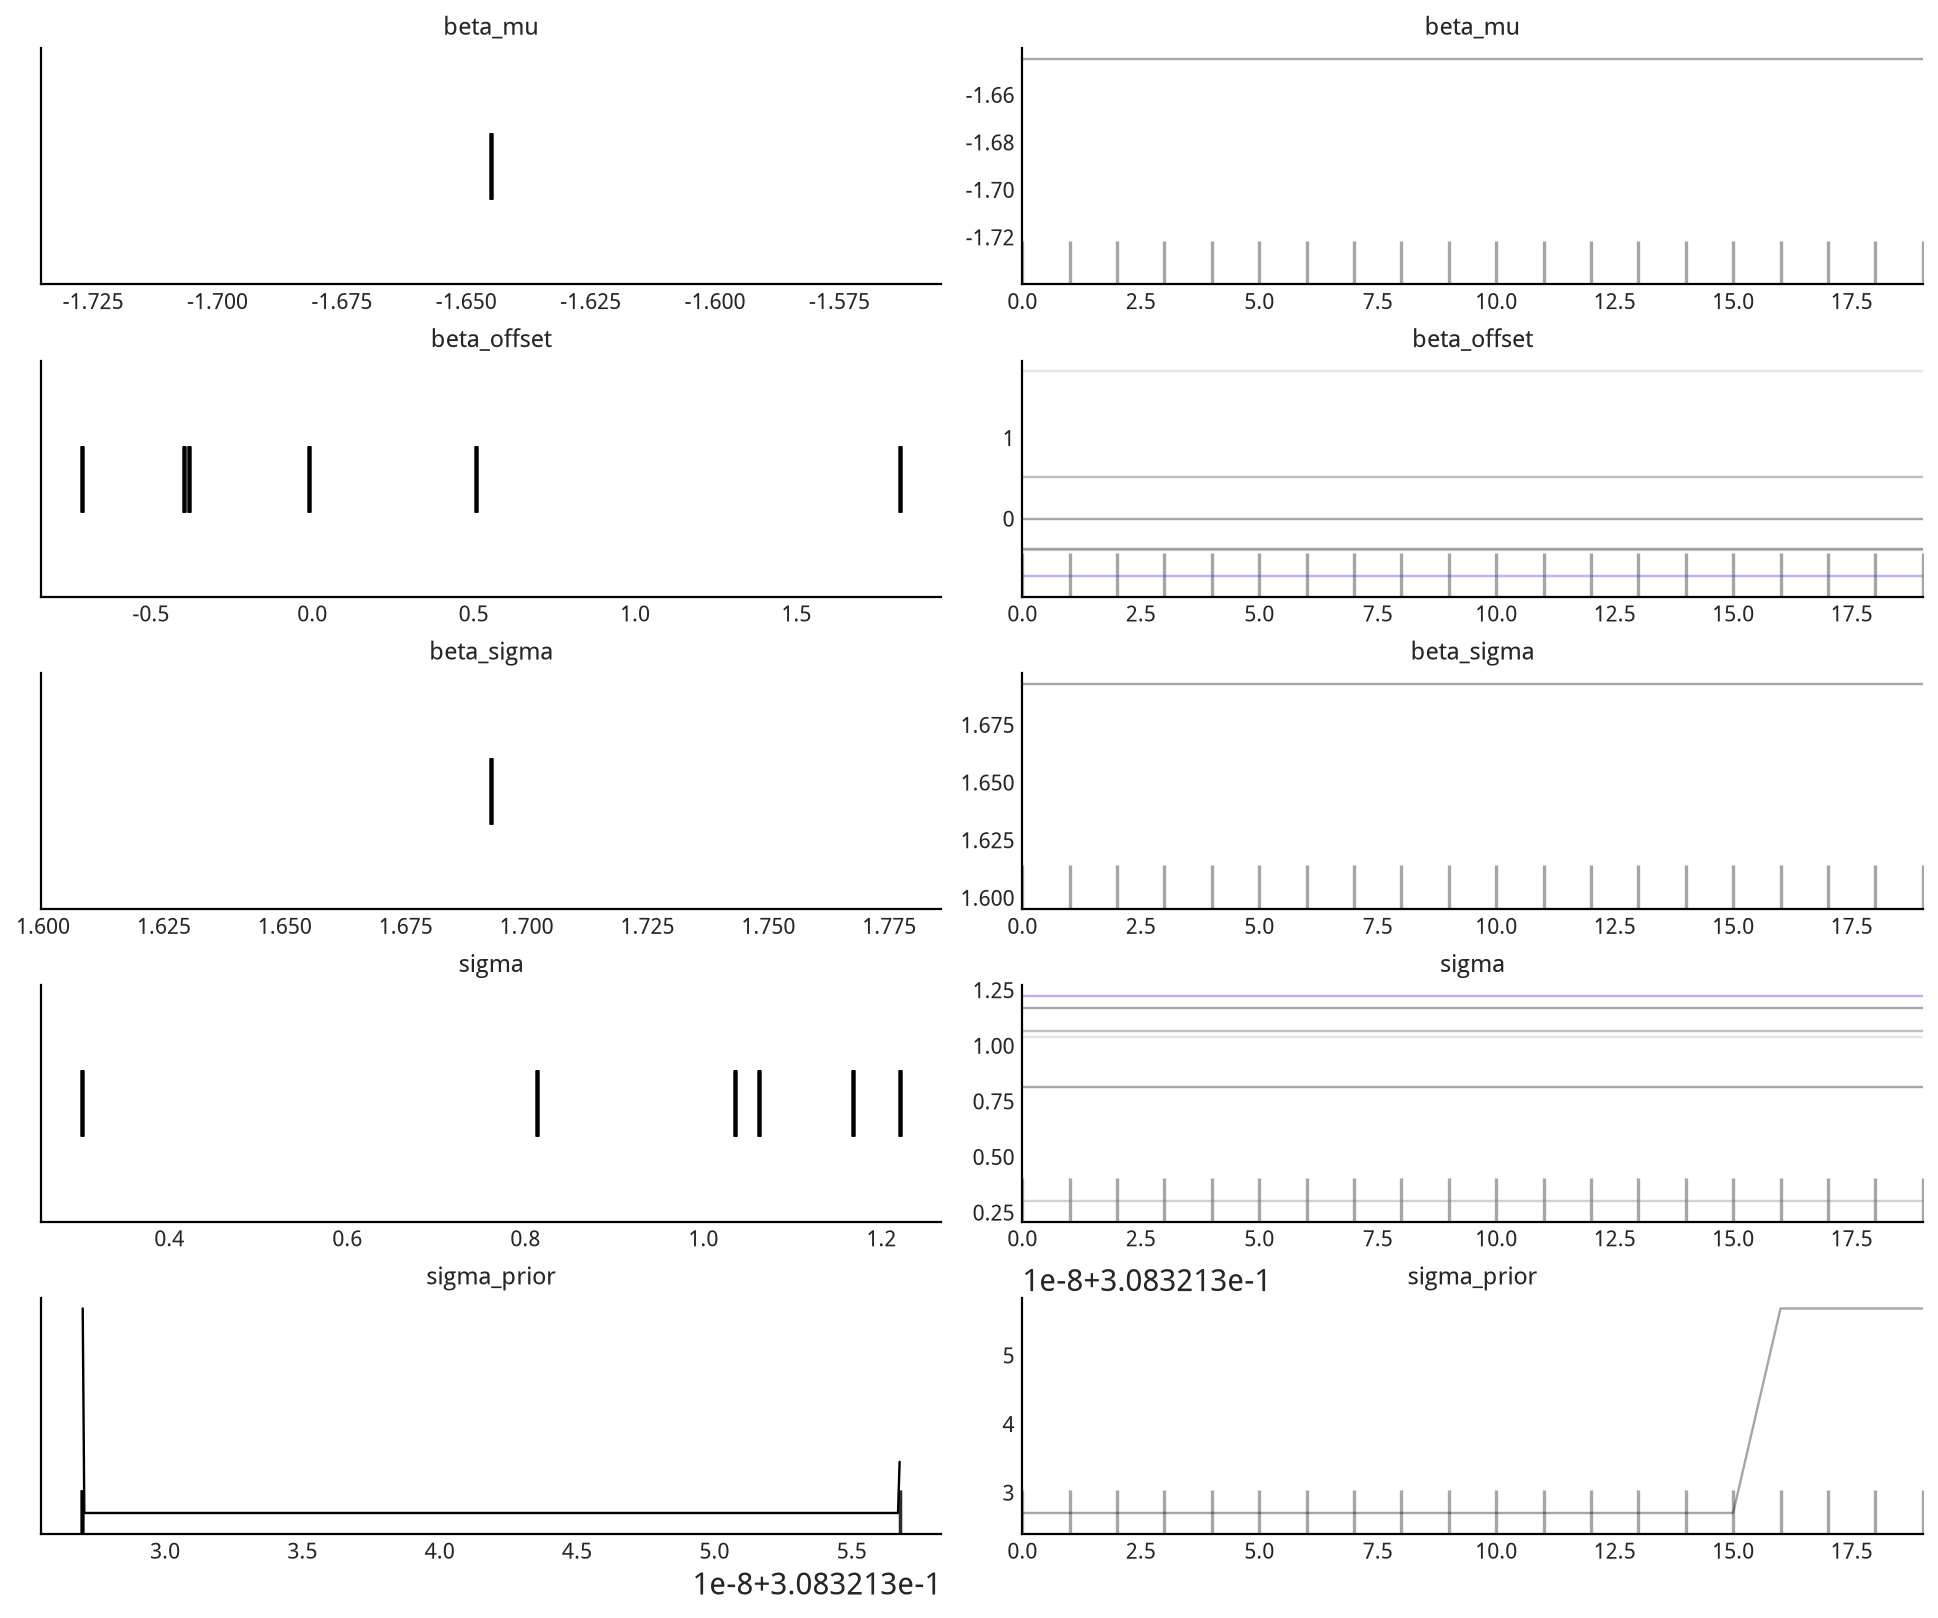

In [38]:
idata_non_centered_model = tfp_samples_to_idata(
    mcmc_samples_noncentered,
    sampler_stats_noncentered,
    n_locations=n_locations,
    noncentered=True,
)
az.plot_trace(idata_non_centered_model, compact=True)
noncentered_summary = az.summary(idata_non_centered_model)
noncentered_summary

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


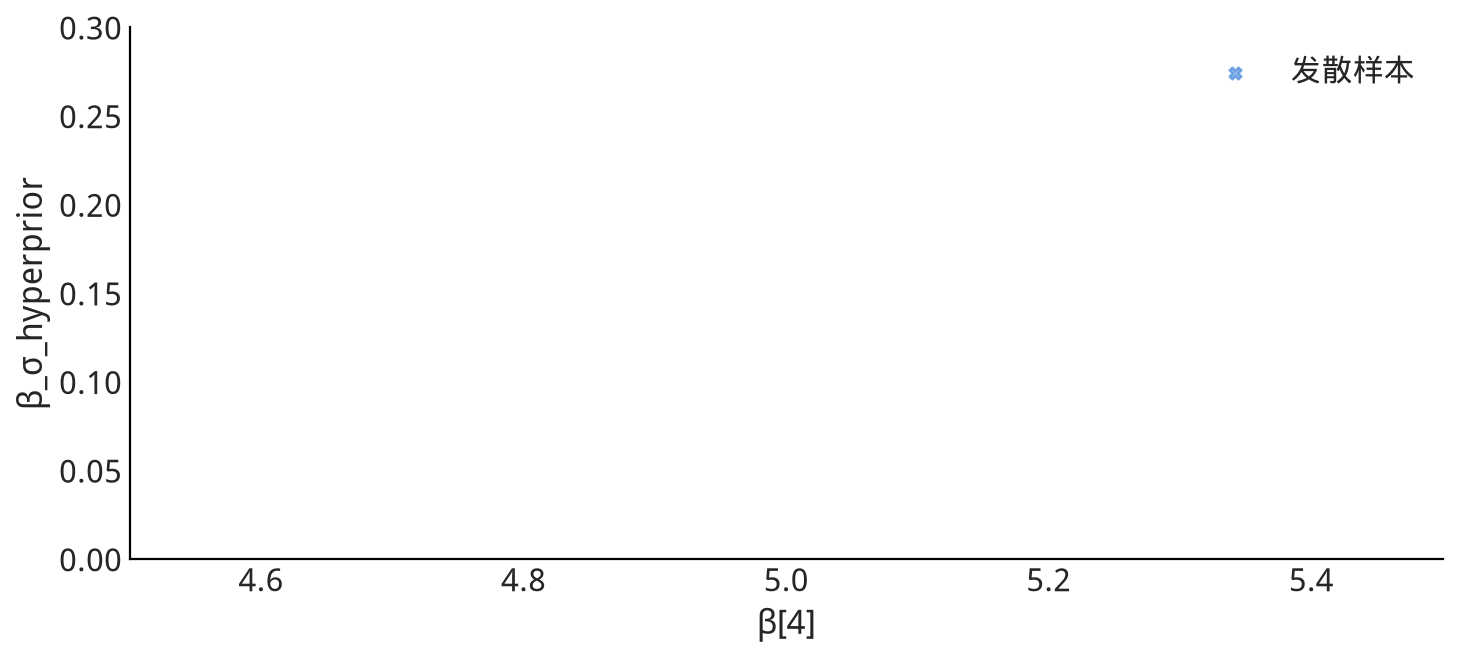

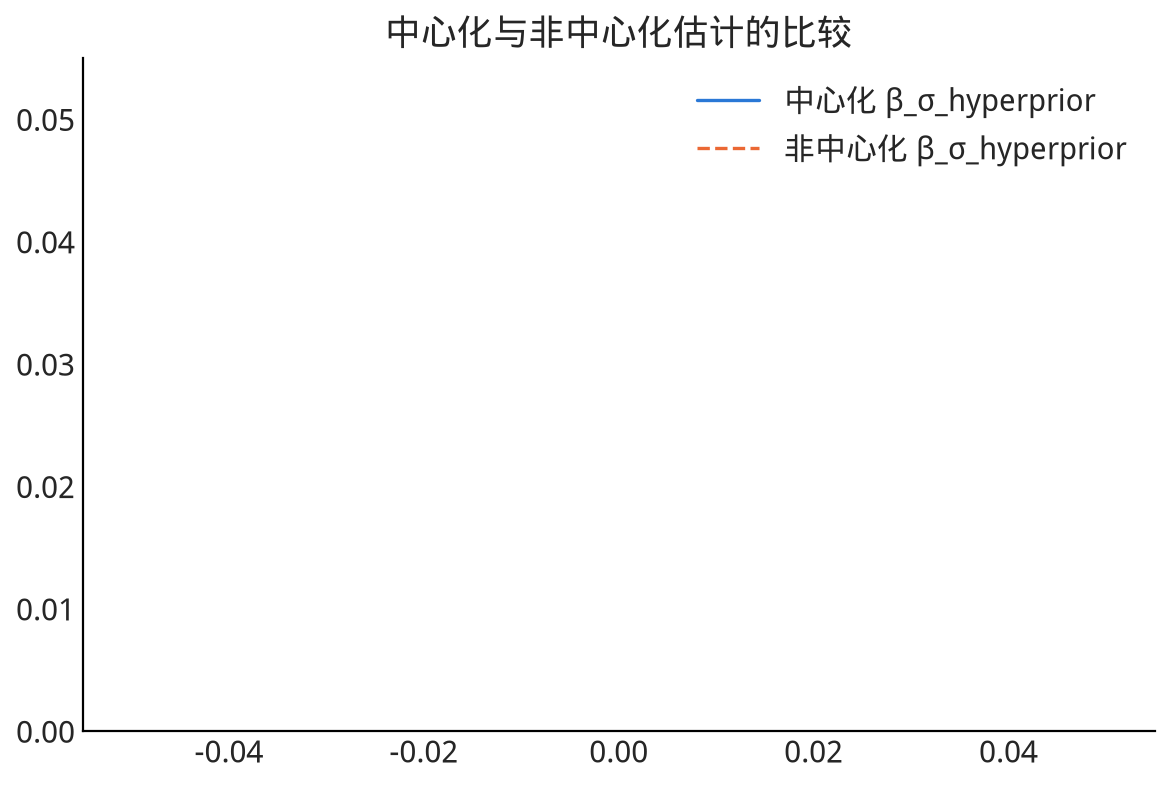

In [39]:
noncentered_beta = (
    np.asarray(mcmc_samples_noncentered.beta_mu)[..., None]
    + np.asarray(mcmc_samples_noncentered.beta_offset)
    * np.asarray(mcmc_samples_noncentered.beta_sigma)[..., None]
)
noncentered_slope = noncentered_beta[..., 4].reshape(-1)
noncentered_beta_sigma = np.asarray(mcmc_samples_noncentered.beta_sigma).reshape(-1)
noncentered_divergent = np.asarray(sampler_stats_noncentered["diverging"]).reshape(-1).astype(bool)
axis = az.plot_pair(
    {"β[4]": noncentered_slope, "β_σ_hyperprior": noncentered_beta_sigma}, figsize=(9, 4)
)
axis.scatter(
    noncentered_slope[noncentered_divergent], noncentered_beta_sigma[noncentered_divergent],
    marker="X", s=30, color=SERIES_COLORS[0], alpha=0.55, label="发散样本",
)
axis.set_ylim(0, 0.3)
axis.set_xlim(4.5, 5.5)
axis.legend(frameon=False)
plt.gcf().savefig(FIGURE_DIR / "neals_funnel_salad_noncentered.png", bbox_inches="tight")

figure, axis = plt.subplots()
az.plot_kde(
    np.asarray(mcmc_samples_centered.beta_sigma),
    label="中心化 β_σ_hyperprior",
    plot_kwargs={"color": SERIES_COLORS[0], "linestyle": "-"}, ax=axis,
)
az.plot_kde(
    np.asarray(mcmc_samples_noncentered.beta_sigma),
    label="非中心化 β_σ_hyperprior",
    plot_kwargs={"color": SERIES_COLORS[1], "linestyle": "--"}, ax=axis,
)
axis.set_title("中心化与非中心化估计的比较")
axis.legend(frameon=False)
figure.savefig(FIGURE_DIR / "salad_sales_hierarchical_comparison.png", bbox_inches="tight")

(predictions-at-multiple-levels)=

### 在多个层级上预测

层级模型一个不那么显眼的特征是,它能在多个层级上进行估计。这个说法似乎显而易见,却非常有用:
一个模型能回答的问题远多于单层模型。在[第 3 章](chap2),我们可以建一个模型估计单一物种的体重,
也可以另建一个模型估计不区分物种的任意企鹅体重。使用层级模型,则可以用同一个模型同时估计所有
企鹅以及每个企鹅物种的体重。

对沙拉销售模型,我们同样既能估计单家门店,也能估计整个门店总体。为此,复用代码块
[model_hierarchical_salad_sales_non_centered](model_hierarchical_salad_sales_non_centered) 中的
`non_centered_model`,再按代码块
[model_hierarchical_salad_sales_predictions](model_hierarchical_salad_sales_predictions) 构造样本外预测。
它利用拟合后的参数估计,**同时**预测 50 位顾客时两个既有门店的销售分布,以及由
$\beta_{\mu h}$ 决定的公司总体条件期望分布。总体曲线不是“随机抽一家新店”;随机新门店必须同时从
斜率超先验和 $\sigma_m\sim\operatorname{HalfNormal}(\sigma_h)$ 抽取门店参数,这一过程在下一代码块中
单独演示。估计绘于图
{numref}`fig:Salad_Sales_Hierarchical_Predictions`。

```{figure} figures/salad_sales_hierarchical_predictions.png
:name: fig:Salad_Sales_Hierarchical_Predictions
:width: 7.00in
50 位顾客时,两个既有门店的后验预测分布与公司总体条件期望分布。参数后验来自
`model_hierarchical_salad_sales_non_centered`。
```

使用带超先验的层级模型预测时,另一个特点是能为从未见过的组做预测。设想公司要在新地点开一家
沙拉店:先从超先验抽取新门店的 $\beta_{i+1}$ 和 $\sigma_{i+1}$,再从后验预测分布抽取销售额,便能在
没有该门店历史数据时给出预测。代码块
[model_hierarchical_salad_sales_predictions_new_location](model_hierarchical_salad_sales_predictions_new_location)
对此进行了演示。

> **中文版现代化说明**:旧 notebook 通过未命名的 `var0` 把一个联合分布整体钉住(pin),这种写法依赖
> 联合分布内部组件次序且不易审计。这里对具名后验张量直接组合公开的 `tfd.Normal` 和
> `tfd.HalfNormal`,得到完全相同的条件预测关系,并为每次预测设置独立确定性种子。

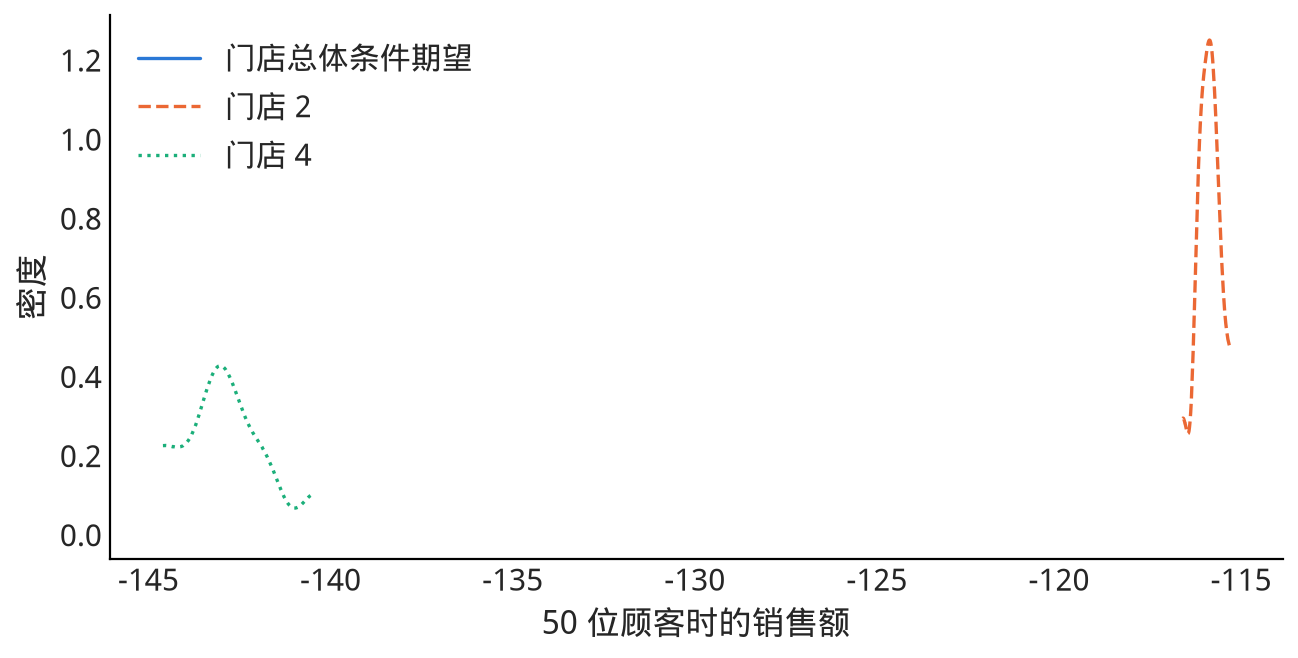

In [40]:
out_of_sample_customers = tf.cast(50.0, tf.float32)
posterior_beta_noncentered = (
    mcmc_samples_noncentered.beta_mu[..., None]
    + mcmc_samples_noncentered.beta_offset * mcmc_samples_noncentered.beta_sigma[..., None]
)

# “整个公司”指总体条件期望,因此使用 beta_mu;随机新门店的完整预测见下一单元。
population_level_prediction = mcmc_samples_noncentered.beta_mu * out_of_sample_customers

existing_location_predictions = {}
for seed_offset, location in enumerate((2, 4), start=60):
    existing_location_predictions[location] = tfd.Normal(
        tf.gather(posterior_beta_noncentered, location, axis=-1) * out_of_sample_customers,
        tf.gather(mcmc_samples_noncentered.sigma, location, axis=-1),
    ).sample(seed=SEED + seed_offset)

figure, axis = plt.subplots(figsize=(8, 4))
az.plot_kde(np.asarray(population_level_prediction), label="门店总体条件期望",
            plot_kwargs={"color": SERIES_COLORS[0], "linestyle": "-"}, ax=axis)
for location, color, linestyle in zip((2, 4), SERIES_COLORS[1:3], ("--", ":"), strict=True):
    az.plot_kde(np.asarray(existing_location_predictions[location]), label=f"门店 {location}",
                plot_kwargs={"color": color, "linestyle": linestyle}, ax=axis)
axis.set_xlabel("50 位顾客时的销售额")
axis.set_ylabel("密度")
axis.legend(frameon=False)
figure.savefig(FIGURE_DIR / "salad_sales_hierarchical_predictions.png", bbox_inches="tight")

(array([-100.54211, -102.70381, -104.60781], dtype=float32),
 <xarray.Dataset> Size: 1kB
 Dimensions:             (customer: 40, hdi: 2)
 Coordinates:
   * customer            (customer) int64 320B 50 51 52 53 54 ... 85 86 87 88 89
   * hdi                 (hdi) <U6 48B 'lower' 'higher'
 Data variables:
     new_location_sales  (customer, hdi) float64 640B -313.7 63.31 ... 112.6)

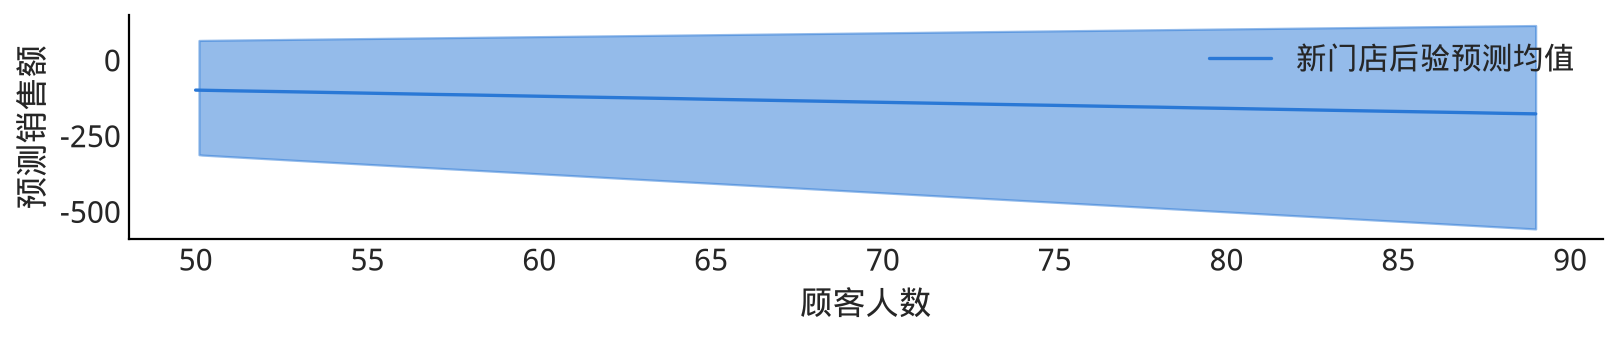

In [41]:
out_of_sample_customers_new_location = tf.cast(np.arange(50, 90), tf.float32)
beta_new_location = tfd.Normal(
    mcmc_samples_noncentered.beta_mu,
    mcmc_samples_noncentered.beta_sigma,
).sample(seed=SEED + 70)
sigma_new_location = tfd.HalfNormal(
    mcmc_samples_noncentered.sigma_prior
).sample(seed=SEED + 71)
new_location_prediction = tfd.Normal(
    beta_new_location[..., None] * out_of_sample_customers_new_location,
    sigma_new_location[..., None],
).sample(seed=SEED + 72)

new_location_prediction_array = np.asarray(new_location_prediction)
new_location_prediction_da = xr.DataArray(
    np.swapaxes(new_location_prediction_array, 0, 1),
    dims=("chain", "draw", "customer"),
    coords={"customer": np.arange(50, 90)},
    name="new_location_sales",
)
new_location_prediction_mean = new_location_prediction_da.mean(("chain", "draw")).values
new_location_prediction_hdi = az.hdi(new_location_prediction_da, hdi_prob=0.95)
figure, axis = plt.subplots(figsize=(10, 2))
az.plot_hdi(
    np.asarray(out_of_sample_customers_new_location),
    new_location_prediction_da,
    hdi_prob=0.95,
    color=SERIES_COLORS[0],
    ax=axis,
)
axis.plot(
    np.asarray(out_of_sample_customers_new_location),
    new_location_prediction_mean,
    color=SERIES_COLORS[0],
    linestyle="-",
    label="新门店后验预测均值",
)
axis.set_xlabel("顾客人数")
axis.set_ylabel("预测销售额")
axis.legend(frameon=False)
new_location_prediction_mean[:3], new_location_prediction_hdi

除数学上的好处外,层级建模还有计算上的优势:只需构造和拟合一个模型。如果模型会随时间被多次
复用,这既能加快建模过程,也能简化后续维护。

:::{admonition} 关于 LOO 的有效性
:class: note
层级模型允许我们为从未见过的组做后验预测,但这种预测有多可靠?能否用交叉验证评估模型表现?
如同统计学中的许多问题,答案是:**视情况而定**。交叉验证(以及 LOO、WAIC 等方法)是否有效,既取决
于预测任务,也取决于数据生成机制。

如果要用 LOO 评估模型预测新**观测**的能力,普通 LOO 是合适的。如果要评估预测整个**组**的能力,
则应执行有明确定义的留一组交叉验证(leave-one-group-out cross-validation)。在后一种情形,普通
LOO 很可能表现不佳:每次移除的是很多观测,而 LOO 近似核心的重采样步骤依赖“包含”和“不包含”
该点、组或其他单位时的分布彼此接近。
:::

(priors-for-multilevel-models)=

### 多层模型的先验

先验选择对多层模型尤为重要,因为先验会与似然的信息量发生交互,正如 {ref}`model_geometry` 节所示。
不仅先验分布的形状重要,我们还需要选择如何参数化它们。这一点并不把我们限制在高斯先验,因为它
适用于位置-尺度分布族(location-scale family)[^6]中的所有分布。

在多层模型中,先验分布不仅刻画组内变异,也刻画组间变异。从某种意义上说,超先验定义了“变异的
变异”,这会让先验信息的表达和推理变得困难。此外,部分合并的效果由超先验的信息量、组数以及
每组观测数共同决定。因此,在相似但组数更少的数据集上用同一模型推断时,同一个超先验未必仍然
合适。

除了经验知识(例如论文中发表的一般建议)或通用建议[^7],还可以做敏感性研究来帮助选择先验。例如,
Lemoine {cite:p}`lemoine_2019` 研究了具有如下结构的生态数据模型:

```{math}
:label: eq:ecology_regression
\begin{split}
    \alpha_i \sim& \mathcal{N}(\mu_{\alpha},\sigma^2_{\alpha}) \\
    \mu_{i} =& \alpha_i + \beta Day_i \\
    Y_i \sim& \mathcal{N}(\mu_{i},\sigma^2)
\end{split}
```

其中截距不合并。Cauchy 先验能在数据点较少时提供正则化,而在模型拟合更多数据后又不会遮蔽后验。
这一结论来自同时改变先验参数化和数据量的先验敏感性分析。在自己的多层模型中,务必留意先验选择
影响推断的多种方式,并使用领域知识或先验预测分布等工具做出有依据的选择。

(exercises4)=

## 练习

> **中文版补充**:本章原文未为以下练习提供提示。

**4E1.** 日常生活中,有哪些协变量与响应之间呈非线性关系的例子?

**4E2.** 假设你正在研究一个协变量与一个结果之间的关系,并且数据可以分成 2 组。你的基础模型
结构是带斜率和截距的回归:

```{math}
\begin{split}
    \mu =& \beta_0 + \beta_1 X_1 \\
    Y \sim& \mathcal{N}(\mu, \sigma)
\end{split}
```

再假设你现在需要按下列每一种方式扩展模型结构。对每一项,写出规定完整模型的数学方程。

1. 合并模型。
2. 不合并模型。
3. $\beta_0$ 合并的混合效应模型。
4. $\beta_0$ 为层级参数的模型。
5. 所有参数均为层级参数的模型。
6. 所有参数均为层级参数、且 $\beta$ 参数采用非中心化参数化的模型。

**4E3.** 用统计符号写出 babies 数据集的稳健线性回归模型。

**4E4.** 考虑一位健美运动员的处境:为了练出能在比赛中获得高分的体格,他需要举重、做有氧运动
并合理进食。如果建立一个以举重、有氧运动和进食为协变量的模型,你认为这些协变量彼此独立,还是
会发生交互?请用你的领域知识论证答案。

**4E5.** Student-t 分布有一个有趣性质:在 $\nu=1$ 和 $\nu=\infty$ 时,Student-t 分布分别与另外
两个分布之一完全相同,即 Cauchy 分布和正态分布。画出这两个 $\nu$ 参数值下的 Student-t 分布,
并把每种参数化与 Cauchy 或正态分布正确配对。

**4E6.** 假设我们要预测个人身高。给定身高数据以及下列某一个协变量,请说明不合并、合并、部分
合并和交互模型中哪一种回归类型适合,并解释原因。

1. 一组随机噪声向量。
2. 性别。
3. 家族关系。
4. 体重。

**4E7.** 使用 LOO 比较 `model_baby_linear` 和 `model_baby_sqrt` 的结果(对应的
`InferenceData` 分别为 `idata_linear` 和 `idata_sqrt`)。根据 LOO 说明为何变换协变量是合理的建模选择。

**4E8.** 回到企鹅数据集。加入交互项,估计企鹅物种与鳍肢长度共同作用下的企鹅体重。预测有何
不同?这个模型更好吗?请用文字和 LOO 论证你的判断。

**4M9.** Anscombe 四重奏(Anscombe's quartet)是一组著名数据,用于突显仅凭数值摘要评估回归时的
困难。数据集可在本书 GitHub 仓库获取。分别使用稳健回归和非稳健回归拟合第三组数据,并画出结果。

> **中文版数据说明**:为使练习在不查看解答的情况下可复现,本章随附公开的
> `data/anscombe.csv`。文件列为 `dataset,x,y`,第三组满足 `dataset == "III"`;它逐字节保留
> seaborn-data 公开镜像中的 Anscombe 数据,来源与 SHA-256 记录在 `manifest.toml`。

**4M10.** 重新考察代码块 [nocovariate_mass](nocovariate_mass) 定义的企鹅体重模型。为 $\mu$
加入层级项。超先验均值的估计是多少?所有企鹅的平均体重是多少?比较经验均值与超先验均值估计。
这两个估计值有道理吗,尤其是在相互比较时?为什么?

**4M11.** 混凝土的抗压强度取决于生产时使用的水和水泥量。本书 GitHub 仓库提供了一份数据集,
其中包含混凝土抗压强度以及每立方米混凝土所含的水和水泥量(千克)。建立一个含水和水泥交互项的
线性模型。这个交互模型的输入与前文的吸烟者模型相比有何不同?在若干固定水量下,画出混凝土抗压
强度随水泥量变化的函数。

**4M12.** 再次运行比萨回归,但这次使用异方差回归。结果如何?

**4H13.** 氡是一种可能导致肺癌的放射性气体,因此住宅中并不希望出现氡。不幸的是,地下室可能
提高住宅内的氡水平,因为氡可能更容易从地面进入室内。本书 GitHub 仓库提供了明尼苏达州住宅的
氡水平数据,以及住宅所在县和是否有地下室的信息。

1. 运行不合并回归,估计地下室对氡水平的影响。
2. 建立按县分组的层级模型。说明为何该模型对这份数据有用。
3. 建立非中心化回归。使用图和诊断说明是否需要非中心化参数化。

**4H14.** 对下列每类模型,自行选择参数生成一份合成数据集。随后分别对每份数据拟合两个模型:
一个与数据生成过程匹配,另一个不匹配。观察两者的诊断摘要和图有何不同。

例如,可以生成遵循线性模式的数据 $x=[1,2,3,4],y=[2,4,6,8]$,然后拟合一个 $y=bx$ 形式的
模型和另一个 $y=bx**2$ 形式的模型。

1. 线性模型。
2. 含变换后协变量的线性模型。
3. 含交互效应的线性模型。
4. 4 组模型,截距合并,斜率和噪声不合并。
5. 层级模型。

**4H15.** 对层级沙拉回归模型,评估斜率参数 $\beta_{\mu h}$ 的后验几何。然后创建一个让
$\beta_{\mu h}$ 非中心化的模型版本,再画出几何。两者有何差异?同时评估发散和输出。非中心化在
这里有帮助吗?

**4H16.** 你的一位同事现在住在一颗未知行星上,她做了一个实验来检验基本物理定律:从悬崖上
扔下一只球,并记录其随后 20 秒的位置。数据可在本书 GitHub 仓库的
`gravity_measurements.csv` 文件中获取。根据 Newton 物理定律,若加速度为 $g$、时间为 $t$,则

```{math}
:label: eq:physics_experiment
\begin{split}
\text{速度} &= gt \\
\text{位置} &= \frac{1}{2}gt^2
\end{split}
```

你的同事请你估计:

1. 该行星的重力常数。
2. 她的测量设备噪声的特征。
3. 测量期间每个时间点球的速度。
4. 从第 20 秒到第 30 秒球的位置估计。

> **中文版数据说明**:原仓库公开部分未包含题述文件。为使练习可执行且不泄露待估参数,本章随附
> 独立生成的非解答输入 `data/gravity_measurements.csv`,列为 `time,position`。可用
> `pd.read_csv(DATA_DIR / "gravity_measurements.csv")` 读取;文件模式、行数、来源状态与 SHA-256
> 记录在 `manifest.toml`。

[^1]: 观测值与感兴趣量估计值之间的差称为残差(residual)。

[^2]: 请记住,这只是一个玩具数据集,因此核心结论应当关于交互建模,而不是关于小费。

[^3]: 尽管均值仅在 $\nu>1$ 时有定义,并且只有当 $\nu\to\infty$ 时,$\sigma$ 的值才等于标准差。

[^4]: Empanada 是一种薄面皮包裹咸味或甜味馅料后烘烤或油炸的食物。馅料可以包括红肉或白肉、
鱼、蔬菜或水果。Empanada 常见于南欧、拉丁美洲和菲律宾文化。

[^5]: 分别纪念阿根廷第一届政府成立和阿根廷独立日。

[^6]: [位置-尺度分布族](https://en.wikipedia.org/wiki/Location%E2%80%93scale_family)。

[^7]: [Stan 先验选择建议](https://github.com/stan-dev/stan/wiki/Prior-Choice-Recommendations)。